
## Predicting Project Approval on DonorsChoose.org
---
> The DonorsChoose.org portal receives a staggering number of classroom project proposals (hundreds of thousands!) each year. Manually reviewing each one by a large volunteer force is becoming unsustainable.

The **objective** is to streamline the screening process and ensure all proposals receive a fair and consistent review. This will help in freeing up volunteer time to focus on proposals that require more hands-on guidance.


---




***This is where you come in!***  

**Problem Statement ->** Your goal is to develop a system that predicts project approval based on the teacher's description, along with other details about the project, teacher, and school.


**Steps**
1. Data Collection, Exploration and Preprocessing
2. EDA
3. Pre-Modelling Data Preparation
4. Model Building
5. Model Evaluation
6. Summary



---



In [565]:
def memory_usage():
    import sys
    import psutil

    # Get virtual memory statistics
    mem = psutil.virtual_memory()

    # Print details
    print(f"Total RAM: {mem.total / (1024**3):.2f} GB")
    print(f"Available RAM: {mem.available / (1024**3):.2f} GB")
    print(f"Used RAM: {mem.used / (1024**3):.2f} GB")
    print(f"RAM Usage Percentage: {mem.percent}%")

## Data Collection, Exploration and Preprocessing

# From The project description

## Developer notes

The model objective is to reduce screening time for application reviewers by assessing viability of a proposal. Because the primary objective is to save time and not provide detailed or causal feedback we will tend to favor less interpretable models if they produce predictive gains.

In [566]:
import os
import gdown
import zipfile
import pandas as pd
import numpy as np
import shutil # Import shutil for moving files

# ### Download Dataset
# The dataset can be downloaded using the provided code. The data will be extracted into a specified directory.
dataset_url = "https://drive.google.com/uc?export=download&id=1KrnpfYRKVxGDnj-R2VZmNscEkR1zr2-4"
# Change dataset_path to a writable location within /tmp
dataset_path = "/tmp/dataset/donors_choose" # the dataset will be downloaded AND extracted into this folder
zip_file_name = "donors_choose_dataset.zip"
temp_zip_file_path = os.path.join("/tmp", zip_file_name) # Always download zip to /tmp

# Ensure the target extraction directory exists and is clean
if os.path.exists(dataset_path):
    print(f"Removing existing directory: {dataset_path}")
    shutil.rmtree(dataset_path) # Clean up previous attempts if they exist
os.makedirs(dataset_path) # Create the target extraction directory

# Clean up any leftover zip in /tmp before attempting download
if os.path.exists(temp_zip_file_path):
    print(f"Removing existing temporary zip file: {temp_zip_file_path}")
    os.remove(temp_zip_file_path)

print(f"Downloading '{zip_file_name}' to '{temp_zip_file_path}'...")
gdown.download(dataset_url, temp_zip_file_path, quiet=False)

print(f"'{zip_file_name}' downloaded. Extracting to '{dataset_path}'...")
with zipfile.ZipFile(temp_zip_file_path, "r") as zip_ref:
    zip_ref.extractall(dataset_path)
print("Dataset extracted successfully.")

# Optionally, remove the temporary zip file after extraction
if os.path.exists(temp_zip_file_path):
    os.remove(temp_zip_file_path)
    print(f"Removed temporary zip file: {temp_zip_file_path}")

print(f"Files are now available in: {dataset_path}")

# Note: All subsequent file loading (e.g., pd.read_csv) must use this new dataset_path.
# For example: `pd.read_csv(os.path.join(dataset_path, "train_data.csv"))`

Removing existing directory: /tmp/dataset/donors_choose


Downloading...
From (original): https://drive.google.com/uc?export=download&id=1KrnpfYRKVxGDnj-R2VZmNscEkR1zr2-4
From (redirected): https://drive.google.com/uc?export=download&id=1KrnpfYRKVxGDnj-R2VZmNscEkR1zr2-4&confirm=t&uuid=876a9815-3fb7-4c1f-8f1e-d8ef20a2dc86
To: /tmp/donors_choose_dataset.zip
100%|██████████| 111M/111M [00:06<00:00, 16.6MB/s]


'donors_choose_dataset.zip' downloaded. Extracting to '/tmp/dataset/donors_choose'...
Dataset extracted successfully.
Removed temporary zip file: /tmp/donors_choose_dataset.zip
Files are now available in: /tmp/dataset/donors_choose


In [567]:
import shutil

def check_disk_usage():
    total, used, free = shutil.disk_usage("/")
    print(f"Total: {total / (1024**3):.2f} GB")
    print(f"Used: {used / (1024**3):.2f} GB")
    print(f"Free: {free / (1024**3):.2f} GB")

check_disk_usage()


Total: 1006.85 GB
Used: 64.33 GB
Free: 891.30 GB


---


### **Accessing the dataset**
To access the dataset, open the **Files** section by clicking the folder icon on the left pane; it should display the label 'Files' when you hover over it.

> Within the Files section, you will find a folder named dataset. Inside this folder, there is another folder called *donors_choose*.

> Within the donors_choose folder, you will find two CSV files:
1. train_data.csv
2. resources.csv

These two CSV files make up the dataset.

In [568]:
# First, load the two CSV files into separate dataframes using pandas.
# Type your code below.

train_df = pd.read_csv(os.path.join(dataset_path, "train_data.csv"))
resources_df = pd.read_csv(os.path.join(dataset_path, "resources.csv"))
memory_usage()

Total RAM: 62.75 GB
Available RAM: 49.96 GB
Used RAM: 12.18 GB
RAM Usage Percentage: 20.4%


Provide a summary of each dataframe, including its size, features, target variable, and data types.

In [569]:
# View the top few rows of both the dataframe
# Type the code here
train_df.head()

,Unnamed: 0,id,teacher_id,teacher_prefix,school_state,project_submitted_datetime,project_grade_category,project_subject_categories,project_subject_subcategories,project_title,project_essay_1,project_essay_2,project_essay_3,project_essay_4,project_resource_summary,teacher_number_of_previously_posted_projects,project_is_approved
0,160221,p253737,c90749f5d961ff158d4b4d1e7dc665fc,Mrs.,IN,2016-12-05 13:43:57,Grades PreK-2,Literacy & Language,"ESL, Literacy",Educational Support for English Learners at Home,"My students are English learners that are working on English as their second or third languages. We are a melting pot of refugees, immigrants, and native-born Americans bringing the gift of language to our school. \r\n\r\n We have over 24 languages represented in our English Learner program with students at every level of mastery. We also have over 40 countries represented with the families within our school. Each student brings a wealth of knowledge and experiences to us that open our eyes to new cultures, beliefs, and respect.","\""The limits of your language are the limits of your world.\""-Ludwig Wittgenstein Our English learner's have a strong support system at home that begs for more resources. Many times our parents are learning to read and speak English along side of their children. Sometimes this creates barriers for parents to be able to help their child learn phonetics, letter recognition, and other reading skills.\r\n\r\nBy providing these dvd's and players, students are able to continue their mastery of the English language even if no one at home is able to assist. All families with students within the Level 1 proficiency status, will be a offered to be a part of this program. These educational videos will be specially chosen by the English Learner Teacher and will be sent home regularly to watch. The videos are to help the child develop early reading skills.\r\n\r\nParents that do not have access to a dvd player will have the opportunity to check out a dvd player to use for the year. The plan is to use these videos and educational dvd's for the years to come for other EL students.\r\n",NaN,NaN,My students need opportunities to practice beginning reading skills in English at home.,0,0
1,140945,p258326,897464ce9ddc600bced1151f324dd63a,Mr.,FL,2016-10-25 09:22:10,Grades 6-8,"History & Civics, Health & Sports","Civics & Government, Team Sports",Wanted: Projector for Hungry Learners,"Our students arrive to our school eager to learn. They are polite, generous, and strive to be the best they can be. They know that with an education, they can succeed in life and help improve on the lives that they have now.\r\n\r\nOur school focuses on families with low incomes and tries to give each student the education they deserve. While we do not have much, the students use the materials they are given and do the very best they can with them.","The projector we need for our school is very crucial for the academic improvement of our students. As technology continues to grow, there are so many resources in the internet that we as teachers use to further the growth of our students. However, our school is very limited with resources - particularly, technology - and without it, we are at a disadvantage. One of the things that could really help our classrooms is a projector.\r\n\r\n\r\nWith a projector, not only is it crucial with instruction, but also for the growth of our students. With a projector, we can show presentations, documentaries, photos of historical land sites, math problems and so much more. With a projector, we can make teaching and learning easier while also targeting the different types of learners we have in our classrooms: auditory, visual, kinesthetic, etc. \r\n",NaN,NaN,My students need a projector to help with viewing educational programs,7,1
2,21895,p182444,3465aaf82da834c0582ebd0ef8040ca0,Ms.,AZ,2016-08-31 12:03:56,Grades 6-8,Health & Sports,"Health & Wellness, Team Sports",Soccer Equipment for AWESOME Middle School S

In [570]:
resources_df.head()

,id,description,quantity,price
0,p233245,LC652 - Lakeshore Double-Space Mobile Drying Rack,1,149.00
1,p069063,Bouncy Bands for Desks (Blue support pipes),3,14.95
2,p069063,Cory Stories: A Kid's Book About Living With Adhd,1,8.45
3,p069063,"Dixon Ticonderoga Wood-Cased #2 HB Pencils, Box of 96, Yellow (13872)",2,13.59
4,p069063,"EDUCATIONAL INSIGHTS FLUORESCENT LIGHT FILTERS (TRANQUIL BLUE), SET OF 4",3,24.95


#### **Understanding the Dataset**
We have included some additional information below to help you understand better.

The `train.csv` data set provided by DonorsChoose contains the following features -->

Feature | Description
----------|---------------
**`project_id`** | A unique identifier for the proposed project. **Example:** `p036502`   
**`project_title`**    | Title of the project. **Examples:**<br><ul><li><code>Art Will Make You Happy!</code></li><li><code>First Grade Fun</code></li></ul>
**`project_grade_category`** | Grade level of students for which the project is targeted. One of the following enumerated values: <br/><ul><li><code>Grades PreK-2</code></li><li><code>Grades 3-5</code></li><li><code>Grades 6-8</code></li><li><code>Grades 9-12</code></li></ul>  
 **`project_subject_categories`** | One or more (comma-separated) subject categories for the project from the following enumerated list of values:  <br/><ul><li><code>Applied Learning</code></li><li><code>Care &amp; Hunger</code></li><li><code>Health &amp; Sports</code></li><li><code>History &amp; Civics</code></li><li><code>Literacy &amp; Language</code></li><li><code>Math &amp; Science</code></li><li><code>Music &amp; The Arts</code></li><li><code>Special Needs</code></li><li><code>Warmth</code></li></ul><br/> **Examples:** <br/><ul><li><code>Music &amp; The Arts</code></li><li><code>Literacy &amp; Language, Math &amp; Science</code></li>  
  **`school_state`** | State where school is located ([Two-letter U.S. postal code](https://en.wikipedia.org/wiki/List_of_U.S._state_abbreviations#Postal_codes)). **Example:** `WY`
**`project_subject_subcategories`** | One or more (comma-separated) subject subcategories for the project. **Examples:** <br/><ul><li><code>Literacy</code></li><li><code>Literature &amp; Writing, Social Sciences</code></li></ul>
**`project_resource_summary`** | An explanation of the resources needed for the project. **Example:** <br/><ul><li><code>My students need hands on literacy materials to manage sensory needs!</code</li></ul>
**`project_essay_1`**    | First application essay<sup>*</sup>  
**`project_essay_2`**    | Second application essay<sup>*</sup>
**`project_essay_3`**    | Third application essay<sup>*</sup>
**`project_essay_4`**    | Fourth application essay<sup>*</sup>
**`project_submitted_datetime`** | Datetime when project application was submitted. **Example:** `2016-04-28 12:43:56.245`   
**`teacher_id`** | A unique identifier for the teacher of the proposed project. **Example:** `bdf8baa8fedef6bfeec7ae4ff1c15c56`  
**`teacher_prefix`** | Teacher's title. One of the following enumerated values: <br/><ul><li><code>nan</code></li><li><code>Dr.</code></li><li><code>Mr.</code></li><li><code>Mrs.</code></li><li><code>Ms.</code></li><li><code>Teacher.</code></li></ul>  
**`teacher_number_of_previously_posted_projects`** | Number of project applications previously submitted by the same teacher. **Example:** `2`



---

**Notes on the Essay Data**

<ul>
Prior to May 17, 2016, the prompts for the essays were as follows:
<li>__project_essay_1:__ "Introduce us to your classroom"</li>
<li>__project_essay_2:__ "Tell us more about your students"</li>
<li>__project_essay_3:__ "Describe how your students will use the materials you're requesting"</li>
<li>__project_essay_4:__ "Close by sharing why your project will make a difference"</li>
</ul>


<ul>
Starting on May 17, 2016, the number of essays was reduced from 4 to 2, and the prompts for the first 2 essays were changed to the following:<br>
<li>__project_essay_1:__ "Describe your students: What makes your students special? Specific details about their background, your neighborhood, and your school are all helpful."</li>
<li>__project_essay_2:__ "About your project: How will these materials make a difference in your students' learning and improve their school lives?"</li>
<br>For all projects with project_submitted_datetime of 2016-05-17 and later, the values of project_essay_3 and project_essay_4 will be NaN.
</ul>



---


Additionally, the `resources.csv` data set provides more data about the resources required for each project.

Feature | Description
----------|---------------
**`id`** | A `project_id` value from the `train.csv` file.  **Example:** `p036502`   
**`description`** | Desciption of the resource. **Example:** `Tenor Saxophone Reeds, Box of 25`   
**`quantity`** | Quantity of the resource required. **Example:** `3`   
**`price`** | Price of the resource required (each unit). **Example:** `9.95`   

---


#### **To predict (Output/Target Feature)**
The `train.csv` contains the following column (the value you will attempt to predict):

Label | Description
----------|---------------
`project_is_approved` | A binary flag indicating whether DonorsChoose approved the project. A value of `0` indicates the project was not approved, and a value of `1` indicates the project was approved.


In [571]:
## Using appropriate methods check the datatypes and null values in the different columns of train_df

# Print datatypes of train_df
print("Datatypes\n")
print(train_df.dtypes)

# Print null values in train_df
print("\nNulls\n")
print(train_df.isnull().sum())

Datatypes

Unnamed: 0                                       int64
id                                              object
teacher_id                                      object
teacher_prefix                                  object
school_state                                    object
project_submitted_datetime                      object
project_grade_category                          object
project_subject_categories                      object
project_subject_subcategories                   object
project_title                                   object
project_essay_1                                 object
project_essay_2                                 object
project_essay_3                                 object
project_essay_4                                 object
project_resource_summary                        object
teacher_number_of_previously_posted_projects     int64
project_is_approved                              int64
dtype: object

Nulls

Unnamed: 0                      

In [572]:
## Check the shape of train_df
train_df.shape

(109248, 17)

Some missing values are observed in `teacher_prefix`, `project_essay_3`, and `project_essay_4`. The missing values in the essay columns are expected due to changes in application practices, where later projects only required two essays.

In [573]:
## Using appropriate methods check the datatypes and null values in the different columns of resources_df
# Print datatypes of train_df
print("Datatypes\n")
print(resources_df.dtypes)

# Print null values in train_df
print("\nNulls\n")
print(resources_df.isnull().sum())

Datatypes

id              object
description     object
quantity         int64
price          float64
dtype: object

Nulls

id               0
description    292
quantity         0
price            0
dtype: int64


A significant number of null values are present in the `description` column of `resources_df`. A strategy for handling these missing values will be necessary.

In [574]:
## Check the shape of resources_df
resources_df.shape

(1541272, 4)

In [575]:
## Check the data consistency between the train_df and resources_df dataframes
## Check if both the dataframes contain same or different application ids

def find_unique_values_in_one_dataframe(df1, df2, column_name):
  """
  Finds values in a specified column that exist in only one of the dataframes.

  Args:
    df1 (pd.DataFrame): The first dataframe.
    df2 (pd.DataFrame): The second dataframe.
    column_name (str): The name of the column to compare.

  Returns:
    tuple: A tuple containing two sets:
           - Values unique to df1's column.
           - Values unique to df2's column.
  """
  # Get unique values from each dataframe's column
  unique_vals_df1 = set(df1['id'].unique())
  unique_vals_df2 = set(df2['id'].unique())

  # Find values unique to df1
  unique_to_df1 = unique_vals_df1 - unique_vals_df2

  # Find values unique to df2
  unique_to_df2 = unique_vals_df2 - unique_vals_df1

  return unique_to_df1, unique_to_df2

# Example usage with your dataframes (replace 'your_column_name' with an actual column name):
# For example, let's check the 'project_id' column
column_to_compare = 'project_id'

unique_in_train_only, unique_in_resources_only = find_unique_values_in_one_dataframe(train_df, resources_df, column_to_compare)

print(f"Values in '{column_to_compare}' unique to train_df: {unique_in_train_only}")
print(f"Values in '{column_to_compare}' unique to resources_df: {unique_in_resources_only}")

Values in 'project_id' unique to train_df: set()
Values in 'project_id' unique to resources_df: {'p163430', 'p080388', 'p026288', 'p146419', 'p204286', 'p072079', 'p227244', 'p094228', 'p244442', 'p258404', 'p183875', 'p235083', 'p059420', 'p252067', 'p072845', 'p184713', 'p179228', 'p037773', 'p157770', 'p110555', 'p151263', 'p258401', 'p246535', 'p024551', 'p024038', 'p220214', 'p074169', 'p042790', 'p066665', 'p088286', 'p153944', 'p067220', 'p157534', 'p104471', 'p081039', 'p142664', 'p219894', 'p104348', 'p053613', 'p047938', 'p029528', 'p170334', 'p146731', 'p190231', 'p195043', 'p091193', 'p083013', 'p002931', 'p127398', 'p237194', 'p147717', 'p202031', 'p221278', 'p127060', 'p096208', 'p018776', 'p254888', 'p159175', 'p203633', 'p205339', 'p135970', 'p149147', 'p216267', 'p192285', 'p254748', 'p195016', 'p080046', 'p108874', 'p241573', 'p030783', 'p029896', 'p247841', 'p239374', 'p018616', 'p122244', 'p037862', 'p121244', 'p138955', 'p114887', 'p122663', 'p061760', 'p126934', '

## Observations on consistency

We can observe that some resources do not have a corresponding project ID in the trian df. So unfortunately we can't use those records as they lack a target field to use for modeling.

In [576]:
#create a dataframe containing only records that do not have a project id inside train_df
unnacounted_resources = resources_df[~resources_df['id'].isin(train_df.id)]
print(f"Resources that do NOT belong to a project inside of the train set: {len(unnacounted_resources)}")
resources_df.head(20)

Resources that do NOT belong to a project inside of the train set: 891265


,id,description,quantity,price
0,p233245,LC652 - Lakeshore Double-Space Mobile Drying Rack,1,149.00
1,p069063,Bouncy Bands for Desks (Blue support pipes),3,14.95
2,p069063,Cory Stories: A Kid's Book About Living With Adhd,1,8.45
3,p069063,"Dixon Ticonderoga Wood-Cased #2 HB Pencils, Box of 96, Yellow (13872)",2,13.59
4,p069063,"EDUCATIONAL INSIGHTS FLUORESCENT LIGHT FILTERS (TRANQUIL BLUE), SET OF 4",3,24.95
5,p069063,Last to Finish: A Story About the Smartest Boy in Math Class (Adventures of Everyday Geniuses),1,16.99
6,p069063,"Mrs. Gorski, I Think I Have the Wiggle Fidgets (New Edition) (Adventures of Everyday Geniuses)",1,9.95
7,p069063,"See-N-Read 1503905CQ Reading Tool - Book Size, Pack of 3",2,10.11
8,p096795,"Brewster WPD90218 Wall Pops Flirt Dot, Set of 5 Stickers",2,9.95
9,p096795,"Brewster Wall Pops WPE99065 Peel & Stick Calypso Dry-Erase Dots with Marker, 3-Count",2,9.02


**Observations**

*Document your observations for the analysis done till now around missing values, data types and data consistency*

-
-
-

#### Creating the Master Dataframe - project_data

Before proceeding with doing the data sanity checks as documented above, you need to combine the two dataframes train_df into a single dataframe by merging them on the `project-ids`

> **Note:** Each line in the resources.csv file represents a resource required by a project. Many projects require multiple resources. The `id` value corresponds to a `project_id` in train.csv, so you use it as a key to retrieve all resources needed for a project. Also the `price` column denotes the price per unit of the item denoted by the `description` column

##### Perform these steps to complete this task:
- Using the `resources_df`,  create a new dataframe that contains the project_id, total quantity of resources for each project and total amount required for all the resources for that project.
- Merge this new dataframe with the `train_df` dataframe. Peform an inner join.
- Name this dataframe as `project_data`

In [577]:
## Write your code here to generate the new dataframe from resources_df
## Hint - You might have to create a new column and perform a groupby

### Expressing Resource & Price as Cost

In [578]:
## Write the code to perform the merge operation


# Calculate the total price for each resource item (price * quantity)
resources_df['total_price'] = resources_df['price'] * resources_df['quantity']

# This field has no value to us for line items. Any information about line items will likely be observable from the essays.
# if 'description' in resources_df.columns:
#     resources_df.drop(columns=['description', 'quantity', 'price'], inplace=True)
#     print("'description' column dropped from resources_df.")
# else:
#     print("'description' column not found in resources_df. No action needed.")

# Now that we won't lose any cost data we can group by id
# Group resources_df by project_id and calculate the sum of item_total_price
resources_summary_df = resources_df.groupby('id').agg(
    cost=('total_price', 'sum'),
    resources_quantity=('quantity', 'sum')
).reset_index() # Reset index to make project_id a column again


## Name this new dataframe as project_data
project_data = pd.merge(train_df, resources_summary_df, on='id', how='inner')

# Display the first few rows of the new dataframe
print(project_data.shape)
project_data.head()

(109248, 19)


,Unnamed: 0,id,teacher_id,teacher_prefix,school_state,project_submitted_datetime,project_grade_category,project_subject_categories,project_subject_subcategories,project_title,project_essay_1,project_essay_2,project_essay_3,project_essay_4,project_resource_summary,teacher_number_of_previously_posted_projects,project_is_approved,cost,resources_quantity
0,160221,p253737,c90749f5d961ff158d4b4d1e7dc665fc,Mrs.,IN,2016-12-05 13:43:57,Grades PreK-2,Literacy & Language,"ESL, Literacy",Educational Support for English Learners at Home,"My students are English learners that are working on English as their second or third languages. We are a melting pot of refugees, immigrants, and native-born Americans bringing the gift of language to our school. \r\n\r\n We have over 24 languages represented in our English Learner program with students at every level of mastery. We also have over 40 countries represented with the families within our school. Each student brings a wealth of knowledge and experiences to us that open our eyes to new cultures, beliefs, and respect.","\""The limits of your language are the limits of your world.\""-Ludwig Wittgenstein Our English learner's have a strong support system at home that begs for more resources. Many times our parents are learning to read and speak English along side of their children. Sometimes this creates barriers for parents to be able to help their child learn phonetics, letter recognition, and other reading skills.\r\n\r\nBy providing these dvd's and players, students are able to continue their mastery of the English language even if no one at home is able to assist. All families with students within the Level 1 proficiency status, will be a offered to be a part of this program. These educational videos will be specially chosen by the English Learner Teacher and will be sent home regularly to watch. The videos are to help the child develop early reading skills.\r\n\r\nParents that do not have access to a dvd player will have the opportunity to check out a dvd player to use for the year. The plan is to use these videos and educational dvd's for the years to come for other EL students.\r\n",NaN,NaN,My students need opportunities to practice beginning reading skills in English at home.,0,0,596.36,23
1,140945,p258326,897464ce9ddc600bced1151f324dd63a,Mr.,FL,2016-10-25 09:22:10,Grades 6-8,"History & Civics, Health & Sports","Civics & Government, Team Sports",Wanted: Projector for Hungry Learners,"Our students arrive to our school eager to learn. They are polite, generous, and strive to be the best they can be. They know that with an education, they can succeed in life and help improve on the lives that they have now.\r\n\r\nOur school focuses on families with low incomes and tries to give each student the education they deserve. While we do not have much, the students use the materials they are given and do the very best they can with them.","The projector we need for our school is very crucial for the academic improvement of our students. As technology continues to grow, there are so many resources in the internet that we as teachers use to further the growth of our students. However, our school is very limited with resources - particularly, technology - and without it, we are at a disadvantage. One of the things that could really help our classrooms is a projector.\r\n\r\n\r\nWith a projector, not only is it crucial with instruction, but also for the growth of our students. With a projector, we can show presentations, documentaries, photos of historical land sites, math problems and so much more. With a projector, we can make teaching and learning easier while also targeting the different types of learners we have in our classrooms: auditory, visual, kinesthetic, etc. \r\n",NaN,NaN,My students need a projector to help with viewing educational programs,7,1,299.00,1
2,21895,p182444,3465aaf82da834c0582ebd0ef8040ca0,Ms.,AZ,2016-08-31 12:03:56,Grades 6-8,Health & Sports,"Health & Wellness, Team Sports",S

***Checklist***

Before proceeding further, check
- the shape of `project_data`. There should be around 100k rows and 17-18 columns
- the datatypes of all the variables, most should be object datatype with a few numeric columns
- the columns containing null values, should be around 3 columns

In [579]:
## Write the code to check the above
project_data.shape

(109248, 19)

#### Post-Merge Data Review
After merging, a new column representing the total cost of the project has been added.

Proceed to the next steps after validating the data integrity.

### Missing Value Treatment

**project_essay columns**

Some of the `project_essay_*` columns contain null values. Revisit the `Understanding the Data` section to understand why this is so

In [580]:
## Identify a suitable strategy to treat the missing values
## Hint - One possible strategy could be to create a combined column of all the essay columns
## And then remove the original project_essay_* columns
essay_columns = ['project_essay_1', 'project_essay_2', 'project_essay_3', 'project_essay_4']

for col in essay_columns:
    project_data[col] = project_data[col].fillna('')

# Here let's combine them all together
project_data['essay'] = project_data[essay_columns].agg(' '.join, axis=1)

if 'project_essay_1' in project_data.columns:
    project_data.drop(columns=['project_essay_1', 'project_essay_2', 'project_essay_3', 'project_essay_4'], inplace=True)

# Alternative strategy is to set up two different essays and just make 1 + 3, and 2 + 4

project_data.shape

(109248, 16)

In [581]:
project_data.head()

,Unnamed: 0,id,teacher_id,teacher_prefix,school_state,project_submitted_datetime,project_grade_category,project_subject_categories,project_subject_subcategories,project_title,project_resource_summary,teacher_number_of_previously_posted_projects,project_is_approved,cost,resources_quantity,essay
0,160221,p253737,c90749f5d961ff158d4b4d1e7dc665fc,Mrs.,IN,2016-12-05 13:43:57,Grades PreK-2,Literacy & Language,"ESL, Literacy",Educational Support for English Learners at Home,My students need opportunities to practice beginning reading skills in English at home.,0,0,596.36,23,"My students are English learners that are working on English as their second or third languages. We are a melting pot of refugees, immigrants, and native-born Americans bringing the gift of language to our school. \r\n\r\n We have over 24 languages represented in our English Learner program with students at every level of mastery. We also have over 40 countries represented with the families within our school. Each student brings a wealth of knowledge and experiences to us that open our eyes to new cultures, beliefs, and respect. \""The limits of your language are the limits of your world.\""-Ludwig Wittgenstein Our English learner's have a strong support system at home that begs for more resources. Many times our parents are learning to read and speak English along side of their children. Sometimes this creates barriers for parents to be able to help their child learn phonetics, letter recognition, and other reading skills.\r\n\r\nBy providing these dvd's and players, students are able to continue their mastery of the English language even if no one at home is able to assist. All families with students within the Level 1 proficiency status, will be a offered to be a part of this program. These educational videos will be specially chosen by the English Learner Teacher and will be sent home regularly to watch. The videos are to help the child develop early reading skills.\r\n\r\nParents that do not have access to a dvd player will have the opportunity to check out a dvd player to use for the year. The plan is to use these videos and educational dvd's for the years to come for other EL students.\r\n"
1,140945,p258326,897464ce9ddc600bced1151f324dd63a,Mr.,FL,2016-10-25 09:22:10,Grades 6-8,"History & Civics, Health & Sports","Civics & Government, Team Sports",Wanted: Projector for Hungry Learners,My students need a projector to help with viewing educational programs,7,1,299.00,1,"Our students arrive to our school eager to learn. They are polite, generous, and strive to be the best they can be. They know that with an education, they can succeed in life and help improve on the lives that they have now.\r\n\r\nOur school focuses on families with low incomes and tries to give each student the education they deserve. While we do not have much, the students use the materials they are given and do the very best they can with them. The projector we need for our school is very crucial for the academic improvement of our students. As technology continues to grow, there are so many resources in the internet that we as teachers use to further the growth of our students. However, our school is very limited with resources - particularly, technology - and without it, we are at a disadvantage. One of the things that could really help our classrooms is a projector.\r\n\r\n\r\nWith a projector, not only is it crucial with instruction, but also for the growth of our students. With a projector, we can show presentations, documentaries, photos of historical land sites, math problems and so much more. With a projector, we can make teaching and learning easier while also targeting the different types of learners we have in our classrooms: auditory, visual, kinesthetic, etc. \r\n"
2,21895,p182444,3465aaf82da834c0582ebd0ef8040ca0,Ms.,AZ,2016-08-31 12:03:56,Grades 6-8,Health & Sports,"Health & Wellness, Team Sports",Soccer Equipment for AWESOME Middle School Students,"My students need shine gua

## Standardizing Subject Categories
To ensure consistency, reordered subject categories will be standardized to a uniform alphabetical order. This will reduce the number of unique categories and simplify analysis.

In [582]:
# Function to split, sort, and join the subject categories
def standardize_subject_categories(categories):
  if isinstance(categories, str):
    # Split by comma, strip whitespace, and sort alphabetically
    sorted_categories = sorted([cat.strip() for cat in categories.split(',')])
    # Join back with a comma and space
    sorted_categories_string = ', '.join(sorted_categories)
    # if (len(sorted_categories) > 1  and sorted_categories != categories):
      # print(f"{categories} -> {sorted_categories_string}")
    return sorted_categories_string
  else:
    return categories # Return non-string values as they are (e.g., NaN)

  # split_categories = categories.split(',')
  # if (len(split_categories) == 1):
  #   return categories

  # sorted_categories = sorted(split_categories)
  # return ', '.join(sorted_categories)

# Print the unique values for the categories before standardization (optional)
print("Unique values before standardization:")
# print(project_data['project_subject_categories'].unique())
print(len(project_data['project_subject_categories'].unique()))

# Apply the function to the 'project_subject_categories' column
project_data['project_subject_categories'] = project_data['project_subject_categories'].apply(standardize_subject_categories)

memory_usage()

# Print the unique values after standardization (optional)
print("\nUnique values after standardization:")
print(len(project_data['project_subject_categories'].unique()))

Unique values before standardization:
51
Total RAM: 62.75 GB
Available RAM: 49.78 GB
Used RAM: 12.36 GB
RAM Usage Percentage: 20.7%

Unique values after standardization:
36


**teacher_prefix** column

`teacher_prefix` has a few missing values. Develop a suitable strategy to fix this

In [583]:
## Write your code here

project_data['teacher_prefix'].value_counts()

,count
teacher_prefix,
Mrs.,57269
Ms.,38955
Mr.,10648
Teacher,2360
Dr.,13


In [584]:
project_data['teacher_prefix'].isna().sum()

np.int64(3)

In [585]:
# There's only 3 nulls so this is barely worth thinking about in a dataset of 100k+. Just going to fill it in with a generic title.
project_data['teacher_prefix'] = project_data['teacher_prefix'].fillna('Teacher')

***Checklist***

Before proceeding further, check
- null values in the dataframe. There should be none
- first few rows of the dataframe for inspection purpose

In [586]:
## Write your code here
project_data.isna().sum()

,0
Unnamed: 0,0
id,0
teacher_id,0
teacher_prefix,0
school_state,0
project_submitted_datetime,0
project_grade_category,0
project_subject_categories,0
project_subject_subcategories,0
project_title,0


With the completion of the data collection, exploration, and preprocessing phase, the notebook now proceeds to Exploratory Data Analysis (EDA). Additional necessary imports will be made prior to commencing EDA.

In [587]:
## Additional imports
import nltk
import string
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import confusion_matrix
from sklearn import metrics
from sklearn.metrics import roc_curve, auc
from nltk.stem.porter import PorterStemmer

import re
import string
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.stem.wordnet import WordNetLemmatizer

import pickle

from tqdm import tqdm
import os
import zipfile

# EDA (Exploratory Data Analysis)

For this section, you have to compute various univariate and bivariate analysis for the different columns of interest in the `project_data` dataframe.
You have the freedom to do as much analysis as possible. However, for the sake of brevity, we are suggesting the following tasks

**EDA-1**: What is the percentage (fraction) and number of projects that are approved versus not approved? Create a visualization of the results.

<Axes: xlabel='project_is_approved'>

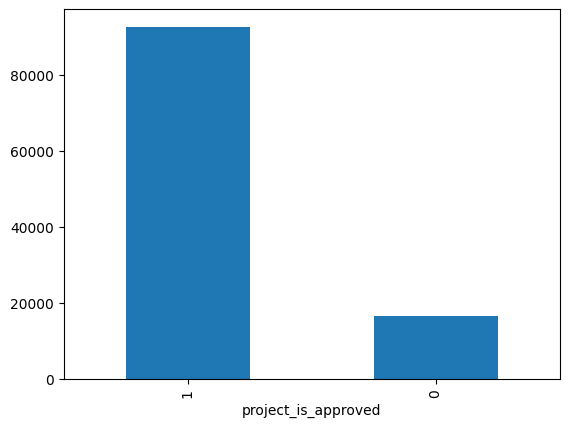

In [588]:
#Write your code here
# Histogram of project_data split by project_is_approved
project_data['project_is_approved'].value_counts().plot(kind='bar')

## Class Balance Observations
Significant class imbalance is observed, necessitating techniques such as k-fold cross-validation with resampling or SMOTE, or the use of models less sensitive to imbalanced data.

**EDA-2**: Analyse the approval rate per state. *You can also plot the approval rates for the top k states*.

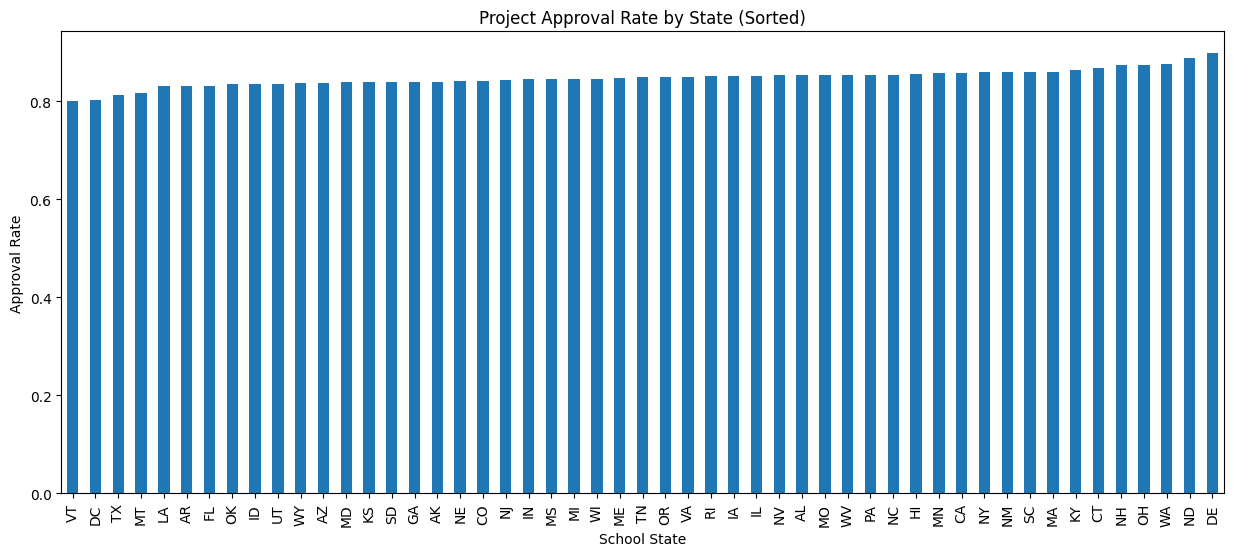

In [589]:
# Calculate the mean approval rate per state
approval_rate_by_state = project_data.groupby('school_state')['project_is_approved'].mean()

# Sort the approval rates by value (ascending order)
approval_rate_by_state_sorted = approval_rate_by_state.sort_values()

# Plot the sorted approval rates as a bar chart
approval_rate_by_state_sorted.plot(kind='bar', figsize=(15, 6)) # Adjust figsize as needed
plt.title('Project Approval Rate by State (Sorted)')
plt.xlabel('School State')
plt.ylabel('Approval Rate')
plt.show()

## State Observations
Project approval rates exhibit a nearly uniform distribution across states, suggesting that `school_state` is likely a weak predictor of approval.

**EDA-3**: Analyse the approval rate per project_grade_category using stacked bar chart

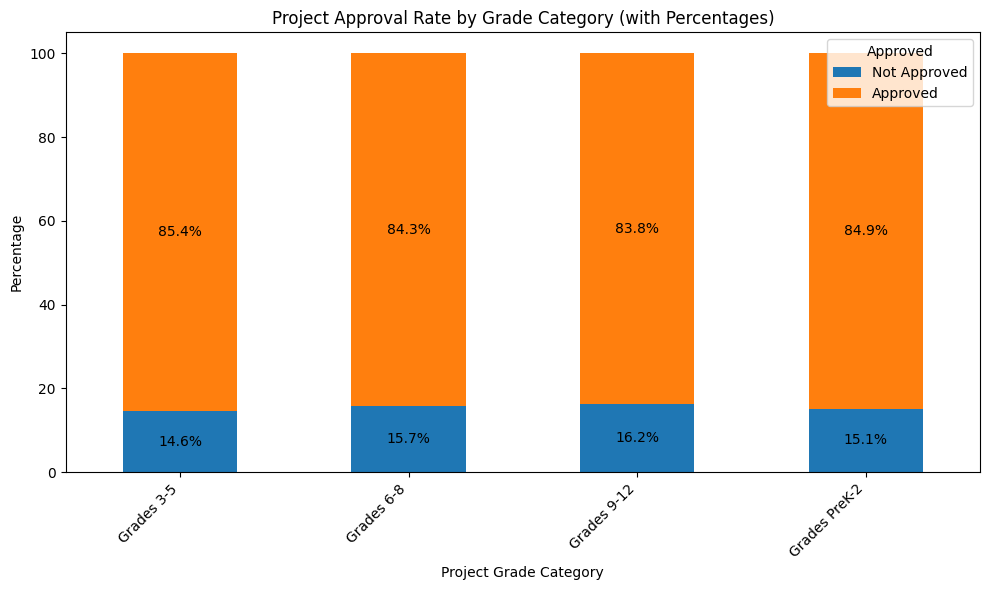

In [590]:
# Group by project_grade_category and project_is_approved, and count occurrences
grade_approval_counts = project_data.groupby(['project_grade_category', 'project_is_approved']).size().unstack()

# Calculate percentages within each grade category
grade_approval_percentages = grade_approval_counts.divide(grade_approval_counts.sum(axis=1), axis=0) * 100

# Plot the stacked bar chart using percentages
ax = grade_approval_percentages.plot(kind='bar', stacked=True, figsize=(10, 6))

plt.title('Project Approval Rate by Grade Category (with Percentages)')
plt.xlabel('Project Grade Category')
plt.ylabel('Percentage')
plt.xticks(rotation=45, ha='right') # Rotate labels for better readability
plt.legend(title='Approved', labels=['Not Approved', 'Approved'])
plt.tight_layout() # Adjust layout to prevent labels overlapping

# Add percentage labels to the bars (optional)
for c in ax.containers:
    labels = [f'{w:.1f}%' if (w := v.get_height()) > 0 else '' for v in c]
    ax.bar_label(c, labels=labels, label_type='center')

plt.show()

In [591]:
# Ensure 'project_submitted_datetime' is in datetime format
project_data['project_submitted_datetime'] = pd.to_datetime(project_data['project_submitted_datetime'])

# Extract the month and create a new 'submission_month' column
project_data['submission_month'] = project_data['project_submitted_datetime'].dt.month

# Extract the day of the month and create a new 'submission_day' column
project_data['submission_day'] = project_data['project_submitted_datetime'].dt.day

# Optional: Drop the original project_submitted_datetime column if no longer needed
# project_data.drop(columns=['project_submitted_datetime'], inplace=True)

# Display the first few rows with the new columns
print(project_data[['project_submitted_datetime', 'submission_month', 'submission_day']].head())

  project_submitted_datetime  submission_month  submission_day
0        2016-12-05 13:43:57                12               5
1        2016-10-25 09:22:10                10              25
2        2016-08-31 12:03:56                 8              31
3        2016-10-06 21:16:17                10               6
4        2016-07-11 01:10:09                 7              11


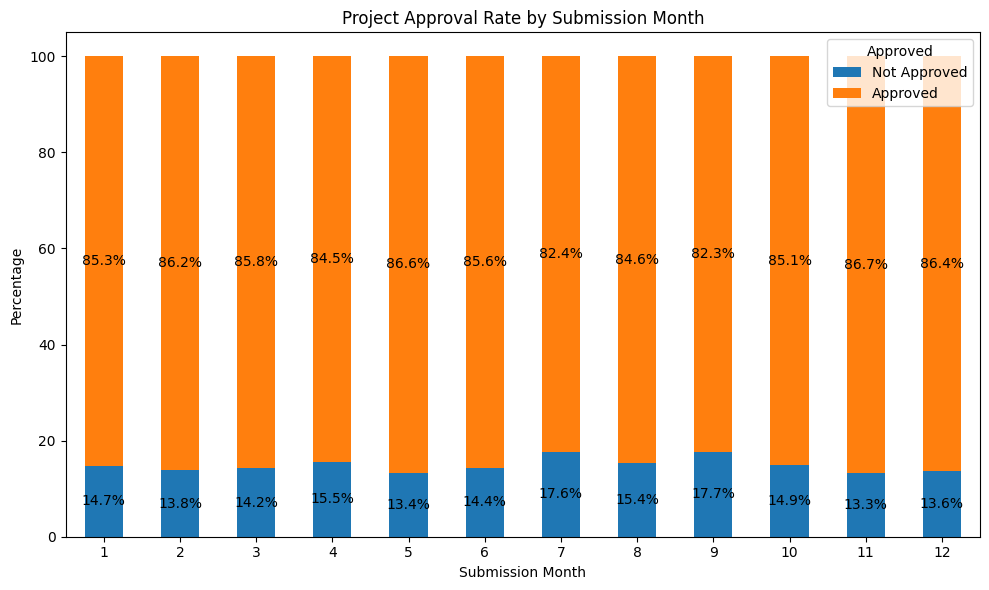

In [592]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# --- Approval Rate by Month ---

# Group by submission_month and project_is_approved, and count occurrences
month_approval_counts = project_data.groupby(['submission_month', 'project_is_approved']).size().unstack()

# Calculate percentages within each month
month_approval_percentages = month_approval_counts.divide(month_approval_counts.sum(axis=1), axis=0) * 100

# Plot the stacked bar chart for months
ax_month = month_approval_percentages.plot(kind='bar', stacked=True, figsize=(10, 6))

plt.title('Project Approval Rate by Submission Month')
plt.xlabel('Submission Month')
plt.ylabel('Percentage')
plt.xticks(rotation=0) # Keep month labels horizontal
plt.legend(title='Approved', labels=['Not Approved', 'Approved'])
plt.tight_layout()

# Add percentage labels (optional)
for c in ax_month.containers:
    labels = [f'{w:.1f}%' if (w := v.get_height()) > 0 else '' for v in c]
    ax_month.bar_label(c, labels=labels, label_type='center')

plt.show()


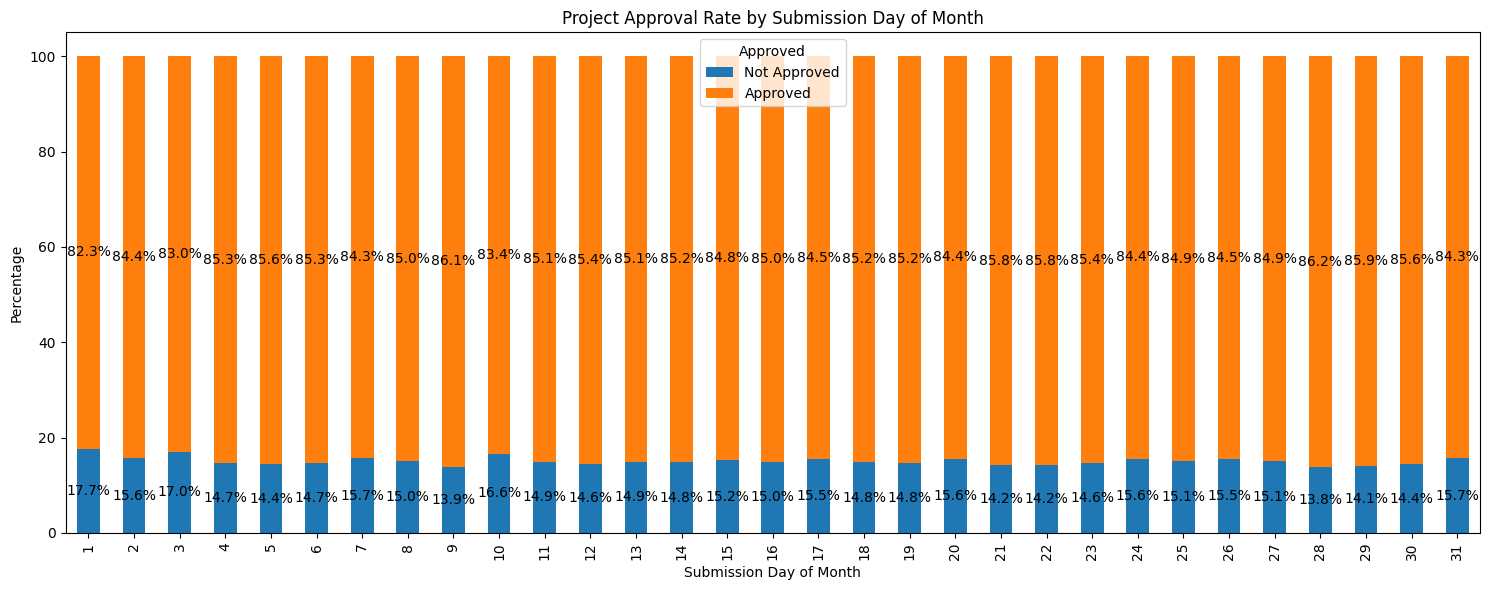

In [593]:

# Group by submission_day and project_is_approved, and count occurrences
day_approval_counts = project_data.groupby(['submission_day', 'project_is_approved']).size().unstack()

# Calculate percentages within each day of month
day_approval_percentages = day_approval_counts.divide(day_approval_counts.sum(axis=1), axis=0) * 100

# Plot the stacked bar chart for days
ax_day = day_approval_percentages.plot(kind='bar', stacked=True, figsize=(15, 6)) # Wider figure for more days

plt.title('Project Approval Rate by Submission Day of Month')
plt.xlabel('Submission Day of Month')
plt.ylabel('Percentage')
plt.xticks(rotation=90) # Rotate day labels for readability
plt.legend(title='Approved', labels=['Not Approved', 'Approved'])
plt.tight_layout()

# Add percentage labels (optional)
for c in ax_day.containers:
    labels = [f'{w:.1f}%' if (w := v.get_height()) > 0 else '' for v in c]
    ax_day.bar_label(c, labels=labels, label_type='center')

plt.show()

## Submission Time Observations
Minimal variance is observed in approval rates across different months or days of submission. Therefore, submission time is not a strong predictor of project approval.

## Grade Category Observations
No strong relationship is apparent between `project_grade_category` and project approval rates.

**EDA-4**: Analyse the approval rate per project_subject_categories.
- Is the approval rate same for all categories?
- Do all categories have almost equal representation?
- Any skewness observed?

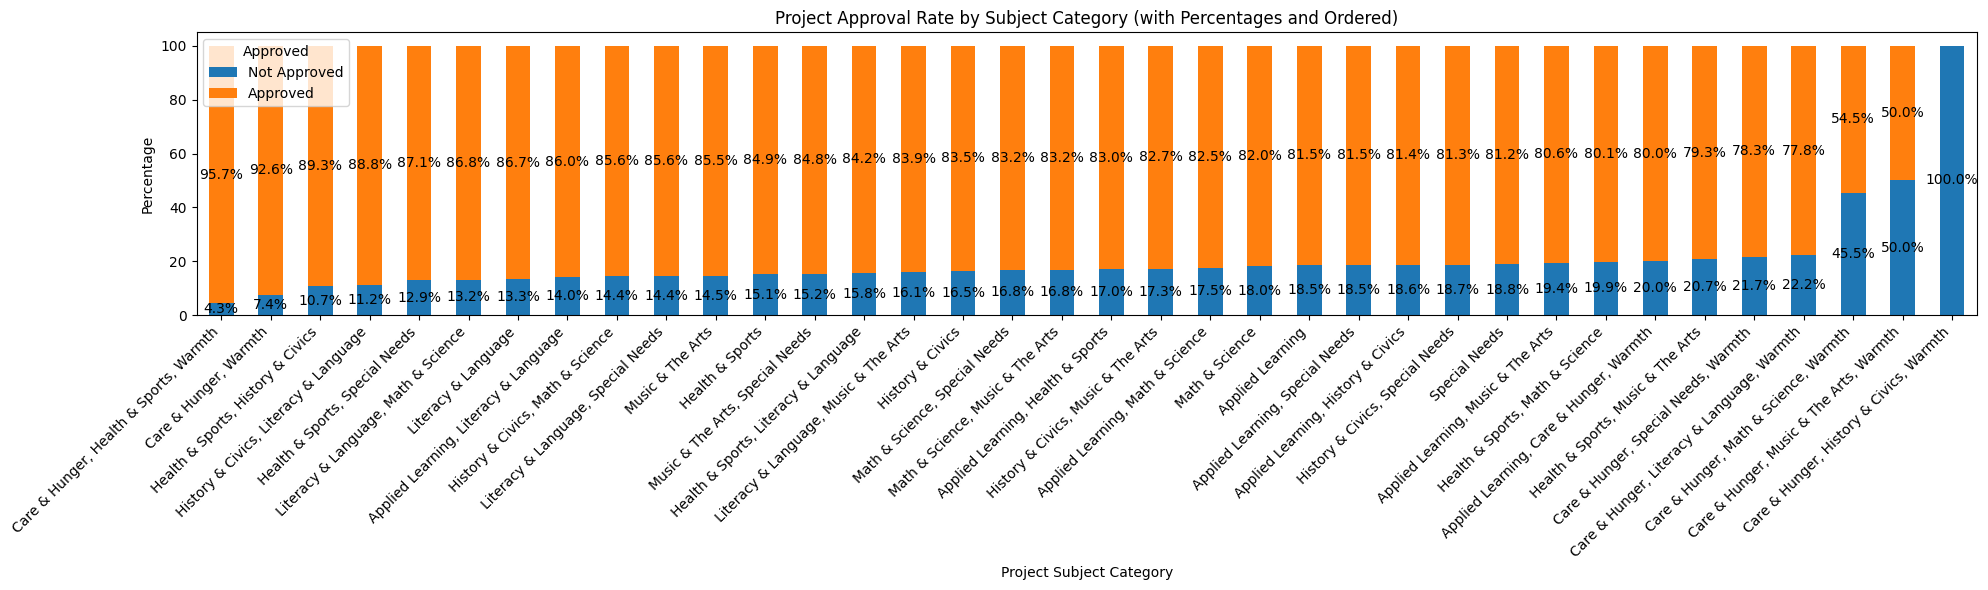

In [594]:
# Group by project_subject_categories and project_is_approved, and count occurrences
subject_approval_counts = project_data.groupby(['project_subject_categories', 'project_is_approved']).size().unstack()

# Calculate percentages within each subject category
subject_approval_percentages = subject_approval_counts.divide(subject_approval_counts.sum(axis=1), axis=0) * 100

# Sort the subject categories by approval rate (percentage of approved projects)
# Assuming 'Approved' projects are in the column with index 1 after unstacking
subject_approval_percentages_sorted = subject_approval_percentages.sort_values(by=1, ascending=False)

# Plot the sorted stacked bar chart using percentages
ax = subject_approval_percentages_sorted.plot(kind='bar', stacked=True, figsize=(20, 6))

plt.title('Project Approval Rate by Subject Category (with Percentages and Ordered)')
plt.xlabel('Project Subject Category')
plt.ylabel('Percentage')
plt.xticks(rotation=45, ha='right') # Rotate labels for better readability
plt.legend(title='Approved', labels=['Not Approved', 'Approved'])
plt.tight_layout() # Adjust layout to prevent labels overlapping

# Add percentage labels to the bars (optional)
for c in ax.containers:
    labels = [f'{w:.1f}%' if (w := v.get_height()) > 0 else '' for v in c]
    ax.bar_label(c, labels=labels, label_type='center')

plt.show()

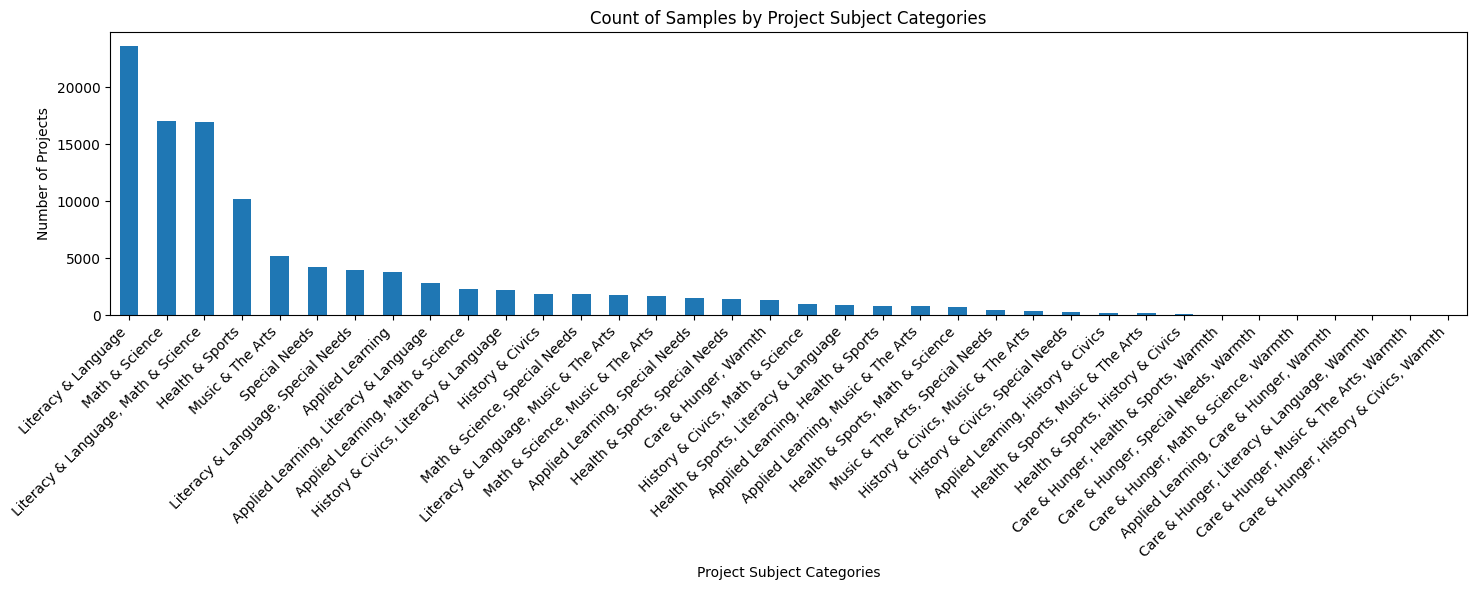

In [595]:
# Get the count of samples for each unique project subject category
subject_category_counts = project_data['project_subject_categories'].value_counts()

# Plot the counts as a bar chart (similar to a histogram for categorical data)
plt.figure(figsize=(15, 6)) # Adjust figure size for better readability
subject_category_counts.plot(kind='bar')
plt.title('Count of Samples by Project Subject Categories')
plt.xlabel('Project Subject Categories')
plt.ylabel('Number of Projects')
plt.xticks(rotation=45, ha='right') # Rotate labels for better readability
plt.tight_layout() # Adjust layout to prevent labels overlapping
plt.show()

## Approval Outlier Observations for Subject Categories
An analysis of categories with the lowest counts reveals that five of these categories exhibit extreme approval rates. Given that categories can be composite, further investigation into breaking down these composite categories is warranted.

In [596]:
# Show the counts for the lowest performing k categories

# Define the specific subject categories you want to count
categories_to_count = ['Care & Hunger, History & Civics, Warmth', 'Care & Hunger, Music & The Arts, Warmth', 'Care & Hunger, Math & Science, Warmth', 'Care & Hunger, Literacy & Language, Warmth', 'Care & Hunger, Health & Sports, Warmth']

# Filter the dataframe to include only the specified categories
filtered_project_data = project_data[project_data['project_subject_categories'].isin(categories_to_count)]

# Get the counts for the specified categories
category_counts = filtered_project_data['project_subject_categories'].value_counts()


# Print the counts
print("Counts for specified subject categories:")
print(category_counts)

Counts for specified subject categories:
project_subject_categories
Care & Hunger, Health & Sports, Warmth        23
Care & Hunger, Math & Science, Warmth         11
Care & Hunger, Literacy & Language, Warmth     9
Care & Hunger, Music & The Arts, Warmth        2
Care & Hunger, History & Civics, Warmth        1
Name: count, dtype: int64


## Subject Category Observations
Some categories are reordered combinations of each other (e.g., 'Health & Sports, History and Civics' and 'History and Civics, Health & Sports'). These values should be harmonized to ensure uniqueness. The `MultiLabelBinarizer` from `scikit-learn` will be used for this purpose.

For low-performing categories, insufficient sample sizes prevent drawing definitive conclusions regarding their impact on approval rates.

In [597]:
## Do the same thing for subject subcategory

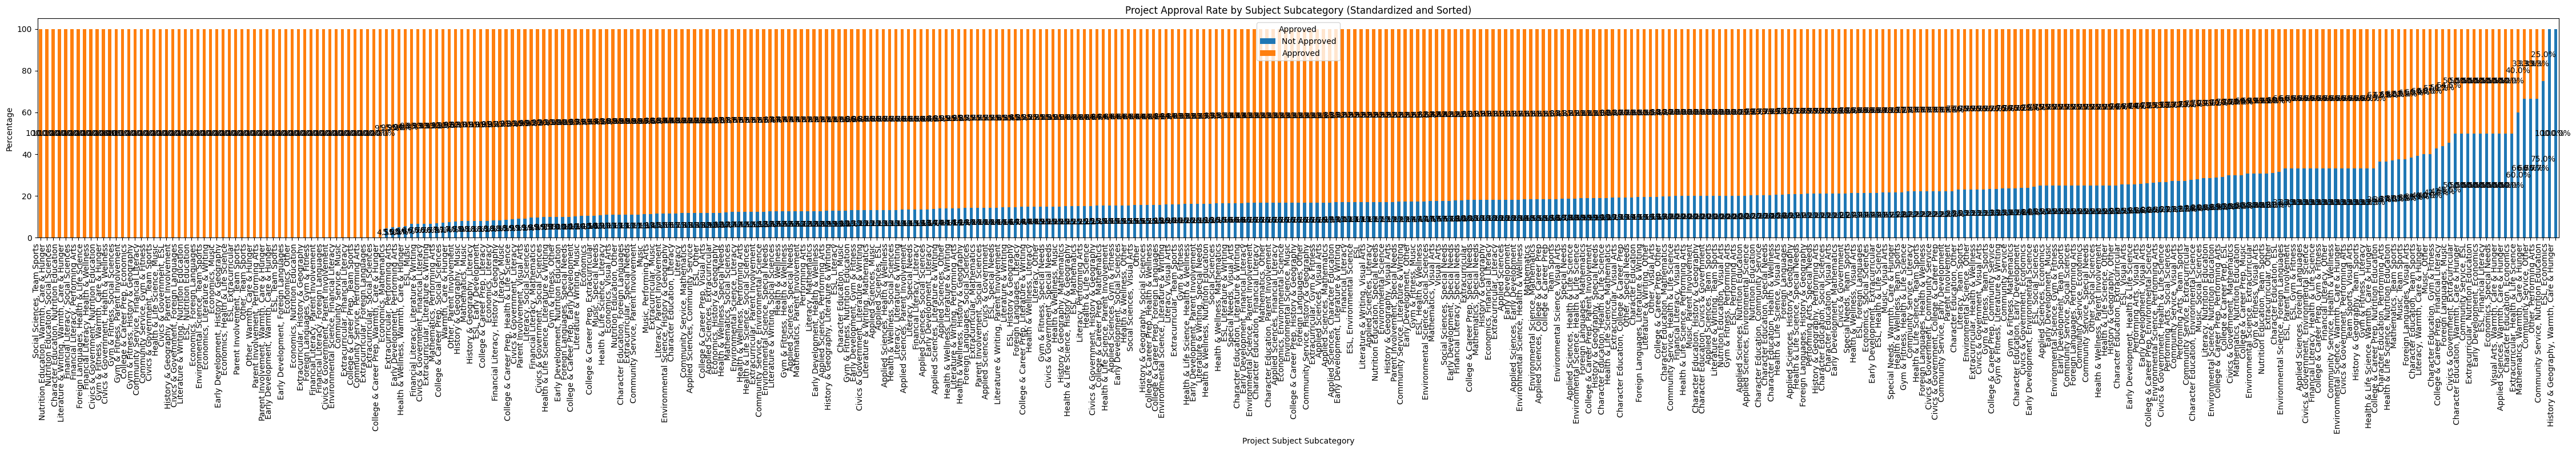

In [598]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Assuming you have already standardized the 'project_subject_subcategories' column
# If not, apply the standardization function you used for main categories:
project_data['project_subject_subcategories_standardized'] = project_data['project_subject_subcategories'].apply(standardize_subject_categories)
# Use this new column for grouping

# For this example, let's assume the standardized column is named 'project_subject_subcategories_standardized'
# If you've already replaced the original column, use 'project_subject_subcategories'

subcategory_col_to_use = 'project_subject_subcategories' # Use the column with standardized values

# Group by standardized subcategory and project_is_approved, and count occurrences
subcategory_approval_counts = project_data.groupby([subcategory_col_to_use, 'project_is_approved']).size().unstack()

# Calculate percentages within each subcategory
subcategory_approval_percentages = subcategory_approval_counts.divide(subcategory_approval_counts.sum(axis=1), axis=0) * 100

# Sort the subcategories by approval rate (percentage of approved projects)
# Assuming 'Approved' projects are in the column with index 1 after unstacking
subcategory_approval_percentages_sorted = subcategory_approval_percentages.sort_values(by=1, ascending=False)

# Plot the sorted stacked bar chart using percentages
ax = subcategory_approval_percentages_sorted.plot(kind='bar', stacked=True, figsize=(45, 8)) # Adjust figure size as needed

plt.title('Project Approval Rate by Subject Subcategory (Standardized and Sorted)')
plt.xlabel('Project Subject Subcategory')
plt.ylabel('Percentage')
plt.xticks(rotation=90, ha='right') # Rotate labels for better readability
plt.legend(title='Approved', labels=['Not Approved', 'Approved'])
plt.tight_layout() # Adjust layout to prevent labels overlapping

# Add percentage labels to the bars (optional)
for c in ax.containers:
    # Handle cases where a category might have only one class (approved or not approved)
    labels = [f'{w:.1f}%' if (w := v.get_height()) > 0 else '' for v in c]
    ax.bar_label(c, labels=labels, label_type='center')

plt.show()

## Subject Subcategory Observations
While some subcategories show clear differences in approval rates, it is crucial to account for the impact of low sample sizes, which might lead to extreme success/failure rates. The analysis needs to distinguish between genuine trends and statistical artifacts arising from limited data points.

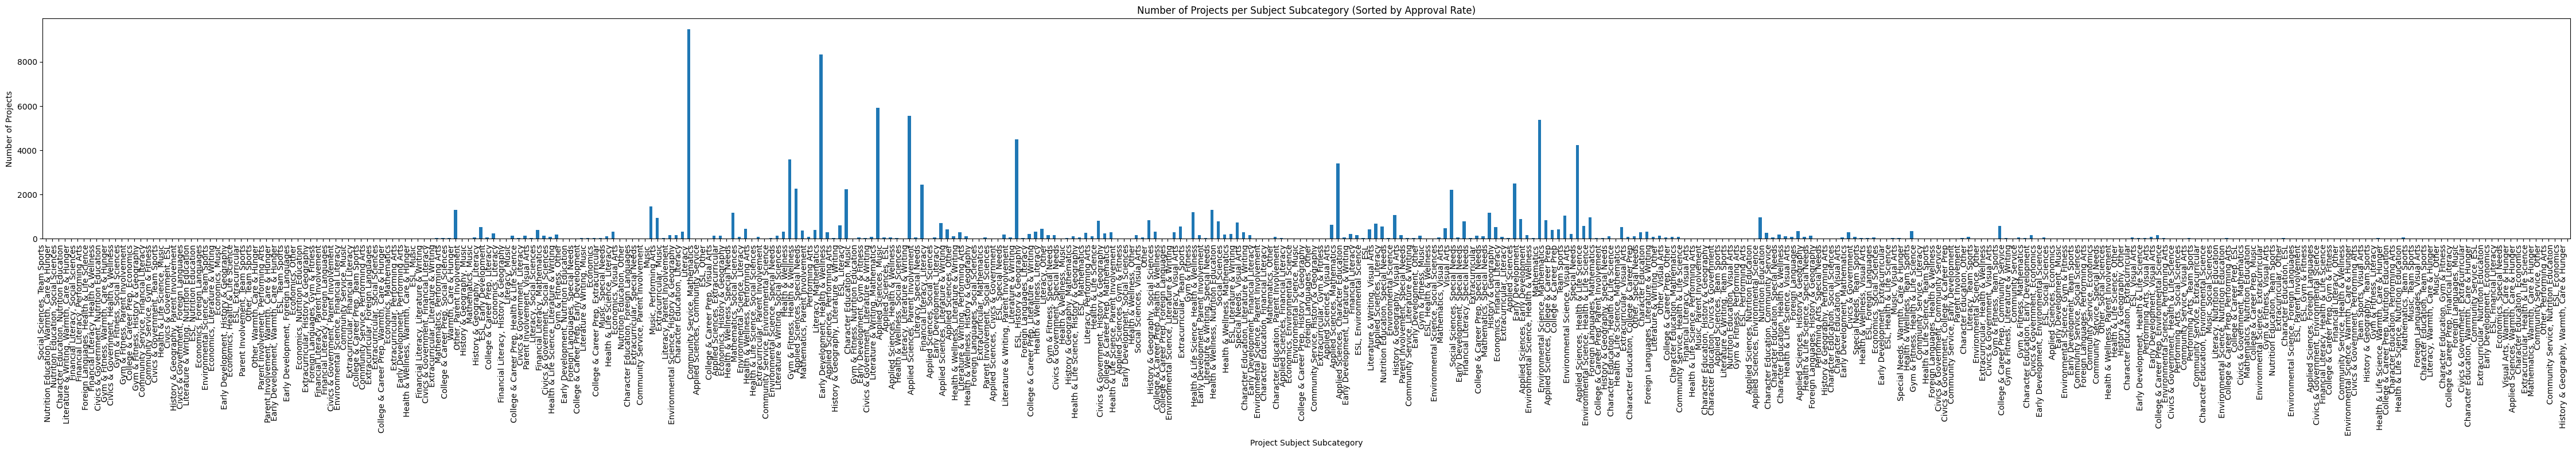

In [599]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming you still have the subcategory_approval_percentages_sorted DataFrame
# which contains the approval rates sorted by approval rate

# Get the sorted order of subcategories from the previous chart
sorted_subcategory_order = subcategory_approval_percentages_sorted.index

# Get the count of samples for each unique project subject subcategory
# Ensure you use the same column as in the previous analysis
subcategory_counts = project_data['project_subject_subcategories'].value_counts()

# Reindex the counts to match the sorted order of the approval rate chart
subcategory_counts_sorted = subcategory_counts.reindex(sorted_subcategory_order)

# Plot the sorted sample counts as a bar chart
plt.figure(figsize=(45, 8)) # Use the same figure size as the approval rate chart for comparison
subcategory_counts_sorted.plot(kind='bar')

plt.title('Number of Projects per Subject Subcategory (Sorted by Approval Rate)')
plt.xlabel('Project Subject Subcategory')
plt.ylabel('Number of Projects')
plt.xticks(rotation=90, ha='right') # Use the same rotation as the approval rate chart
plt.tight_layout() # Adjust layout
plt.show()

By preserving the index order, it is evident that many outliers in approval rates correspond to subcategories with only one or two submissions. While some variance is attributable to the low number of submissions, other subcategories demonstrate significant deviations from the mean despite larger sample sizes. Therefore, subject subcategories will be retained and encoded.

**EDA-5**: Is there any gender bias for approval?
  - Use the teacher_prefix column.

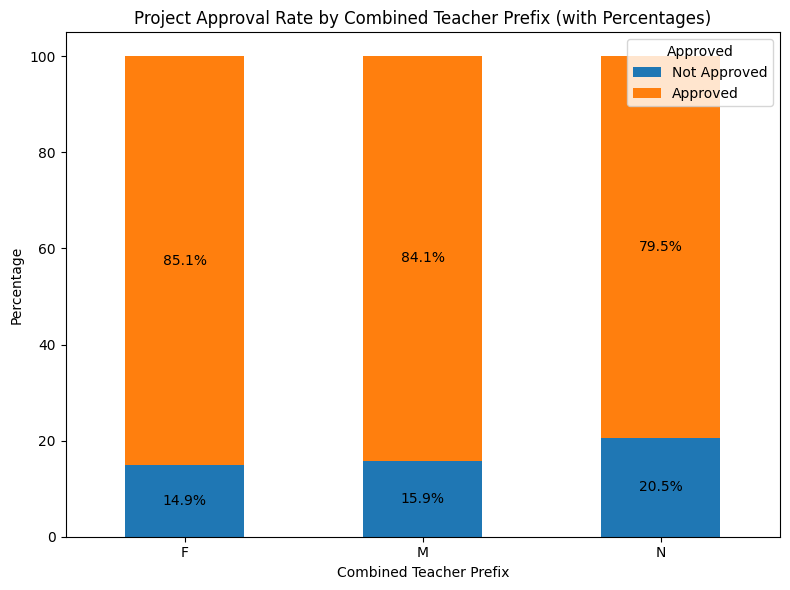

In [600]:
# Create a new combined teacher prefix category
def combine_teacher_prefix(prefix):
    if prefix in ['Mrs.', 'Ms.']:
        return 'F'
    elif prefix == 'Mr.':
        return 'M'
    elif prefix in ['Dr.', 'Teacher']:
        return 'N' # Dr. and Teacher are gender-neutral titles
    else:
        return 'N' # Fallback for any unexpected or missing prefixes

project_data['teacher_prefix_combined'] = project_data['teacher_prefix'].apply(combine_teacher_prefix)

# Group by the new combined category and project_is_approved, and count occurrences
prefix_approval_counts = project_data.groupby(['teacher_prefix_combined', 'project_is_approved']).size().unstack()

# Calculate percentages within each combined prefix category
prefix_approval_percentages = prefix_approval_counts.divide(prefix_approval_counts.sum(axis=1), axis=0) * 100

# Plot the stacked bar chart using percentages
ax = prefix_approval_percentages.plot(kind='bar', stacked=True, figsize=(8, 6))

plt.title('Project Approval Rate by Combined Teacher Prefix (with Percentages)')
plt.xlabel('Combined Teacher Prefix')
plt.ylabel('Percentage')
plt.xticks(rotation=0) # No rotation needed for few categories
plt.legend(title='Approved', labels=['Not Approved', 'Approved'])
plt.tight_layout() # Adjust layout

# Add percentage labels to the bars (optional)
for c in ax.containers:
    labels = [f'{w:.1f}%' if (w := v.get_height()) > 0 else '' for v in c]
    ax.bar_label(c, labels=labels, label_type='center')

plt.show()

## Gender Observations
Project proposers identified as male or female exhibit similar approval rates. However, projects submitted by individuals with gender-neutral titles (e.g., 'Teacher', 'Dr.') appear to have a slightly negative impact on approval rates.

**EDA-6**: Check whether the approval rate depends on the amount and quantity of the resources?
- Provide descriptive statstics for approved & not-approved projects.
- with appropriate visualizations for a better understanding of the results

In [601]:
## Write code for additional analysis here


/tmp/ipykernel_253/3195752059.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cost_approval_counts = project_data.groupby(['cost_bin', 'project_is_approved']).size().unstack()


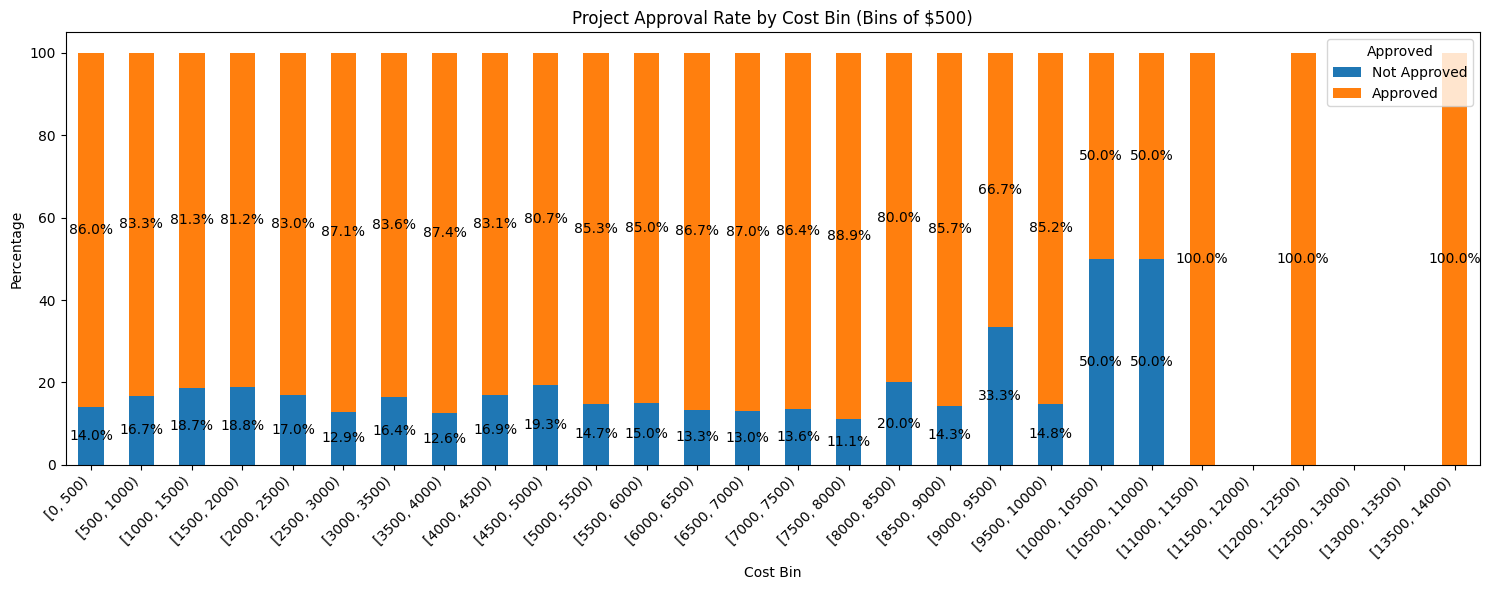

In [602]:
# Determine the range of costs
min_cost = project_data['cost'].min()
max_cost = project_data['cost'].max()
bin_width = 500

# Calculate the bin edges
# Start from 0 and go up to the next multiple of bin_width that is greater than max_cost
bins = range(0, int(max_cost) + bin_width, bin_width)

# Bin the 'cost' column into bins of width
project_data['cost_bin'] = pd.cut(project_data['cost'], bins=bins, right=False) # Use right=False to include the left edge and exclude the right

# Group by cost bin and project_is_approved, and count occurrences
cost_approval_counts = project_data.groupby(['cost_bin', 'project_is_approved']).size().unstack()

# Calculate percentages within each cost bin (optional)
cost_approval_percentages = cost_approval_counts.divide(cost_approval_counts.sum(axis=1), axis=0) * 100

# Plot the stacked bar chart (using percentages)
ax = cost_approval_percentages.plot(kind='bar', stacked=True, figsize=(15, 6)) # Increased figure size

plt.title('Project Approval Rate by Cost Bin (Bins of $500)')
plt.xlabel('Cost Bin')
plt.ylabel('Percentage')
plt.xticks(rotation=45, ha='right') # Rotate labels for better readability
plt.legend(title='Approved', labels=['Not Approved', 'Approved'])
plt.tight_layout() # Adjust layout

# Add percentage labels to the bars (optional), formatted to one decimal place
for c in ax.containers:
    labels = [f'{w:.1f}%' if (w := v.get_height()) > 0 else '' for v in c]
    ax.bar_label(c, labels=labels, label_type='center')

plt.show()

# You might want to drop the 'cost_bin' column after visualization if not needed for modeling
project_data.drop('cost_bin', axis=1, inplace=True)

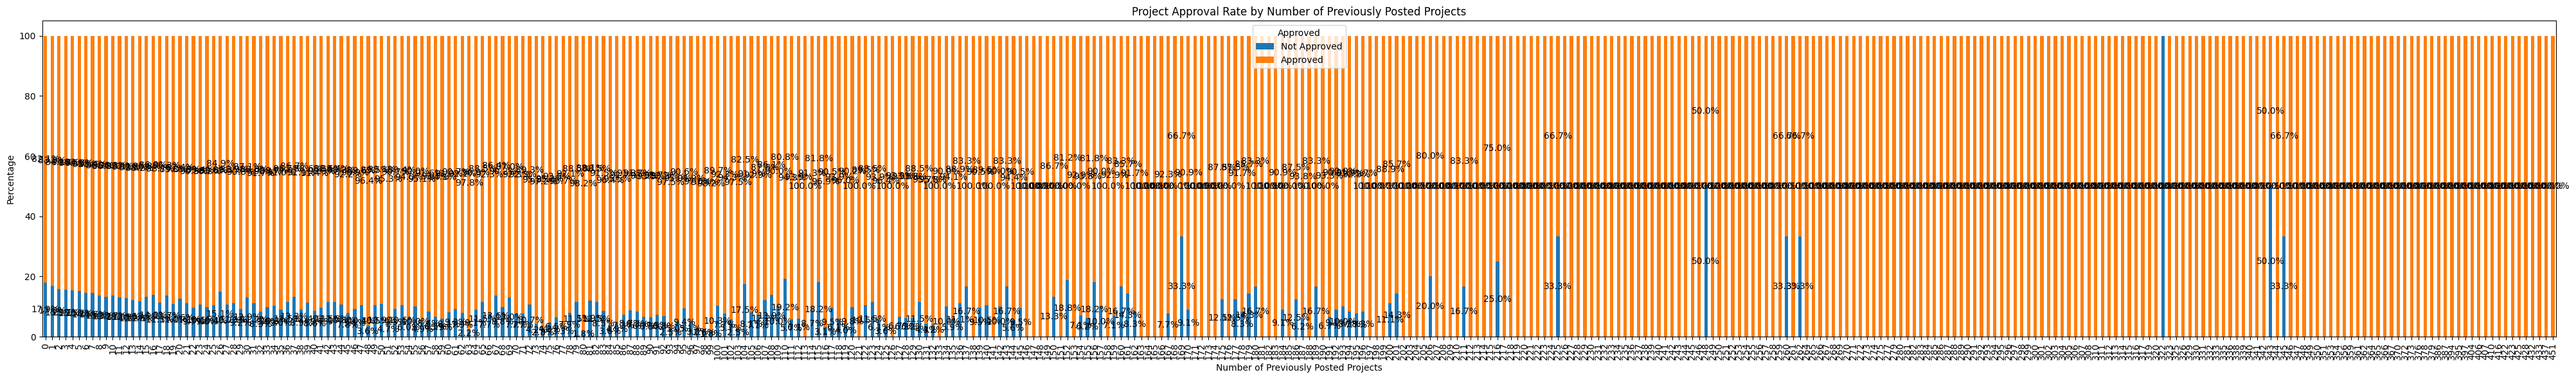

In [603]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Group by teacher_number_of_previously_posted_projects and project_is_approved, and count occurrences
previous_projects_approval_counts = project_data.groupby(['teacher_number_of_previously_posted_projects', 'project_is_approved']).size().unstack()

# Calculate percentages within each number of previous projects
previous_projects_approval_percentages = previous_projects_approval_counts.divide(previous_projects_approval_counts.sum(axis=1), axis=0) * 100

# Sort by the number of previously posted projects
previous_projects_approval_percentages_sorted = previous_projects_approval_percentages.sort_index()

# Plot the stacked bar chart using percentages
ax = previous_projects_approval_percentages_sorted.plot(kind='bar', stacked=True, figsize=(40, 6)) # Adjust figure size as needed

plt.title('Project Approval Rate by Number of Previously Posted Projects')
plt.xlabel('Number of Previously Posted Projects')
plt.ylabel('Percentage')
plt.xticks(rotation=90) # Rotate labels if there are many distinct values
plt.legend(title='Approved', labels=['Not Approved', 'Approved'])
plt.tight_layout()

# Add percentage labels (optional)
for c in ax.containers:
    labels = [f'{w:.1f}%' if (w := v.get_height()) > 0 else '' for v in c]
    ax.bar_label(c, labels=labels, label_type='center')

plt.show()

Initial observations suggest that proposers with a higher number of previously submitted projects tend to have greater success. A larger proportion of 'Not Approved' projects are associated with fewer previous submissions. While some outliers exist, further analysis would be required to validate whether these are due to batch submissions or other factors.

/tmp/ipykernel_253/3642273646.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  prev_projects_approval_counts_binned = project_data.groupby(['prev_projects_bin', 'project_is_approved']).size().unstack()


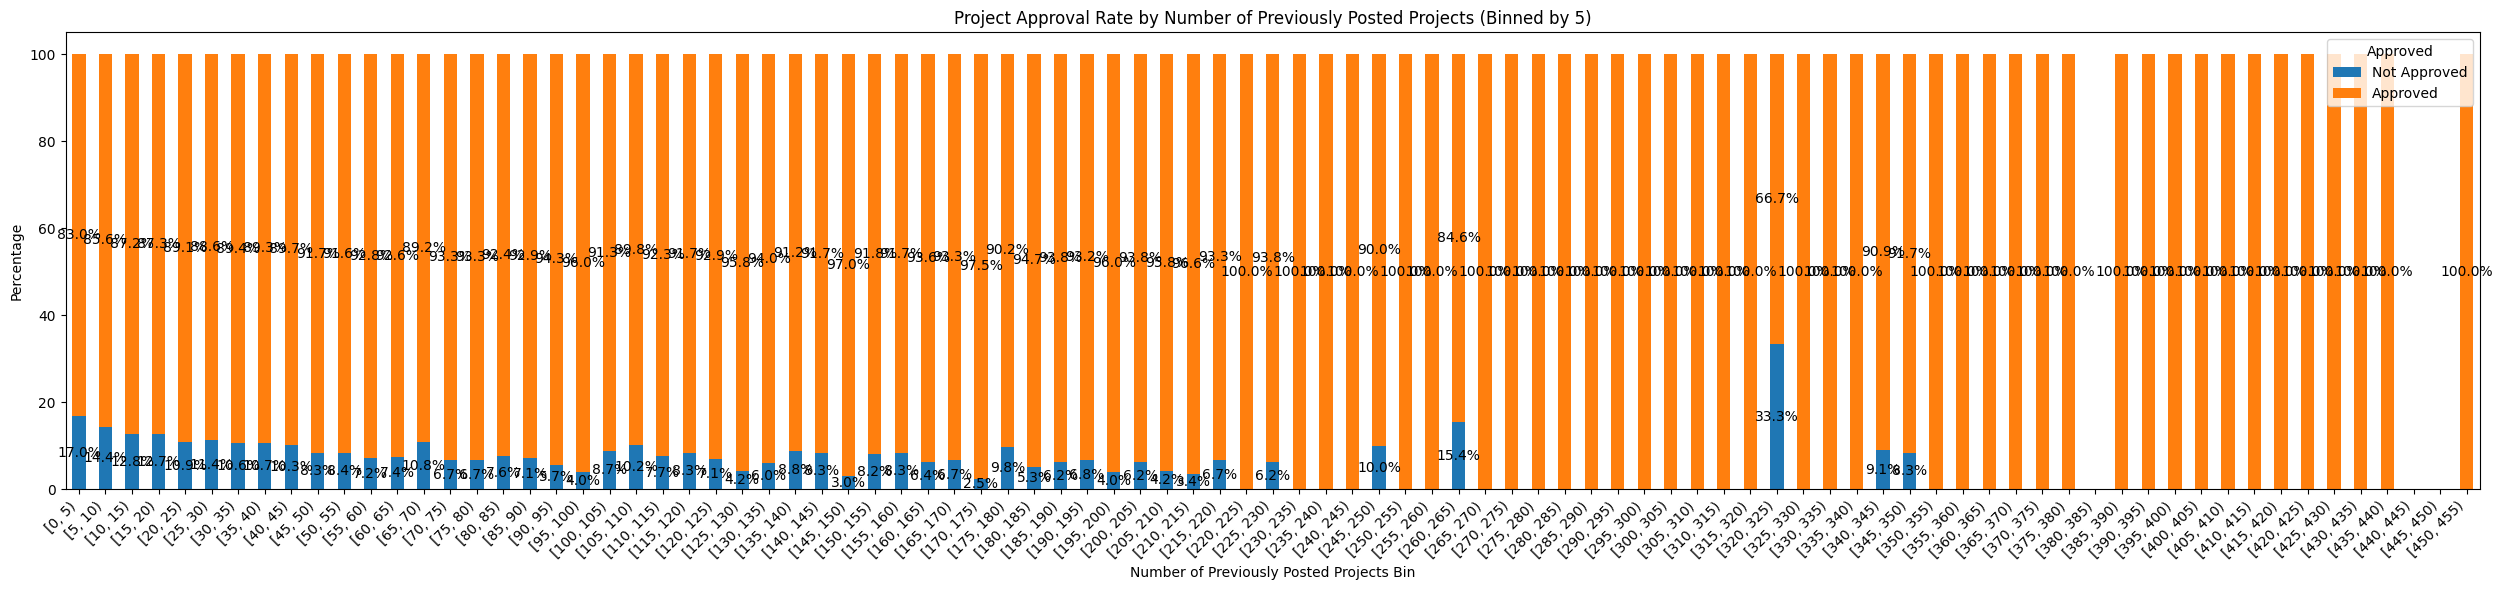

In [604]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Determine the range of previously posted projects
min_prev_projects = project_data['teacher_number_of_previously_posted_projects'].min()
max_prev_projects = project_data['teacher_number_of_previously_posted_projects'].max()
bin_width = 5

# Calculate the bin edges
# Start from 0 and go up to the next multiple of bin_width that is greater than max_prev_projects
bins = range(0, int(max_prev_projects) + bin_width, bin_width)

# Bin the 'teacher_number_of_previously_posted_projects' column into bins of width 5
project_data['prev_projects_bin'] = pd.cut(project_data['teacher_number_of_previously_posted_projects'], bins=bins, right=False) # Use right=False

# Group by previous projects bin and project_is_approved, and count occurrences
prev_projects_approval_counts_binned = project_data.groupby(['prev_projects_bin', 'project_is_approved']).size().unstack()

# Calculate percentages within each bin
prev_projects_approval_percentages_binned = prev_projects_approval_counts_binned.divide(prev_projects_approval_counts_binned.sum(axis=1), axis=0) * 100

# Plot the stacked bar chart using percentages
ax = prev_projects_approval_percentages_binned.plot(kind='bar', stacked=True, figsize=(25, 6)) # Adjust figure size as needed

plt.title('Project Approval Rate by Number of Previously Posted Projects (Binned by 5)')
plt.xlabel('Number of Previously Posted Projects Bin')
plt.ylabel('Percentage')
plt.xticks(rotation=45, ha='right') # Rotate labels for better readability
plt.legend(title='Approved', labels=['Not Approved', 'Approved'])
plt.tight_layout()

# Add percentage labels (optional)
for c in ax.containers:
    labels = [f'{w:.1f}%' if (w := v.get_height()) > 0 else '' for v in c]
    ax.bar_label(c, labels=labels, label_type='center')

plt.show()

# You might want to drop the 'prev_projects_bin' column after visualization
# project_data.drop('prev_projects_bin', axis=1, inplace=True)

## Previous Submissions Observations
With some exceptions, a general trend indicates that proposers with more experience, as measured by the number of previous projects submitted, tend to have higher success rates. However, this observation might be misleading due to potential illusions of experience.

The existence of 100% success rates for certain individuals is highly improbable in a genuine human-driven process, suggesting the possibility of batch submissions or repeated content. Previous analysis of essay content has already indicated instances of copied or pasted material.

## Cost Observations
Project approval rates do not appear to be significantly correlated with the total cost of the project.

**EDA-7**: Conduct further analysis to uncover patterns, anomalies, and relationships within the data.
- Summary statistics
- Distribution plots
- Correlation matrix (for numerical features)
- how approval rate changes across the different features

In [605]:
# print all unique values of project sub categories
print(project_data['project_subject_subcategories'].unique())


['ESL, Literacy' 'Civics & Government, Team Sports'
 'Health & Wellness, Team Sports' 'Literacy, Mathematics' 'Mathematics'
 'Literature & Writing, Special Needs' 'Literacy, Special Needs'
 'Health & Wellness' 'Literacy, Literature & Writing' 'Literacy'
 'Literacy, Parent Involvement'
 'Environmental Science, Health & Life Science' 'Special Needs'
 'Applied Sciences, Literature & Writing' 'Early Development'
 'Health & Life Science, Special Needs' 'Music'
 'Applied Sciences, Mathematics' 'Foreign Languages, Mathematics'
 'Literacy, Other' 'Health & Life Science, Literacy'
 'Economics, Financial Literacy' 'Literature & Writing' 'Team Sports'
 'Literature & Writing, Mathematics' 'Health & Wellness, Literacy'
 'Gym & Fitness, Health & Wellness' 'Literacy, Visual Arts'
 'Warmth, Care & Hunger' 'Mathematics, Social Sciences' 'Visual Arts'
 'College & Career Prep, Literature & Writing' 'Environmental Science'
 'Applied Sciences, Health & Life Science' 'ESL, Literature & Writing'
 'College & 

In [606]:
## Write code for additional analysis here

/tmp/ipykernel_253/2238676688.py:34: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout() # Adjust layout


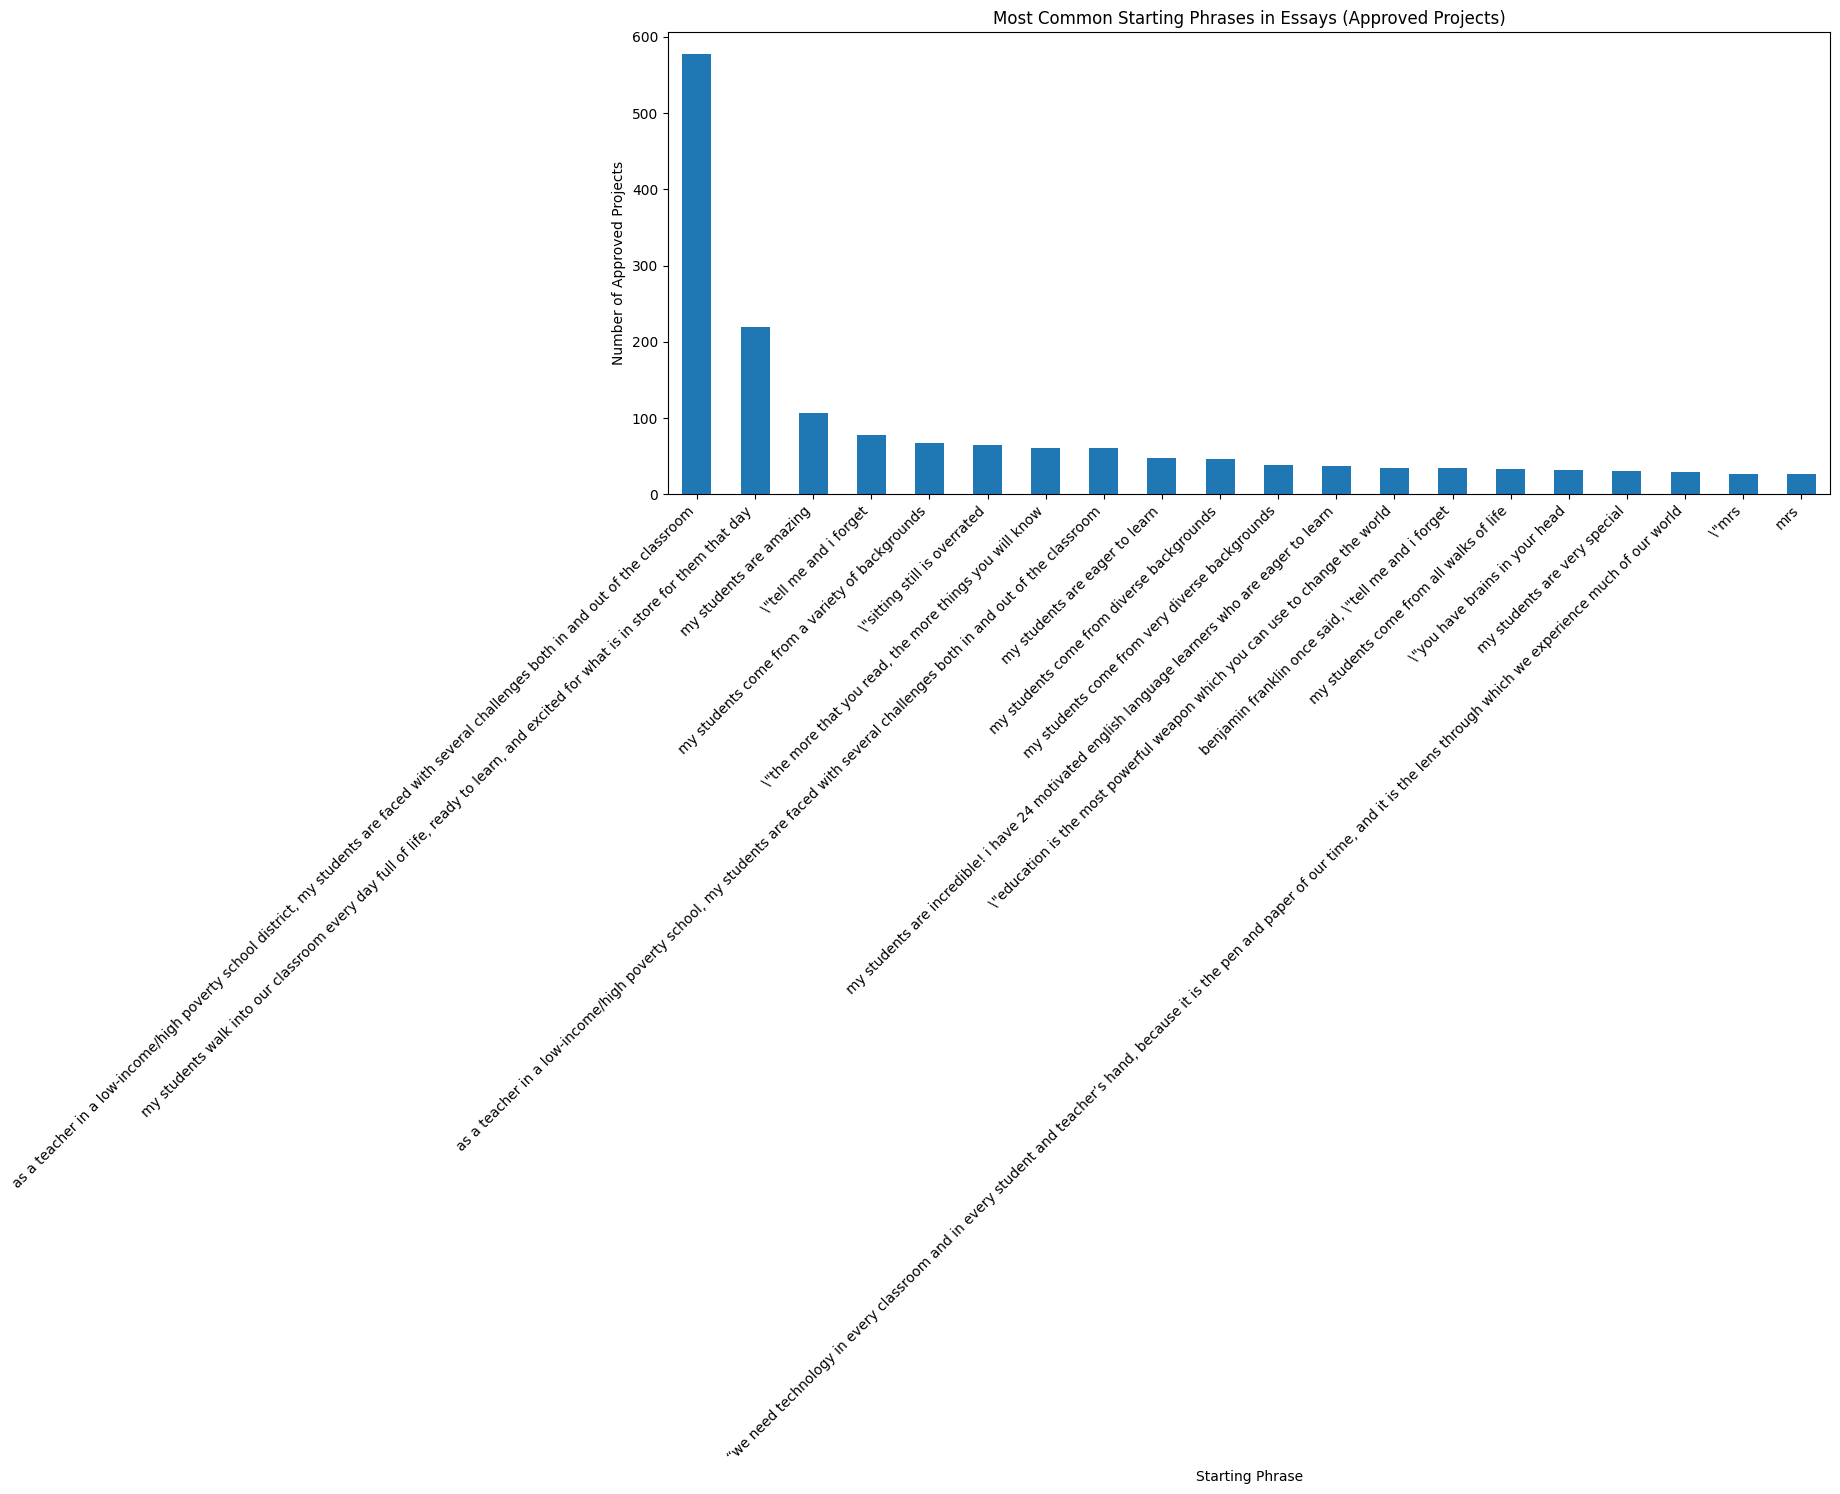

In [607]:
# Are there magic words / phrases? Is there copy pasting?

# Function to extract the first part of the string before the first period (same as before)
def get_first_sentence(text):
    if isinstance(text, str):
        # Find the index of the first period
        first_period_index = text.find('.')
        if first_period_index != -1:
            # Return the substring before the first period, strip leading/trailing whitespace
            return text[:first_period_index].strip().lower()
        else:
            # If no period, return the whole string (or a placeholder)
            return text.strip()
    else:
        return '' # Return empty string for non-string values

# Filter the dataframe to include only approved projects
approved_projects_df = project_data[project_data['project_is_approved'] == 1].copy()

# Apply the function to the 'essay' column of approved projects to get the first sentence
approved_projects_df['first_essay_sentence'] = approved_projects_df['essay'].apply(get_first_sentence)

# Get the counts of the most common first sentences for approved projects
# Adjust 'n' as needed
top_first_sentences_approved = approved_projects_df['first_essay_sentence'].value_counts().nlargest(20)

# Plot a bar chart of the most common first sentences for approved projects
plt.figure(figsize=(15, 6)) # Adjust figure size as needed
top_first_sentences_approved.plot(kind='bar')
plt.title('Most Common Starting Phrases in Essays (Approved Projects)')
plt.xlabel('Starting Phrase')
plt.ylabel('Number of Approved Projects')
plt.xticks(rotation=45, ha='right') # Rotate labels for better readability
plt.tight_layout() # Adjust layout
plt.show()

## Essay Content Observations

- Many essays incorporate famous quotes relevant to the project's field. Exploring the recognition of such quotes as a binary feature using natural language processing libraries like spaCy could provide valuable insights.
- It is observed that teachers frequently reuse or copy-paste opening lines in their essays, indicating a potential shortcut in content creation.

## EDA Observations

- Evidence suggests that teachers frequently reuse opening lines in their essays.
- A common observation is the repetition of opening phrases across multiple proposals.
- Proposers often utilize simplified approaches when crafting their content.
- Most factors analyzed do not significantly influence project approval, indicating a relatively unbiased approval process.
- Teacher prefix appears to have a minor influence on approval rates.
- Some proposals include quotes from notable figures.

In [608]:
## Write the code to perform any necessary sanity checks before proceeding further
project_data.head()

,Unnamed: 0,id,teacher_id,teacher_prefix,school_state,project_submitted_datetime,project_grade_category,project_subject_categories,project_subject_subcategories,project_title,...,teacher_number_of_previously_posted_projects,project_is_approved,cost,resources_quantity,essay,submission_month,submission_day,project_subject_subcategories_standardized,teacher_prefix_combined,prev_projects_bin
0,160221,p253737,c90749f5d961ff158d4b4d1e7dc665fc,Mrs.,IN,2016-12-05 13:43:57,Grades PreK-2,Literacy & Language,"ESL, Literacy",Educational Support for English Learners at Home,...,0,0,596.36,23,"My students are English learners that are working on English as their second or third languages. We are a melting pot of refugees, immigrants, and native-born Americans bringing the gift of language to our school. \r\n\r\n We have over 24 languages represented in our English Learner program with students at every level of mastery. We also have over 40 countries represented with the families within our school. Each student brings a wealth of knowledge and experiences to us that open our eyes to new cultures, beliefs, and respect. \""The limits of your language are the limits of your world.\""-Ludwig Wittgenstein Our English learner's have a strong support system at home that begs for more resources. Many times our parents are learning to read and speak English along side of their children. Sometimes this creates barriers for parents to be able to help their child learn phonetics, letter recognition, and other reading skills.\r\n\r\nBy providing these dvd's and players, students are able to continue their mastery of the English language even if no one at home is able to assist. All families with students within the Level 1 proficiency status, will be a offered to be a part of this program. These educational videos will be specially chosen by the English Learner Teacher and will be sent home regularly to watch. The videos are to help the child develop early reading skills.\r\n\r\nParents that do not have access to a dvd player will have the opportunity to check out a dvd player to use for the year. The plan is to use these videos and educational dvd's for the years to come for other EL students.\r\n",12,5,"ESL, Literacy",F,"[0, 5)"
1,140945,p258326,897464ce9ddc600bced1151f324dd63a,Mr.,FL,2016-10-25 09:22:10,Grades 6-8,"Health & Sports, History & Civics","Civics & Government, Team Sports",Wanted: Projector for Hungry Learners,...,7,1,299.00,1,"Our students arrive to our school eager to learn. They are polite, generous, and strive to be the best they can be. They know that with an education, they can succeed in life and help improve on the lives that they have now.\r\n\r\nOur school focuses on families with low incomes and tries to give each student the education they deserve. While we do not have much, the students use the materials they are given and do the very best they can with them. The projector we need for our school is very crucial for the academic improvement of our students. As technology continues to grow, there are so many resources in the internet that we as teachers use to further the growth of our students. However, our school is very limited with resources - particularly, technology - and without it, we are at a disadvantage. One of the things that could really help our classrooms is a projector.\r\n\r\n\r\nWith a projector, not only is it crucial with instruction, but also for the growth of our students. With a projector, we can show presentations, documentaries, photos of historical land sites, math problems and so much more. With a projector, we can make teaching and learning easier while also targeting the different types of learners we have in our classrooms: auditory, visual, kinesthetic, etc. \r\n",10,25,"Civics & Government, Team Sports",M,"[5, 10)"
2,21895,p182444,3465aaf82da834c0582ebd0ef8040ca0,Ms.,AZ,2016-08-31 12:03:56,Grades 6-8,Health & Sports,"Health & Wellness, Team Sports",Soccer Equipment for AWESOME Middle School Studen

### Distributions

Generating distribution plots for the following columns:
['teacher_number_of_previously_posted_projects', 'cost', 'resources_quantity', 'submission_month', 'submission_day']


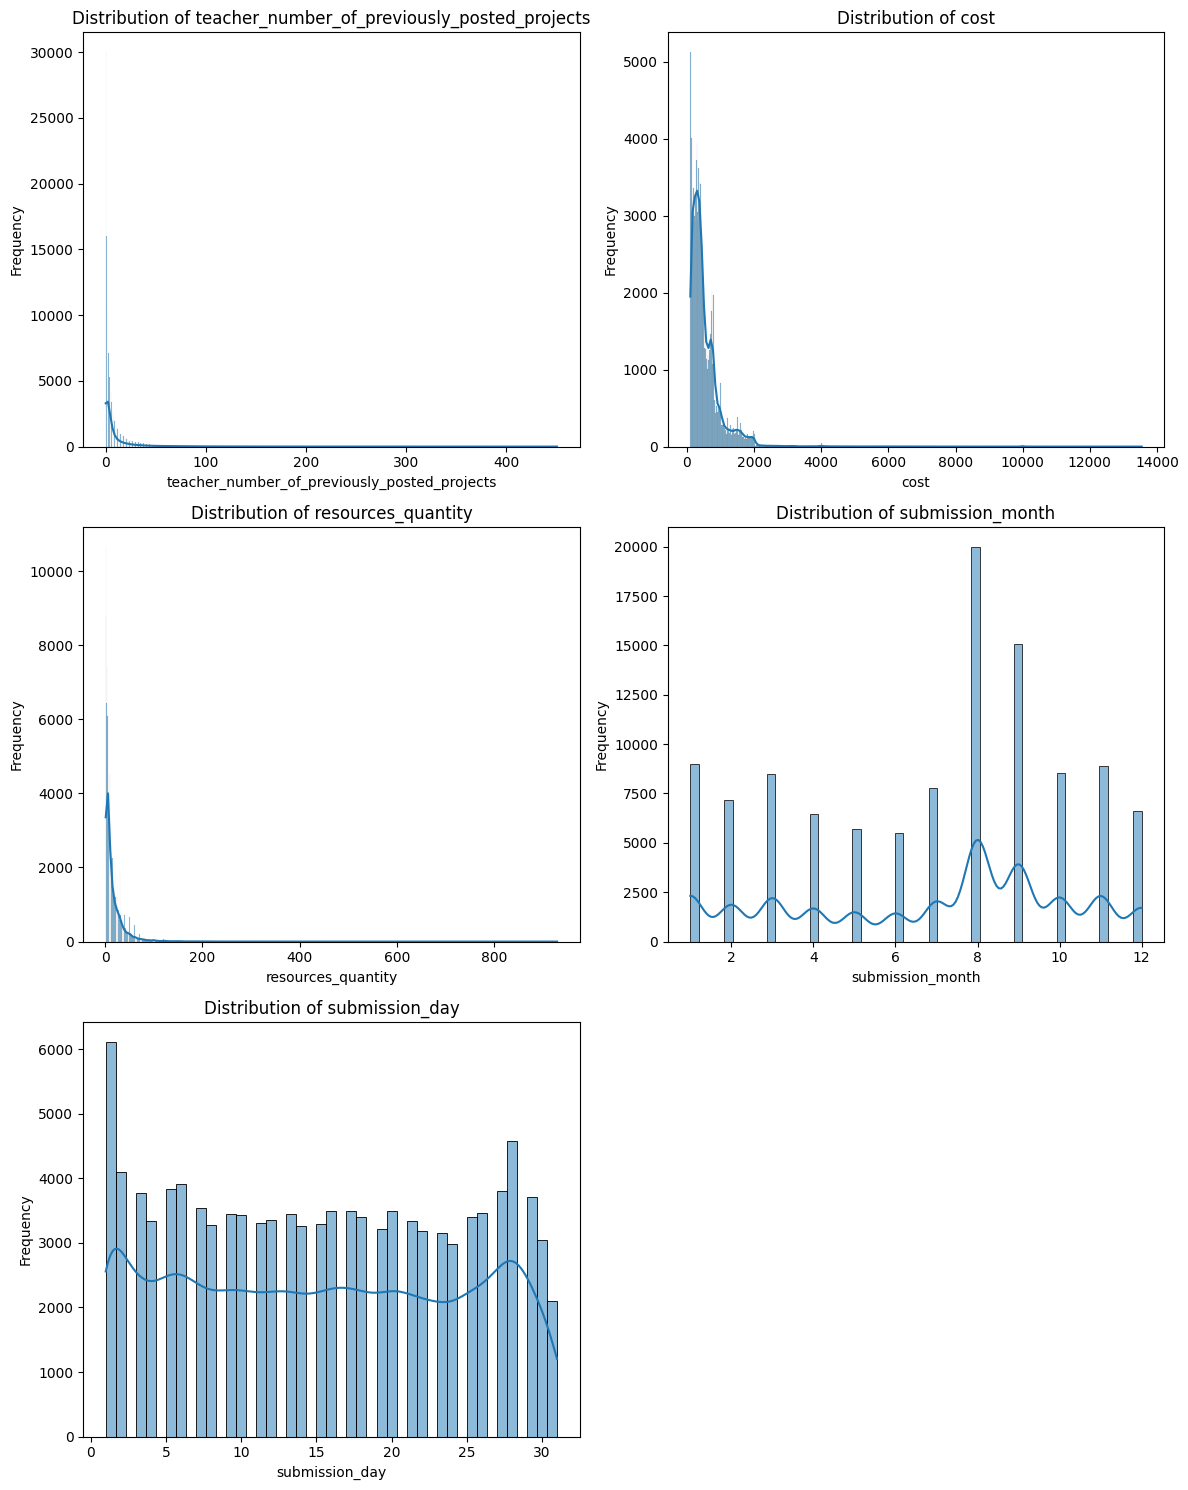

In [609]:
## Create Distribution Charts for Original Numerical Columns

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Based on your previous code, the numerical columns from original data (not one-hot encoded) are:
original_numerical_cols = [
    'teacher_number_of_previously_posted_projects',
    'cost',
    'resources_quantity',
    'submission_month',
    'submission_day'
]

# Ensure these columns exist in the current project_data DataFrame
numerical_cols_to_plot = [col for col in original_numerical_cols if col in project_data.columns]

if not numerical_cols_to_plot:
    print("No original numerical columns found in the DataFrame to plot distributions for.")
else:
    print("Generating distribution plots for the following columns:")
    print(numerical_cols_to_plot)

    # Determine the number of subplots needed
    n_cols = 2 # Number of columns for the subplot grid
    n_rows = (len(numerical_cols_to_plot) + n_cols - 1) // n_cols # Calculate rows needed

    # Create the figure and subplots
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, n_rows * 5)) # Adjust figure size as needed
    axes = axes.flatten() # Flatten the axes array for easy iteration

    # Iterate through the numerical columns and create a histogram for each
    for i, col in enumerate(numerical_cols_to_plot):
        sns.histplot(data=project_data, x=col, kde=True, ax=axes[i])
        axes[i].set_title(f'Distribution of {col}')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Frequency')

    # Hide any unused subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
    plt.show()

#### Distribution Observations
None of the numerical columns exhibit a normal distribution. Therefore, a normalization technique, such as Min-Max Scaling, will be employed.

In [610]:
# Delete column by column index
# Get the names of the first three columns
columns_to_drop = project_data.columns[:4]

# Drop the columns
project_data.drop(columns=columns_to_drop, inplace=True)


There are 5 steps to be done before we proceed to model building

- Handle the class imbalance in the data
- Text Pre-Processing for raw text columns
- Feature Encoding (One-hot encoding, etc.) for categorical columns
- Scaling (Standardization, Normalization, etc.) for numeric columns
- train-test-validation split

In [611]:
memory_usage()

Total RAM: 62.75 GB
Available RAM: 50.18 GB
Used RAM: 11.96 GB
RAM Usage Percentage: 20.0%


# Pre-Modelling Data Preparation

As per the target variable distribution seen earlier, the datapoints for class "0" (not approved) is much low when compared with class "1" (approved).
This may lead to the model learning more than "1" class as compared to "0" class. Also the number of records are huge - 100k. You can follow these steps:

  - **Undersampling**: Reduce the data imbalance by selecting all instances from the minority class (class "0") and randomly selecting an equal number of instances from the majority class (class "1").

  - **Oversampling**: Increase the representation of the minority class by techniques like Random Oversampling or SMOTE to balance the dataset.

Choosing the appropriate method is crucial. It depends on various factors and the specific requirements of your model.As the number of columns would increase significantly once we start using text processing, it is imperative to take a pragmatic decision here.

## Dataset Size Management
To mitigate performance issues and facilitate processing during development, the dataset size will be reduced. The code for this reduction will be commented out in the final version to ensure full dataset utilization.

In [612]:
memory_usage()

Total RAM: 62.75 GB
Available RAM: 50.18 GB
Used RAM: 11.96 GB
RAM Usage Percentage: 20.0%


In [613]:
# count samples by outcome and see balance.
print(f"Approved {project_data['project_is_approved'].value_counts()}")

Approved project_is_approved
1    92706
0    16542
Name: count, dtype: int64


In [614]:
# # Randomly reduce the data by 90% of samples.
# import pandas as pd

# # Randomly reduce the dataset by keeping 10% of the samples
# # Use a random_state for reproducibility
# project_data = project_data.sample(frac=0.1, random_state=42)

# # Optional: Reset the index of the new subset dataframe
# project_data = project_data.reset_index(drop=True)

# # Display the shape of the original and subset dataframes to confirm the reduction
# print("Original dataframe shape:", project_data.shape)
# print("Subset dataframe shape:", project_data.shape)

# # Display the first few rows of the subset
# print(project_data.head())

In [615]:
## Balance the dataset using Random Undersampling (without train/test split)
sample_size=10000
# Install imblearn if you haven't already
!pip install imbalanced-learn
def balance_dataset(df, target_col, random_state=42):
    import pandas as pd
    from sklearn.utils import resample

    # Assuming your data is in project_data and your target is 'project_is_approved'

    # Separate minority and majority classes
    df_majority = project_data[project_data['project_is_approved']==1]
    df_minority = project_data[project_data['project_is_approved']==0]

    # # Determine the number of samples in the minority class
    # n_samples_minority = len(df_minority)

    # Undersample the majority class
    # Replace=False ensures sampling without replacement
    df_majority_undersampled = resample(df_majority,
                                        replace=False,
                                        n_samples=sample_size,
                                        random_state=42) # Set a random state for reproducibility

    df_minority_undersampled = resample(df_minority,
                                        replace=False,
                                        n_samples=sample_size,
                                        random_state=42) # Set a random state for reproducibility

    # Concatenate the minority class dataframe with the undersampled majority class dataframe
    df_balanced_undersampled = pd.concat([df_majority_undersampled, df_minority_undersampled])
    df = df_balanced_undersampled

    # Reset the index of the new dataframe
    df = df_balanced_undersampled.reset_index(drop=True)

    # Display the new class distribution
    print("Class distribution after Random Undersampling:")
    print(df['project_is_approved'].value_counts())
    return df

    # The balanced dataset is stored in df_balanced_undersampled

In [616]:
project_data = balance_dataset(project_data, 'project_is_approved')

Class distribution after Random Undersampling:
project_is_approved
1    10000
0    10000
Name: count, dtype: int64


In [617]:
project_data.shape

(20000, 17)

In [618]:
memory_usage()

Total RAM: 62.75 GB
Available RAM: 50.43 GB
Used RAM: 11.71 GB
RAM Usage Percentage: 19.6%


**Text-Processing**

There are two steps to be performed here

- Text Cleaning
- Conversion of text features to numeric features

## Text Processing

***Text Cleaning***

Raw text often presents several challenges. Some of them include:

- **Noise and Irrelevant Information**: Raw text can include extraneous information that may not be useful for analysis or modeling.

- **Inconsistent Formatting**: Text data can vary in format, which makes it difficult to standardize and process.

- **Spelling and Grammar Errors**: Errors in spelling, grammar, and punctuation can affect the quality of text analysis and processing.

- **High Dimensionality**: Text data can be high-dimensional due to the large number of unique words or terms, complicating analysis and modeling.

- **Language Variability**: Variations in language usage, slang, or domain-specific terminology can impact the consistency and effectiveness of text analysis.


- Let's clean the text to improve the quality of data
  
  - Decontracting text, removing escape sequences, special characters and stop words

  - You can use two popular libraries to handle text data.
    1. Natural Language ToolKit (nltk)
    2. Regular Expressions (re)

To help you prepare your text for analysis, we have included some basic functions for cleaning and normalization. Use these functions as a starting point and tailor them to achieve optimal text quality.

### Text cleaning

In [619]:
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import re
import nltk

nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')

# Decontracting text involves expanding contractions into their full forms.
def decontract_text(text):

    # decontract text

    text = re.sub(r"won't", "will not", text)
    text = re.sub(r"can\'t", "can not", text)

    text = re.sub(r"n\'t", " not", text)
    text = re.sub(r"\'re", " are", text)
    text = re.sub(r"\'s", " is", text)
    text = re.sub(r"\'d", " would", text)
    text = re.sub(r"\'ll", " will", text)
    text = re.sub(r"\'t", " not", text)
    text = re.sub(r"\'ve", " have", text)
    text = re.sub(r"\'m", " am", text)

    return text

# Escape sequences are special character combinations used to represent characters that cannot be directly represented.
# These often need to be removed for text processing.

def remove_escape_sequences(text):

    # remove escape sequences

    text = text.replace('\\r', ' ')
    text = text.replace('\\"', ' ')
    text = text.replace('\\n', ' ')

    return text


# Remove special characters using regular expressions.
# Special characters are characters that are not letters or numbers.
# These often include punctuation, symbols, and control characters.

def remove_special_characters(text):
    text = re.sub('[^A-Za-z0-9]+', ' ', text)
    return text


# Stop words are common words that often carry little semantic meaning (e.g., "the," "and," "is").
# Removing them can help focus on the more important words in the text.
def remove_stop_words(text):

        stop_words = set(stopwords.words('english'))
        word_tokens = word_tokenize(text)
        filtered_sentence = [w for w in word_tokens if not w.lower() in stop_words]
        #with no lower case conversion
        filtered_sentence = []
        for w in word_tokens:
                if w not in stop_words:
                        filtered_sentence.append(w)
        return filtered_sentence


def preprocess_text(text):

  text = decontract_text(text)
  text = remove_escape_sequences(text)
  text = remove_special_characters(text)
  text = remove_stop_words(text)

  text = ' '.join(text)

  return text.lower().strip()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


#### Clean Essay

In [620]:
memory_usage()

Total RAM: 62.75 GB
Available RAM: 50.53 GB
Used RAM: 11.61 GB
RAM Usage Percentage: 19.5%


In [621]:
## using the preprocess_text function let's replace the essay column with the output
project_data['essay'] = project_data['essay'].apply(preprocess_text)

In [622]:
pd.set_option('display.max_colwidth', None)
project_data['essay'].head()

,essay
0,the students i privilege serving bilingual fluent spanish english they demonstrate linguistic talents times parts society caused view negative my goal students feel proud characteristics set apart rest crowd on campus bilingual population students dramatically growing our school recognized one serves low income families school district it common hear comments others i teach kids i question well my kids amazing they set skills surpassing expectations society they resilient hopeful future i love determination show quality life want lead thank believing vision potential kids my project provide chapter book student reading level forty third grade bilingual students our school library enough books child one often book read home luxury students this opportunity would allow students become captivated literature fostering enthusiasm growing second language benefits development second language acquisition my wish stepping stone students get caught love reading be active participant growing qualities lifelong reader hearts minds awesome kids
1,our classroom library one first things i introduce students first day school i love sharing love reading watching love reading grow throughout school year this year i get opportunity share classroom library 25 students some students already found love reading job foster others guidance support help develop thoughts reading with great classroom library students benefit getting lost great book i excited present project each year students opportunity read golden sower nominees vote favorite book 10 included project 2016 2017 golden sower nominees we class book club students opportunity read vote favorite book among books i also included classroom supplies project make classroom run smoothly i requesting pencil sharpener clipboards student organizer easel whiteboard well materials i grateful opportunity build rich classroom library students we use books included project small groups whole group read aloud well individual reading
2,my students range kindergarten sixth graders learning disabilities each students bring unique style learning literacy math centers rock classroom my students bring enlightenment encouragement day they also bring new challenges these kids i want strong individuals go amazing places no disability hold back dreams motto never give our school rural oklahoma opportunities available students outside school we also low income school failing score reading standardized test as new special education teacher goal create believers classroom i want students know anything set mind means creating challenges my students inspire everyday classroom work play grow our special education room serves many students different needs it primarily education room pull classroom core subjects testing center safe place calm it easy see always one thing happening room there lot times room needs dark for instance reading classes work hard read novels deserve watch movie also student melt mode darker environment tends help calm quicker for times looking activities students we small light box ipads looking another option the students enjoy building blocks already i came across light blocks i knew students would love we already ball chairs found really help students we need another there visible difference work kids get pick seat type this flexible seating allows students get wiggles without disturbing rest students students expected seated 7 hours school these seats others like increase student learning productivity
3,one reasons i love working kids still untainted part world live my students exception although living considered low income neighborhood unaware disadvantages face teacher question i often hear students they see school like tv believe i try best level playing field we already blessed chromebooks centers unfortunately allows students access chromebooks centers with addition three chromebooks able use whole class 1 every 3 students research read using chromebooks chromebooks allow us sup

#### Clean Title

In [623]:
## Lets do the same for the project title
project_data['project_title'] = project_data['project_title'].apply(preprocess_text)

In [624]:
pd.set_option('display.max_colwidth', None)
project_data['project_title'].head()

,project_title
0,just one chapter
1,building strong readers
2,activities dark
3,chromebooks textbooks
4,open can worms school composting


#### Clean Resource Summary

In [625]:
## resource summary
project_data['project_resource_summary'] = project_data['project_resource_summary'].apply(preprocess_text)

In [626]:
pd.set_option('display.max_colwidth', None)
project_data['project_resource_summary'].head()

,project_resource_summary
0,my students need books interest encourage abilities think critically they also need book level authentically create positive reading experience
1,my students need variety classroom learning materials included 30 books improve classroom library easel whiteboard small group learning heavy duty pencil sharpeners well beneficial materials
2,my students need activities dark others students videos watch
3,my students need chromebooks make class technologically savvy
4,my students need two worm composting bins add school garden our goal use garden hands classroom life earth science


### Lemmatize

In [627]:
memory_usage()

Total RAM: 62.75 GB
Available RAM: 50.36 GB
Used RAM: 11.78 GB
RAM Usage Percentage: 19.8%


In [628]:
!pip install -U spacy
#python -m spacy download en_core_web_sm
import spacy

# Load English tokenizer, tagger, parser and NER
nlp = spacy.load("en_core_web_sm")

In [629]:
# ## Sample
# doc = nlp(text)

# # Analyze syntax
# print("Noun phrases:", [chunk.text for chunk in doc.noun_chunks])
# print("Verbs:", [token.lemma_ for token in doc if token.pos_ == "VERB"])

# # Find named entities, phrases and concepts
# for entity in doc.ents:
#     print(entity.text, entity.label_)

In [630]:
# Load the English language model
try:
    nlp = spacy.load("en_core_web_sm")
    print("spaCy model loaded successfully.")
except OSError:
    print("Downloading spaCy model...")
    !python -m spacy download en_core_web_sm
    nlp = spacy.load("en_core_web_sm")
    print("spaCy model loaded successfully.")

# Function to lemmatize text using spaCy
def lemmatize_text(text):
    if isinstance(text, str):
        doc = nlp(text)
        # Extract lemmas and join them back into a string
        lemmas = [token.lemma_ for token in doc]
        return " ".join(lemmas)
    else:
        return "" # Return empty string for non-string inputs


spaCy model loaded successfully.


#### Lemmatization of Essays
TF-IDF vectorization will be employed for essay features to effectively capture word frequencies, particularly given the high probability of word repetition within essays.

In [631]:
memory_usage()

Total RAM: 62.75 GB
Available RAM: 50.90 GB
Used RAM: 11.24 GB
RAM Usage Percentage: 18.9%


In [632]:
# Let's do a sample
project_data_subset = project_data.head(10).copy()
# Apply the lemmatization function to the 'essay' column
# This might take some time for a large dataset
project_data_subset['lemmatized_essay'] = project_data_subset['essay'].apply(lemmatize_text)



pd.set_option('display.max_colwidth', None)

# Display the first few rows with the original and lemmatized essays
project_data_subset[['essay', 'lemmatized_essay']].head()

,essay,lemmatized_essay
0,the students i privilege serving bilingual fluent spanish english they demonstrate linguistic talents times parts society caused view negative my goal students feel proud characteristics set apart rest crowd on campus bilingual population students dramatically growing our school recognized one serves low income families school district it common hear comments others i teach kids i question well my kids amazing they set skills surpassing expectations society they resilient hopeful future i love determination show quality life want lead thank believing vision potential kids my project provide chapter book student reading level forty third grade bilingual students our school library enough books child one often book read home luxury students this opportunity would allow students become captivated literature fostering enthusiasm growing second language benefits development second language acquisition my wish stepping stone students get caught love reading be active participant growing qualities lifelong reader hearts minds awesome kids,the student I privilege serve bilingual fluent spanish english they demonstrate linguistic talent time part society cause view negative my goal student feel proud characteristic set apart rest crowd on campus bilingual population student dramatically grow our school recognize one serve low income family school district it common hear comment other I teach kid I question well my kid amazing they set skill surpass expectation society they resilient hopeful future I love determination show quality life want lead thank believe vision potential kid my project provide chapter book student reading level forty third grade bilingual student our school library enough book child one often book read home luxury student this opportunity would allow student become captivate literature foster enthusiasm grow second language benefit development second language acquisition my wish step stone student get catch love read be active participant grow quality lifelong reader heart mind awesome kid
1,our classroom library one first things i introduce students first day school i love sharing love reading watching love reading grow throughout school year this year i get opportunity share classroom library 25 students some students already found love reading job foster others guidance support help develop thoughts reading with great classroom library students benefit getting lost great book i excited present project each year students opportunity read golden sower nominees vote favorite book 10 included project 2016 2017 golden sower nominees we class book club students opportunity read vote favorite book among books i also included classroom supplies project make classroom run smoothly i requesting pencil sharpener clipboards student organizer easel whiteboard well materials i grateful opportunity build rich classroom library students we use books included project small groups whole group read aloud well individual reading,our classroom library one first thing I introduce student first day school I love share love read watch love read grow throughout school year this year I get opportunity share classroom library 25 student some student already find love read job foster other guidance support help develop thought read with great classroom library student benefit getting lose great book I excite present project each year student opportunity read golden sower nominee vote favorite book 10 include project 2016 2017 golden sower nominee we class book club student opportunity read vote favorite book among book I also include classroom supply project make classroom run smoothly I request pencil sharpener clipboard student organizer easel whiteboard well material I grateful opportunity build rich classroom library student we use book include project small group whole group read aloud well individual reading
2,my students range kindergarten sixth graders learning disabilities each students bring unique styl

In [633]:
# Apply the lemmatization function to the 'essay' column
# This might take some time for a large dataset
project_data['lemmatized_essay'] = project_data['essay'].apply(lemmatize_text)

# Display the first few rows with the original and lemmatized essays
print(project_data[['essay', 'lemmatized_essay']].head())

In [634]:
## Check the dataframe and see if the columns are cleaned or not
project_data.head()

,school_state,project_submitted_datetime,project_grade_category,project_subject_categories,project_subject_subcategories,project_title,project_resource_summary,teacher_number_of_previously_posted_projects,project_is_approved,cost,resources_quantity,essay,submission_month,submission_day,project_subject_subcategories_standardized,teacher_prefix_combined,prev_projects_bin,lemmatized_essay
0,TX,2016-08-03 17:07:43,Grades 3-5,Literacy & Language,"Foreign Languages, Literacy",just one chapter,my students need books interest encourage abilities think critically they also need book level authentically create positive reading experience,0,1,109.20,30,the students i privilege serving bilingual fluent spanish english they demonstrate linguistic talents times parts society caused view negative my goal students feel proud characteristics set apart rest crowd on campus bilingual population students dramatically growing our school recognized one serves low income families school district it common hear comments others i teach kids i question well my kids amazing they set skills surpassing expectations society they resilient hopeful future i love determination show quality life want lead thank believing vision potential kids my project provide chapter book student reading level forty third grade bilingual students our school library enough books child one often book read home luxury students this opportunity would allow students become captivated literature fostering enthusiasm growing second language benefits development second language acquisition my wish stepping stone students get caught love reading be active participant growing qualities lifelong reader hearts minds awesome kids,8,3,"Foreign Languages, Literacy",F,"[0, 5)",the student I privilege serve bilingual fluent spanish english they demonstrate linguistic talent time part society cause view negative my goal student feel proud characteristic set apart rest crowd on campus bilingual population student dramatically grow our school recognize one serve low income family school district it common hear comment other I teach kid I question well my kid amazing they set skill surpass expectation society they resilient hopeful future I love determination show quality life want lead thank believe vision potential kid my project provide chapter book student reading level forty third grade bilingual student our school library enough book child one often book read home luxury student this opportunity would allow student become captivate literature foster enthusiasm grow second language benefit development second language acquisition my wish step stone student get catch love read be active participant grow quality lifelong reader heart mind awesome kid
1,NE,2016-08-02 10:56:26,Grades 3-5,Literacy & Language,Literacy,building strong readers,my students need variety classroom learning materials included 30 books improve classroom library easel whiteboard small group learning heavy duty pencil sharpeners well beneficial materials,3,1,709.32,43,our classroom library one first things i introduce students first day school i love sharing love reading watching love reading grow throughout school year this year i get opportunity share classroom library 25 students some students already found love reading job foster others guidance support help develop thoughts reading with great classroom library students benefit getting lost great book i excited present project each year students opportunity read golden sower nominees vote favorite book 10 included project 2016 2017 golden sower nominees we class book club students opportunity read vote favorite book among books i also included classroom supplies project make classroom run smoothly i requesting pencil sharpener clipboards student organizer easel whiteboard well materials i grateful opportunity build rich classroom library students we use books included project small groups whole group read aloud well individual reading,8,2,Literacy,F,"[0, 5)",our classr

In [635]:
# Drop essay
project_data.drop('essay', axis=1, inplace=True)

#### Lemma Project Title

In [636]:
memory_usage()

Total RAM: 62.75 GB
Available RAM: 50.46 GB
Used RAM: 11.68 GB
RAM Usage Percentage: 19.6%


In [646]:
## Lemmatize the project titles
project_data['lemmatized_project_title'] = project_data['project_title'].apply(lemmatize_text)
project_data[['project_title','lemmatized_project_title']].head()

,project_title,lemmatized_project_title
0,just one chapter,just one chapter
1,building strong readers,build strong reader
2,activities dark,activity dark
3,chromebooks textbooks,chromebook textbook
4,open can worms school composting,open can worm school compost


#### Lemma Resource Summary

In [638]:
memory_usage()

Total RAM: 62.75 GB
Available RAM: 50.46 GB
Used RAM: 11.67 GB
RAM Usage Percentage: 19.6%


In [639]:
project_data['lemmatized_project_resource_summary'] = project_data['project_resource_summary'].apply(lemmatize_text)
project_data[['project_resource_summary','lemmatized_project_resource_summary']].head()

,project_resource_summary,lemmatized_project_resource_summary
0,my students need books interest encourage abilities think critically they also need book level authentically create positive reading experience,my student need book interest encourage ability think critically they also need book level authentically create positive reading experience
1,my students need variety classroom learning materials included 30 books improve classroom library easel whiteboard small group learning heavy duty pencil sharpeners well beneficial materials,my student need variety classroom learning material include 30 book improve classroom library easel whiteboard small group learn heavy duty pencil sharpener well beneficial material
2,my students need activities dark others students videos watch,my student need activity dark other student video watch
3,my students need chromebooks make class technologically savvy,my student need chromebook make class technologically savvy
4,my students need two worm composting bins add school garden our goal use garden hands classroom life earth science,my student need two worm compost bin add school garden our goal use garden hand classroom life earth science


### TF-IDF

Further exploration of Python libraries for text quality improvement is encouraged.

***Conversion of text features to numeric features***

Machine Learning models can't work on plain English text. We need to convert this text into a structured format with numbers. One effective method for doing this is TF-IDF (Term Frequency-Inverse Document Frequency).

TF-IDF is a numerical statistic that reflects how important a word is to a document in a collection or corpus. It is composed of two parts:

-   **Term Frequency (TF)**: Measures how frequently a term appears in a document. The more often a word appears, the higher its TF.

-   **Inverse Document Frequency (IDF)**: Measures how important a term is across the entire corpus. Words that are rare across all documents have a higher IDF, while common words (like 'the' or 'and') have a low IDF, effectively down-weighting them.

The TF-IDF value increases proportionally to the number of times a word appears in the document but is offset by the frequency of the word in the corpus. This helps to highlight words that are unique and significant to a particular document, rather than just frequently occurring words overall. This is particularly useful for text data like project essays, titles, and summaries, as it helps to identify words that are highly relevant to the specific project rather than general language.

#### Feature Selection Strategy for Text Data
When users interact with the DonorsChoose website, the project title and categorical tags (filters) are presented prominently before the essay content. This suggests that the initial impression and filterability of a project are crucial for user engagement, potentially influencing a donation decision within seconds. Therefore, the project title and category tags are considered highly important features.

Despite essays being significantly longer than project titles, their impact on initial user decisions may be less proportionate due to modern information consumption habits characterized by short attention spans. Consequently, a strategy will be adopted to extract approximately 10,000 features from the project title and 20,000-30,000 features from the essay, prioritizing the perceived importance of headlines and categories in user decision-making.

#### Project Title TF-IDF

TF-IDF vectorization for the lemmatized project titles has been applied to the main `project_data` DataFrame. The new TF-IDF features have been added, and the original `lemmatized_project_title` column has been removed.

In [640]:
memory_usage()

Total RAM: 62.75 GB
Available RAM: 50.45 GB
Used RAM: 11.69 GB
RAM Usage Percentage: 19.6%


In [651]:
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd

# Initialize TfidfVectorizer for project titles
# You might want to adjust max_features based on your data and computational resources
vectorizer_title = TfidfVectorizer(max_features=1000) # Example: limit to top 10000 words

# Fit and transform the lemmatized project titles on the entire dataset
X_title_tfidf = vectorizer_title.fit_transform(project_data['lemmatized_project_title'])

# Create a DataFrame from the TF-IDF matrix
title_tfidf_df = pd.DataFrame(X_title_tfidf.toarray(), columns=vectorizer_title.get_feature_names_out(), index=project_data.index)

# Add a prefix to the column names for clarity
title_tfidf_df.columns = [f'title_tfidf_{col}' for col in title_tfidf_df.columns]

# Concatenate the new TF-IDF DataFrame with the main project_data
project_data = pd.concat([project_data, title_tfidf_df], axis=1)

# Drop the original 'lemmatized_project_title' column as its features are now vectorized
project_data.drop(columns=['lemmatized_project_title'], inplace=True)

print(f"Shape of project_data after TF-IDF for titles: {project_data.shape}")

Shape of project_data after TF-IDF for titles: (20000, 3017)


In [653]:
# Display the first few rows to see the new TF-IDF columns
print(project_data.head())

  school_state project_submitted_datetime project_grade_category  \
0           TX        2016-08-03 17:07:43             Grades 3-5   
1           NE        2016-08-02 10:56:26             Grades 3-5   
2           OK        2017-04-15 15:48:19          Grades PreK-2   
3           CA        2017-01-10 11:11:34          Grades PreK-2   
4           CA        2016-08-20 12:20:21          Grades PreK-2   

  project_subject_categories project_subject_subcategories  \
0        Literacy & Language   Foreign Languages, Literacy   
1        Literacy & Language                      Literacy   
2              Special Needs                 Special Needs   
3        Literacy & Language                      Literacy   
4             Math & Science         Health & Life Science   

                      project_title  \
0                  just one chapter   
1           building strong readers   
2                   activities dark   
3             chromebooks textbooks   
4  open can worms schoo

In [643]:
memory_usage()

Total RAM: 62.75 GB
Available RAM: 50.29 GB
Used RAM: 11.85 GB
RAM Usage Percentage: 19.9%


#### Essay TF-IDF

TF-IDF vectorization for the lemmatized essays has been applied to the main `project_data` DataFrame. The new TF-IDF features have been added, and the original `lemmatized_essay` column has been removed.

In [650]:
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd

# Initialize TfidfVectorizer for essays
# Adjust parameters as needed for your dataset size and desired vocabulary
# Example: max_features to limit vocabulary, min_df/max_df to ignore terms
vectorizer_essay = TfidfVectorizer(max_features=2000, min_df=5, max_df=0.9)

# Fit and transform the lemmatized essays on the entire dataset
X_essay_tfidf = vectorizer_essay.fit_transform(project_data['lemmatized_essay'])

# Create a DataFrame from the TF-IDF matrix
essay_tfidf_df = pd.DataFrame(X_essay_tfidf.toarray(), columns=vectorizer_essay.get_feature_names_out(), index=project_data.index)

# Add a prefix to the column names for clarity
essay_tfidf_df.columns = [f'essay_tfidf_{col}' for col in essay_tfidf_df.columns]

# Concatenate the new TF-IDF DataFrame with the main project_data
project_data = pd.concat([project_data, essay_tfidf_df], axis=1)

# Drop the original 'lemmatized_essay' column as its features are now vectorized
project_data.drop(columns=['lemmatized_essay'], inplace=True)

print(f"Shape of project_data after TF-IDF for essays: {project_data.shape}")

Shape of project_data after TF-IDF for essays: (20000, 2018)


In [654]:
memory_usage()

Total RAM: 62.75 GB
Available RAM: 50.54 GB
Used RAM: 11.60 GB
RAM Usage Percentage: 19.5%


#### Resource Summary TF-IDF

TF-IDF vectorization for the resource summaries has been applied to the main `project_data` DataFrame. The new TF-IDF features have been added, and the original `lemmatized_project_resource_summary` column has been removed.

In [652]:
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd

# Initialize TfidfVectorizer for resource summaries
# Adjust parameters as needed
vectorizer_resource = TfidfVectorizer(max_features=500, min_df=3, max_df=0.95) # Example parameters

# Fit and transform the lemmatized resource summaries on the entire dataset
X_resource_tfidf = vectorizer_resource.fit_transform(project_data['lemmatized_project_resource_summary'])

# Create a DataFrame from the TF-IDF matrix
resource_tfidf_df = pd.DataFrame(X_resource_tfidf.toarray(), columns=vectorizer_resource.get_feature_names_out(), index=project_data.index)

# Add a prefix to the column names for clarity
resource_tfidf_df.columns = [f'resource_tfidf_{col}' for col in resource_tfidf_df.columns]

# Concatenate the new TF-IDF DataFrame with the main project_data
project_data = pd.concat([project_data, resource_tfidf_df], axis=1)

# Drop the original 'lemmatized_project_resource_summary' column as its features are now vectorized
project_data.drop(columns=['lemmatized_project_resource_summary'], inplace=True)

print(f"Shape of project_data after TF-IDF for resource summaries: {project_data.shape}")

Shape of project_data after TF-IDF for resource summaries: (20000, 3516)


In [655]:
memory_usage()

Total RAM: 62.75 GB
Available RAM: 50.54 GB
Used RAM: 11.60 GB
RAM Usage Percentage: 19.5%


## **Feature Encoding (One-hot encoding, etc.) for categorical columns**

 ### One Hot Teacher

In [656]:
# One-hot encode the 'teacher_prefix_combined' column
teacher_prefix_one_hot = pd.get_dummies(project_data['teacher_prefix_combined'], prefix='teacher_prefix')

# Concatenate the one-hot encoded columns with the original dataframe
project_data = pd.concat([project_data, teacher_prefix_one_hot], axis=1)

# Drop the original 'teacher_prefix_combined' column
project_data.drop('teacher_prefix_combined', axis=1, inplace=True)


In [657]:
# Display the first few rows to see the new columns
project_data.head()

,school_state,project_submitted_datetime,project_grade_category,project_subject_categories,project_subject_subcategories,project_title,project_resource_summary,teacher_number_of_previously_posted_projects,project_is_approved,cost,...,resource_tfidf_workshop,resource_tfidf_world,resource_tfidf_would,resource_tfidf_write,resource_tfidf_writing,resource_tfidf_year,resource_tfidf_yoga,teacher_prefix_F,teacher_prefix_M,teacher_prefix_N
0,TX,2016-08-03 17:07:43,Grades 3-5,Literacy & Language,"Foreign Languages, Literacy",just one chapter,my students need books interest encourage abilities think critically they also need book level authentically create positive reading experience,0,1,109.20,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,True,False,False
1,NE,2016-08-02 10:56:26,Grades 3-5,Literacy & Language,Literacy,building strong readers,my students need variety classroom learning materials included 30 books improve classroom library easel whiteboard small group learning heavy duty pencil sharpeners well beneficial materials,3,1,709.32,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,True,False,False
2,OK,2017-04-15 15:48:19,Grades PreK-2,Special Needs,Special Needs,activities dark,my students need activities dark others students videos watch,2,1,137.98,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,True,False,False
3,CA,2017-01-10 11:11:34,Grades PreK-2,Literacy & Language,Literacy,chromebooks textbooks,my students need chromebooks make class technologically savvy,21,1,536.70,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,True,False,False
4,CA,2016-08-20 12:20:21,Grades PreK-2,Math & Science,Health & Life Science,open can worms school composting,my students need two worm composting bins add school garden our goal use garden hands classroom life earth science,0,1,155.10,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,True,False,False


In [658]:
memory_usage()

Total RAM: 62.75 GB
Available RAM: 49.99 GB
Used RAM: 12.15 GB
RAM Usage Percentage: 20.3%


### One Hot Grade

In [659]:
# One-hot encode the 'project_grade_category' column
grade_category_one_hot = pd.get_dummies(project_data['project_grade_category'], prefix='grade')

# Concatenate the one-hot encoded columns with the original dataframe
project_data = pd.concat([project_data, grade_category_one_hot], axis=1)

# Drop the original 'project_grade_category' column
project_data.drop('project_grade_category', axis=1, inplace=True)

# Display the first few rows to see the new columns
project_data.head()

,school_state,project_submitted_datetime,project_subject_categories,project_subject_subcategories,project_title,project_resource_summary,teacher_number_of_previously_posted_projects,project_is_approved,cost,resources_quantity,...,resource_tfidf_writing,resource_tfidf_year,resource_tfidf_yoga,teacher_prefix_F,teacher_prefix_M,teacher_prefix_N,grade_Grades 3-5,grade_Grades 6-8,grade_Grades 9-12,grade_Grades PreK-2
0,TX,2016-08-03 17:07:43,Literacy & Language,"Foreign Languages, Literacy",just one chapter,my students need books interest encourage abilities think critically they also need book level authentically create positive reading experience,0,1,109.20,30,...,0.0,0.0,0.0,True,False,False,True,False,False,False
1,NE,2016-08-02 10:56:26,Literacy & Language,Literacy,building strong readers,my students need variety classroom learning materials included 30 books improve classroom library easel whiteboard small group learning heavy duty pencil sharpeners well beneficial materials,3,1,709.32,43,...,0.0,0.0,0.0,True,False,False,True,False,False,False
2,OK,2017-04-15 15:48:19,Special Needs,Special Needs,activities dark,my students need activities dark others students videos watch,2,1,137.98,2,...,0.0,0.0,0.0,True,False,False,False,False,False,True
3,CA,2017-01-10 11:11:34,Literacy & Language,Literacy,chromebooks textbooks,my students need chromebooks make class technologically savvy,21,1,536.70,3,...,0.0,0.0,0.0,True,False,False,False,False,False,True
4,CA,2016-08-20 12:20:21,Math & Science,Health & Life Science,open can worms school composting,my students need two worm composting bins add school garden our goal use garden hands classroom life earth science,0,1,155.10,2,...,0.0,0.0,0.0,True,False,False,False,False,False,True


In [660]:
memory_usage()

Total RAM: 62.75 GB
Available RAM: 49.46 GB
Used RAM: 12.67 GB
RAM Usage Percentage: 21.2%


### One Hot Subject Category

In [661]:
from sklearn.preprocessing import MultiLabelBinarizer

# Prepare the data: convert comma-separated strings to lists of subjects
# Ensure we only process strings
project_data['subject_categories_list'] = project_data['project_subject_categories'].apply(
    lambda x: [cat.strip() for cat in x.split(',')] if isinstance(x, str) else []
)

# Initialize and fit MultiLabelBinarizer
mlb = MultiLabelBinarizer()
mlb.fit(project_data['subject_categories_list'])

# Transform the data into a binary matrix
subject_categories_encoded = mlb.transform(project_data['subject_categories_list'])

# Create a new DataFrame from the binary matrix with appropriate column names
subject_categories_df = pd.DataFrame(subject_categories_encoded, columns=mlb.classes_, index=project_data.index)

# Concatenate the new DataFrame with the original project_data
project_data = pd.concat([project_data, subject_categories_df], axis=1)

# Drop the original 'project_subject_categories' and the temporary 'subject_categories_list' columns
project_data.drop(columns=['project_subject_categories', 'subject_categories_list'], inplace=True)

# Display the first few rows to see the new columns
print(project_data.head())

# Print the names of the new subject category columns
print("\nNew subject category columns:")
print(subject_categories_df.columns.tolist())

  school_state project_submitted_datetime project_subject_subcategories  \
0           TX        2016-08-03 17:07:43   Foreign Languages, Literacy   
1           NE        2016-08-02 10:56:26                      Literacy   
2           OK        2017-04-15 15:48:19                 Special Needs   
3           CA        2017-01-10 11:11:34                      Literacy   
4           CA        2016-08-20 12:20:21         Health & Life Science   

                      project_title  \
0                  just one chapter   
1           building strong readers   
2                   activities dark   
3             chromebooks textbooks   
4  open can worms school composting   

                                                                                                                                                                         project_resource_summary  \
0                                                 my students need books interest encourage abilities think criticall

In [662]:
project_data.head()

,school_state,project_submitted_datetime,project_subject_subcategories,project_title,project_resource_summary,teacher_number_of_previously_posted_projects,project_is_approved,cost,resources_quantity,submission_month,...,grade_Grades PreK-2,Applied Learning,Care & Hunger,Health & Sports,History & Civics,Literacy & Language,Math & Science,Music & The Arts,Special Needs,Warmth
0,TX,2016-08-03 17:07:43,"Foreign Languages, Literacy",just one chapter,my students need books interest encourage abilities think critically they also need book level authentically create positive reading experience,0,1,109.20,30,8,...,False,0,0,0,0,1,0,0,0,0
1,NE,2016-08-02 10:56:26,Literacy,building strong readers,my students need variety classroom learning materials included 30 books improve classroom library easel whiteboard small group learning heavy duty pencil sharpeners well beneficial materials,3,1,709.32,43,8,...,False,0,0,0,0,1,0,0,0,0
2,OK,2017-04-15 15:48:19,Special Needs,activities dark,my students need activities dark others students videos watch,2,1,137.98,2,4,...,True,0,0,0,0,0,0,0,1,0
3,CA,2017-01-10 11:11:34,Literacy,chromebooks textbooks,my students need chromebooks make class technologically savvy,21,1,536.70,3,1,...,True,0,0,0,0,1,0,0,0,0
4,CA,2016-08-20 12:20:21,Health & Life Science,open can worms school composting,my students need two worm composting bins add school garden our goal use garden hands classroom life earth science,0,1,155.10,2,8,...,True,0,0,0,0,0,1,0,0,0


In [663]:
memory_usage()

Total RAM: 62.75 GB
Available RAM: 48.94 GB
Used RAM: 13.20 GB
RAM Usage Percentage: 22.0%


### One Hot State -> Region

In [664]:
# Create a dictionary to map state codes to US Census regions
# This is a partial list - you'll need to complete it for all states in your data
state_to_region = {
    'AL': 'South', 'AK': 'West', 'AZ': 'West', 'AR': 'South', 'CA': 'West',
    'CO': 'West', 'CT': 'Northeast', 'DE': 'South', 'FL': 'South', 'GA': 'South',
    'HI': 'West', 'ID': 'West', 'IL': 'Midwest', 'IN': 'Midwest', 'IA': 'Midwest',
    'KS': 'Midwest', 'KY': 'South', 'LA': 'South', 'ME': 'Northeast', 'MD': 'South',
    'MA': 'Northeast', 'MI': 'Midwest', 'MN': 'Midwest', 'MS': 'South', 'MO': 'Midwest',
    'MT': 'West', 'NE': 'Midwest', 'NV': 'West', 'NH': 'Northeast', 'NJ': 'Northeast',
    'NM': 'West', 'NY': 'Northeast', 'NC': 'South', 'ND': 'Midwest', 'OH': 'Midwest',
    'OK': 'South', 'OR': 'West', 'PA': 'Northeast', 'RI': 'Northeast', 'SC': 'South',
    'SD': 'Midwest', 'TN': 'South', 'TX': 'South', 'UT': 'West', 'VT': 'Northeast',
    'VA': 'South', 'WA': 'West', 'WV': 'South', 'WI': 'Midwest', 'WY': 'West',
    'DC': 'South' # District of Columbia is often included in the South region for census purposes
}

# Create the 'school_region' column
project_data['school_region'] = project_data['school_state'].map(state_to_region)

# One-hot encode the 'school_region' column
region_one_hot = pd.get_dummies(project_data['school_region'], prefix='region')

# Concatenate the one-hot encoded columns with the original dataframe
project_data = pd.concat([project_data, region_one_hot], axis=1)

# Drop the original 'school_region' and 'school_state' columns
project_data.drop(columns=['school_region', 'school_state'], inplace=True)

# Display the first few rows to see the new columns
print(project_data.head())

  project_submitted_datetime project_subject_subcategories  \
0        2016-08-03 17:07:43   Foreign Languages, Literacy   
1        2016-08-02 10:56:26                      Literacy   
2        2017-04-15 15:48:19                 Special Needs   
3        2017-01-10 11:11:34                      Literacy   
4        2016-08-20 12:20:21         Health & Life Science   

                      project_title  \
0                  just one chapter   
1           building strong readers   
2                   activities dark   
3             chromebooks textbooks   
4  open can worms school composting   

                                                                                                                                                                         project_resource_summary  \
0                                                 my students need books interest encourage abilities think critically they also need book level authentically create positive reading experience  

In [665]:
# Ensure 'project_submitted_datetime' is in datetime format
project_data['project_submitted_datetime'] = pd.to_datetime(project_data['project_submitted_datetime'])

# Extract the month and create a new 'submission_month' column
project_data['submission_month'] = project_data['project_submitted_datetime'].dt.month

# Extract the day of the month and create a new 'submission_day' column
project_data['submission_day'] = project_data['project_submitted_datetime'].dt.day

# Display the first few rows with the new columns
print(project_data[['project_submitted_datetime', 'submission_month', 'submission_day']].head())

  project_submitted_datetime  submission_month  submission_day
0        2016-08-03 17:07:43                 8               3
1        2016-08-02 10:56:26                 8               2
2        2017-04-15 15:48:19                 4              15
3        2017-01-10 11:11:34                 1              10
4        2016-08-20 12:20:21                 8              20


In [666]:
project_data.head()

,project_submitted_datetime,project_subject_subcategories,project_title,project_resource_summary,teacher_number_of_previously_posted_projects,project_is_approved,cost,resources_quantity,submission_month,submission_day,...,History & Civics,Literacy & Language,Math & Science,Music & The Arts,Special Needs,Warmth,region_Midwest,region_Northeast,region_South,region_West
0,2016-08-03 17:07:43,"Foreign Languages, Literacy",just one chapter,my students need books interest encourage abilities think critically they also need book level authentically create positive reading experience,0,1,109.20,30,8,3,...,0,1,0,0,0,0,False,False,True,False
1,2016-08-02 10:56:26,Literacy,building strong readers,my students need variety classroom learning materials included 30 books improve classroom library easel whiteboard small group learning heavy duty pencil sharpeners well beneficial materials,3,1,709.32,43,8,2,...,0,1,0,0,0,0,True,False,False,False
2,2017-04-15 15:48:19,Special Needs,activities dark,my students need activities dark others students videos watch,2,1,137.98,2,4,15,...,0,0,0,0,1,0,False,False,True,False
3,2017-01-10 11:11:34,Literacy,chromebooks textbooks,my students need chromebooks make class technologically savvy,21,1,536.70,3,1,10,...,0,1,0,0,0,0,False,False,False,True
4,2016-08-20 12:20:21,Health & Life Science,open can worms school composting,my students need two worm composting bins add school garden our goal use garden hands classroom life earth science,0,1,155.10,2,8,20,...,0,0,1,0,0,0,False,False,False,True


In [667]:
# Drop the original project_submitted_datetime
project_data.drop(columns=['project_submitted_datetime'], inplace=True)

### One Hot Subject subcategories

Doing much of the same for the sub categories, which have overlap with the subject categories

In [668]:
memory_usage()

Total RAM: 62.75 GB
Available RAM: 47.90 GB
Used RAM: 14.24 GB
RAM Usage Percentage: 23.7%


In [669]:
from sklearn.preprocessing import MultiLabelBinarizer

# Prepare the data: convert comma-separated strings to lists of subcategories
# Ensure we only process strings
project_data['subject_subcategories_list'] = project_data['project_subject_subcategories'].apply(
    lambda x: [cat.strip() for cat in x.split(',')] if isinstance(x, str) else []
)

# Initialize and fit MultiLabelBinarizer
mlb_sub = MultiLabelBinarizer()
mlb_sub.fit(project_data['subject_subcategories_list'])

# Transform the data into a binary matrix
subject_subcategories_encoded = mlb_sub.transform(project_data['subject_subcategories_list'])

# Create a new DataFrame from the binary matrix with appropriate column names
subject_subcategories_df = pd.DataFrame(subject_subcategories_encoded, columns=mlb_sub.classes_, index=project_data.index)

# Concatenate the new DataFrame with the original project_data
project_data = pd.concat([project_data, subject_subcategories_df], axis=1)

# Drop the original 'project_subject_subcategories' and the temporary 'subject_subcategories_list' columns
project_data.drop(columns=['project_subject_subcategories', 'subject_subcategories_list'], inplace=True)

# Display the first few rows to see the new columns
print(project_data.head())

# Print the names of the new subject subcategory columns
print("\nNew subject subcategory columns:")
print(subject_subcategories_df.columns.tolist())

                      project_title  \
0                  just one chapter   
1           building strong readers   
2                   activities dark   
3             chromebooks textbooks   
4  open can worms school composting   

                                                                                                                                                                         project_resource_summary  \
0                                                 my students need books interest encourage abilities think critically they also need book level authentically create positive reading experience   
1  my students need variety classroom learning materials included 30 books improve classroom library easel whiteboard small group learning heavy duty pencil sharpeners well beneficial materials   
2                                                                                                                                   my students need activities dark others st

In [670]:
project_data.columns

Index(['project_title', 'project_resource_summary',
       'teacher_number_of_previously_posted_projects', 'project_is_approved',
       'cost', 'resources_quantity', 'submission_month', 'submission_day',
       'project_subject_subcategories_standardized', 'prev_projects_bin',
       ...
       'Music', 'Nutrition Education', 'Other', 'Parent Involvement',
       'Performing Arts', 'Social Sciences', 'Special Needs', 'Team Sports',
       'Visual Arts', 'Warmth'],
      dtype='object', length=3560)

In [671]:
project_data.head()

,project_title,project_resource_summary,teacher_number_of_previously_posted_projects,project_is_approved,cost,resources_quantity,submission_month,submission_day,project_subject_subcategories_standardized,prev_projects_bin,...,Music,Nutrition Education,Other,Parent Involvement,Performing Arts,Social Sciences,Special Needs,Team Sports,Visual Arts,Warmth
0,just one chapter,my students need books interest encourage abilities think critically they also need book level authentically create positive reading experience,0,1,109.20,30,8,3,"Foreign Languages, Literacy","[0, 5)",...,0,0,0,0,0,0,0,0,0,0
1,building strong readers,my students need variety classroom learning materials included 30 books improve classroom library easel whiteboard small group learning heavy duty pencil sharpeners well beneficial materials,3,1,709.32,43,8,2,Literacy,"[0, 5)",...,0,0,0,0,0,0,0,0,0,0
2,activities dark,my students need activities dark others students videos watch,2,1,137.98,2,4,15,Special Needs,"[0, 5)",...,0,0,0,0,0,0,1,0,0,0
3,chromebooks textbooks,my students need chromebooks make class technologically savvy,21,1,536.70,3,1,10,Literacy,"[20, 25)",...,0,0,0,0,0,0,0,0,0,0
4,open can worms school composting,my students need two worm composting bins add school garden our goal use garden hands classroom life earth science,0,1,155.10,2,8,20,Health & Life Science,"[0, 5)",...,0,0,0,0,0,0,0,0,0,0


### Duplicates columns derived from One Hot
Because we have categories and subcategories that are duplicate sometimes we don't get any additional data out of it. Let's delete the duplicates.

In [672]:
# count columns
print(len(project_data.columns))
# count unique columns
print(len(project_data.columns.unique()))

3560
3557


In [673]:
# Create a list to store indices of columns to drop
indices_to_drop = []

# Create a dictionary to track seen column names and their first index
seen_columns_with_index = {}

# Iterate through the columns and their indices
for index, col_name in enumerate(project_data.columns):
    # If the column name has been seen before, mark its current index for dropping
    if col_name in seen_columns_with_index:
        indices_to_drop.append(index)
    else:
        # Otherwise, record the column name and its first index
        seen_columns_with_index[col_name] = index

# Get the actual column names corresponding to the indices to drop (optional for printing)
columns_to_drop_names = [project_data.columns[i] for i in indices_to_drop]

# Print the names of the columns to drop (optional)
print("Columns with duplicate names to remove (by index):", columns_to_drop_names)

# Drop the columns using their indices
if indices_to_drop:
    project_data.drop(project_data.columns[indices_to_drop], axis=1, inplace=True)
    print(f"Dropped columns with duplicate names at indices: {indices_to_drop}")
else:
    print("No columns with duplicate names found.")

# Display the first few rows to see the changes
print(project_data.head())

Columns with duplicate names to remove (by index): ['Care & Hunger', 'Special Needs', 'Warmth']
Dropped columns with duplicate names at indices: [3531, 3556, 3559]
                      project_title  \
0                  just one chapter   
1           building strong readers   
2                   activities dark   
3             chromebooks textbooks   
4  open can worms school composting   

                                                                                                                                                                         project_resource_summary  \
0                                                 my students need books interest encourage abilities think critically they also need book level authentically create positive reading experience   
1  my students need variety classroom learning materials included 30 books improve classroom library easel whiteboard small group learning heavy duty pencil sharpeners well beneficial materials   
2         

In [674]:
if (len(project_data.columns) == len(project_data.columns.unique())):
  print("No duplicate columns found")

No duplicate columns found


***Checklist***

Before proceeding further, check
- the overall approval rate is analyzed and visualized
- the approval rate is analyzed vs different other features both categorical and numeric
- if you created any new columns here for analysis, once again check the dataframe to inspect

### Final Cleanup

I need to make sure that I cleaned up

In [675]:
## List all of the categorical data still in the dataframe


In [676]:
# Identify columns with 'object' or 'category' dtype
categorical_columns_remaining = project_data.select_dtypes(include=['object', 'category']).columns.tolist()

print("Categorical columns remaining in the DataFrame:")
if categorical_columns_remaining:
    for col in categorical_columns_remaining:
        print(f"- {col}")
else:
    print("No columns with 'object' or 'category' dtype found.")

# You can also check the dtypes of the entire DataFrame to see all column types
# print("\nFull DataFrame dtypes:")
# print(project_data.dtypes)

Categorical columns remaining in the DataFrame:
- project_title
- project_resource_summary
- project_subject_subcategories_standardized
- prev_projects_bin


In [677]:
## Drop all categorical columns

# Identify columns with 'object' or 'category' dtype
categorical_columns_to_drop = project_data.select_dtypes(include=['object', 'category']).columns.tolist()

# Drop the identified categorical columns
if categorical_columns_to_drop:
    project_data.drop(columns=categorical_columns_to_drop, inplace=True)
    print(f"Dropped the following categorical columns: {categorical_columns_to_drop}")
else:
    print("No categorical columns to drop.")

# Display the first few rows of the modified dataframe to verify
print("\nDataFrame after dropping categorical columns:")
print(project_data.head())

# Verify that no 'object' or 'category' columns remain
print("\nRemaining DataFrame dtypes:")
print(project_data.dtypes)

Dropped the following categorical columns: ['project_title', 'project_resource_summary', 'project_subject_subcategories_standardized', 'prev_projects_bin']

DataFrame after dropping categorical columns:
   teacher_number_of_previously_posted_projects  project_is_approved    cost  \
0                                             0                    1  109.20   
1                                             3                    1  709.32   
2                                             2                    1  137.98   
3                                            21                    1  536.70   
4                                             0                    1  155.10   

   resources_quantity  submission_month  submission_day  essay_tfidf_000  \
0                  30                 8               3              0.0   
1                  43                 8               2              0.0   
2                   2                 4              15              0.0   
3           

Once you have performed the necessary steps, it's time to move to the feature encoding part

## **Scaling (Standardization, Normalization, etc.) for numeric columns**
- Before the ML modelling part, ensure all the numeric features are scaled properly

## **Handling Class Imbalance**

We will undersample the majority class and take the full minority class.

## Scaling via Normalization (non-guasian)

In [678]:
## Standardize original numerical columns (excluding those used for one-hot encoding)

from sklearn.preprocessing import StandardScaler
import numpy as np

# Assuming your original dataframe before one-hot encoding was similar to train_df
# and you have merged resources_df to get 'cost' and 'resources_quantity'
# We need to identify the original numerical columns from the dataset descriptions

# Based on the data description and your merging step, the original numerical columns were:
# - 'teacher_number_of_previously_posted_projects' (from train_df)
# - 'cost' (calculated from resources_df)
# - 'resources_quantity' (calculated from resources_df)

# Note: 'project_is_approved' is the target variable, so it's excluded.
# 'project_submitted_datetime' was numerical initially but was used to create month/day features.
# We will standardize the new 'submission_month' and 'submission_day' features as well,
# as they are numerical representations derived from a numerical original column.

# List the numerical columns that were NOT created by one-hot encoding
# This includes original numerical columns and numerical features derived from them
original_numerical_cols = [
    'teacher_number_of_previously_posted_projects',
    'cost',
    'resources_quantity',
    'submission_month', # Derived from project_submitted_datetime
    'submission_day' # Derived from project_submitted_datetime
]

# Ensure these columns exist in the current project_data DataFrame
# This check is important as columns might have been dropped or renamed
numerical_cols_to_standardize = [col for col in original_numerical_cols if col in project_data.columns]

if not numerical_cols_to_standardize:
    print("No original numerical columns found in the DataFrame to standardize.")
else:
    print(f"Numerical columns from original data to standardize: {numerical_cols_to_standardize}")

    # Initialize StandardScaler
    scaler = StandardScaler()

    # Fit and transform the selected numerical columns
    # Use the balanced dataframe if you are working with it (e.g., df_balanced_undersampled)
    # Assuming you want to apply standardization to your main working dataframe (project_data)
    # If you are working with df_balanced_undersampled, replace project_data with it below
    project_data[numerical_cols_to_standardize] = scaler.fit_transform(project_data[numerical_cols_to_standardize])

    print("\nOriginal numerical columns standardized.")

    # Display the first few rows with the standardized columns
    print("\nDataFrame head after standardizing original numerical columns:")
    print(project_data.head())

    # Verify that the selected numerical columns are standardized
    print("\nDescriptive statistics of standardized original numerical columns:")
    print(project_data[numerical_cols_to_standardize].describe())

    # Reset the display precision to default if you changed it earlier (optional)
    # pd.set_option('display.float_format', None)

Numerical columns from original data to standardize: ['teacher_number_of_previously_posted_projects', 'cost', 'resources_quantity', 'submission_month', 'submission_day']

Original numerical columns standardized.

DataFrame head after standardizing original numerical columns:
   teacher_number_of_previously_posted_projects  project_is_approved  \
0                                     -0.383139                    1   
1                                     -0.260254                    1   
2                                     -0.301216                    1   
3                                      0.477061                    1   
4                                     -0.383139                    1   

       cost  resources_quantity  submission_month  submission_day  \
0 -0.814689            0.408677          0.342784       -1.336955   
1  0.250807            0.865864          0.342784       -1.446169   
2 -0.763591           -0.576035         -0.885833       -0.026391   
3 -0.055675    

In [679]:
# Show head of numerical columns that we normalized
project_data[numerical_cols_to_standardize].head()

,teacher_number_of_previously_posted_projects,cost,resources_quantity,submission_month,submission_day
0,-0.383139,-0.814689,0.408677,0.342784,-1.336955
1,-0.260254,0.250807,0.865864,0.342784,-1.446169
2,-0.301216,-0.763591,-0.576035,-0.885833,-0.026391
3,0.477061,-0.055675,-0.540867,-1.807295,-0.572460
4,-0.383139,-0.733194,-0.576035,0.342784,0.519677


## **Train-Test-Validation split**

In [680]:
## Create Train, Test, and Validation Sets

from sklearn.model_selection import train_test_split
import pandas as pd

# Assuming you are working with the balanced dataframe df_balanced_undersampled
# If you are working with the original project_data, replace df_balanced_undersampled below

# Separate features (X) and target (y) from the balanced dataset
X = project_data.drop('project_is_approved', axis=1)
y = project_data['project_is_approved']

print(f"Shape of X before split: {X.shape}")
print(f"Shape of y before split: {y.shape}")

# First split: Create training set and a temporary set (for test and validation)
# We'll use 80% for training and 20% for the temporary set
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Second split: Split the temporary set into test and validation sets
# We'll split the 20% temporary set equally: 10% for validation and 10% for test
# Since X_temp and y_temp represent 20% of the original data,
# splitting them with test_size=0.5 means 0.5 * 0.2 = 0.1 (10%) for test
# and the remaining 0.5 * 0.2 = 0.1 (10%) for validation.
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

# Display the shapes of the resulting sets
print("Shape of X_train:", X_train.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of X_val:", X_val.shape)
print("Shape of y_val:", y_val.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_test:", y_test.shape)

# Verify class distribution in each set (important for stratified splits)
print("\nClass distribution in y_train:")
print(y_train.value_counts(normalize=True))
print("\nClass distribution in y_val:")
print(y_val.value_counts(normalize=True))
print("\nClass distribution in y_test:")
print(y_test.value_counts(normalize=True))

Shape of X_train: (16000, 3549)
Shape of y_train: (16000,)
Shape of X_val: (2000, 3549)
Shape of y_val: (2000,)
Shape of X_test: (2000, 3549)
Shape of y_test: (2000,)

Class distribution in y_train:
project_is_approved
1    0.5
0    0.5
Name: proportion, dtype: float64

Class distribution in y_val:
project_is_approved
1    0.5
0    0.5
Name: proportion, dtype: float64

Class distribution in y_test:
project_is_approved
0    0.5
1    0.5
Name: proportion, dtype: float64


In [681]:
# count samples by outcome and see balance.
print(f"Approved {project_data['project_is_approved'].value_counts()}")


Approved project_is_approved
1    10000
0    10000
Name: count, dtype: int64


## PCA

In [682]:
# # Examine the Output
# # The output is a sparse matrix. You can convert it to a dense matrix or DataFrame for easier manipulation.
# # Your code here

# import scipy.sparse
# import numpy as np

# # Create a sample sparse matrix (e.g., CSR format)

# dense_project_data = project_data.sparse.todense()

# print("Sparse Matrix:")
# print(project_data.head())
# print("\nDense Array:")
# print(dense_project_data.head())

Explained variance ratio (first 5 components): [0.10504883 0.09210239 0.08778281 0.07941767 0.0765974 ]
Cumulative explained variance (first 5 components): [np.float64(0.10504883448564768), np.float64(0.19715122746215274), np.float64(0.2849340367631118), np.float64(0.36435170642719905), np.float64(0.44094911106581103)]
Total explained variance with 500 components: 0.8892


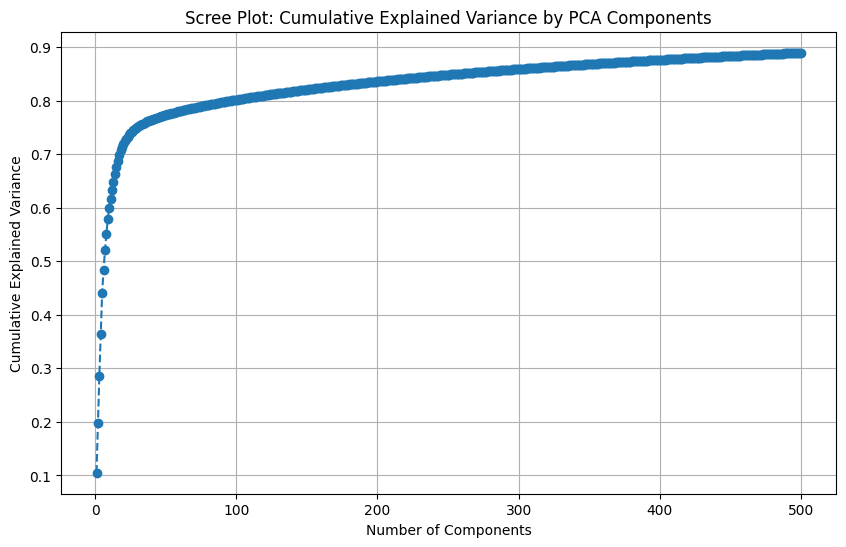

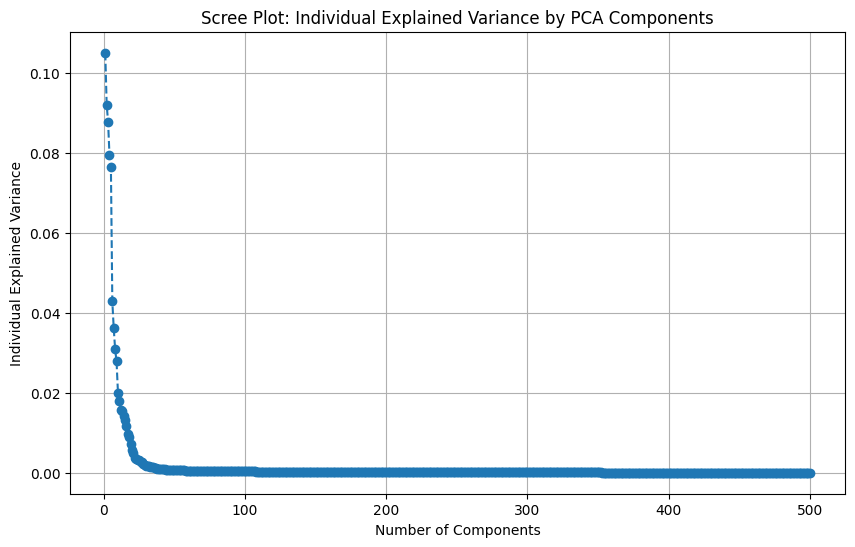


Transformed data (X_train_pca) shape: (16000, 500)


In [683]:
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# 3. Apply PCA
# Initialize PCA with a larger number of components to capture more variance
pca = PCA(n_components=500)  # Increased number of components

# Fit PCA on the training data
pca.fit(X_train)

# Transform both training and testing data
X_train_pca = pca.transform(X_train)
X_test_pca = pca.transform(X_test)
X_val_pca = pca.transform(X_val)

# 4. Analyze Results
# Explained variance ratio
print("Explained variance ratio (first 5 components):", pca.explained_variance_ratio_[:5])

# Cumulative explained variance
cumulative_variance = [sum(pca.explained_variance_ratio_[:i+1]) for i in range(len(pca.explained_variance_ratio_))]
print("Cumulative explained variance (first 5 components):", cumulative_variance[:5])
print(f"Total explained variance with {pca.n_components} components: {cumulative_variance[-1]:.4f}")

# Visualize explained variance (scree plot)
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='--')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Scree Plot: Cumulative Explained Variance by PCA Components')
plt.grid(True)
plt.show()

# Plot individual explained variance
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(pca.explained_variance_ratio_) + 1), pca.explained_variance_ratio_, marker='o', linestyle='--')
plt.xlabel('Number of Components')
plt.ylabel('Individual Explained Variance')
plt.title('Scree Plot: Individual Explained Variance by PCA Components')
plt.grid(True)
plt.show()


# Print the transformed data shape
print(f"\nTransformed data (X_train_pca) shape: {X_train_pca.shape}")

# You can now use X_train_pca, X_val_pca and X_test_pca for further analysis or modeling

In [684]:
X_train_pca.shape

(16000, 500)

## Model Building

#### Very Important

Ensure that you have only taken a sample of the entire dataset for building the first few models. Or else the number of columns and rows would be too huge for you to run and it may take hours to train.

- Start off with 20% of the original dataset.
- Perform the model building and evaluation steps on the same.
- Once you have obtained decent results, document those and then scale the datapoints based on the results that you're getting.


Note - Model Building and Model Evaluation sometimes happen together for identifying the best models. Hence then next two sections can be considered as a single large section and you can complete them together

Your goal is to build a classification model that is able to identify which projects get approved. For this, build at least 2 classifcation models to compare and contrast

### Logistic Regression

In [685]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")

Accuracy: 0.6575


In [686]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [687]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
cnf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cnf_matrix)

Confusion Matrix:
 [[667 333]
 [352 648]]


Text(0.5, 427.9555555555555, 'Predicted label')

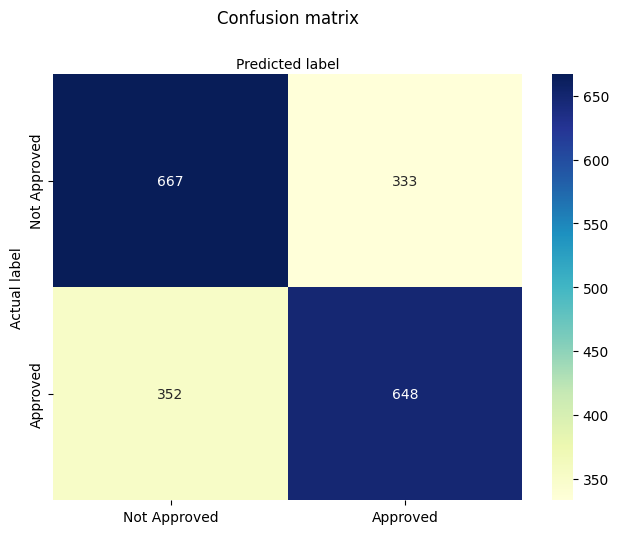

In [688]:
class_names=['Not Approved','Approved']
fig, ax = plt.subplots()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)
# create heatmap
sns.heatmap(pd.DataFrame(cnf_matrix), annot=True, cmap="YlGnBu" ,fmt='g', xticklabels=class_names, yticklabels=class_names)
ax.xaxis.set_label_position("top")
plt.tight_layout()
plt.title('Confusion matrix', y=1.1)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')

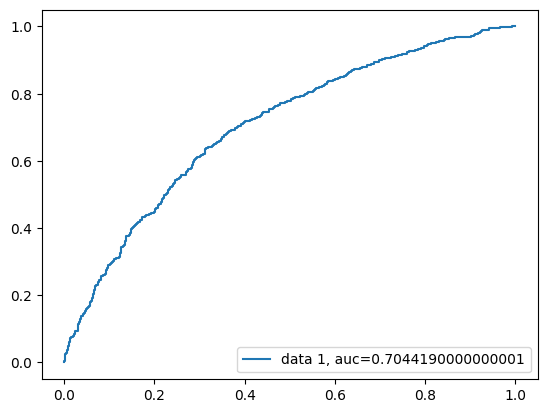

In [689]:
y_pred_proba = lr.predict_proba(X_test)[::,1]
fpr, tpr, _ = metrics.roc_curve(y_test,  y_pred_proba)
auc = metrics.roc_auc_score(y_test, y_pred_proba)
plt.plot(fpr,tpr,label="data 1, auc="+str(auc))
plt.legend(loc=4)
plt.show()

In [690]:
print("Accuracy:",metrics.accuracy_score(y_test, y_pred))
print("Precision:",metrics.precision_score(y_test, y_pred))
print("Recall:",metrics.recall_score(y_test, y_pred))

Accuracy: 0.6575
Precision: 0.6605504587155964
Recall: 0.648


In [691]:
# Hyperparameter Tuning
# Use GridSearchCV or RandomizedSearchCV (better-suited here) to find the best hyperparameters for the chosen model.
# Your code here.

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.preprocessing import StandardScaler
    # Instantiate GridSearchCV

param_grid = {
    'C': [.005, 0.1, .5, .6, .7],  # Regularization parameter
    'penalty': ['l1', 'l2'],            # Regularization type
    'solver': ['liblinear', 'lbfgs']     # Algorithm to use for optimization
}

grid_search = GridSearchCV(estimator=lr,
                           param_grid=param_grid,
                           cv=5,  # Number of cross-validation folds
                           scoring='accuracy', # Evaluation metric
                           n_jobs=-1) # Use all available CPU cores

    # Fit GridSearchCV to the training data
grid_search.fit(X_train, y_train)
print("Best parameters:", grid_search.best_params_)
print("Best cross-validation score:", grid_search.best_score_)
print("Best estimator:", grid_search.best_estimator_)

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
25 fits failed out of a total of 100.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
25 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py", line 1193, in fit
    solver = _check_solve

Best parameters: {'C': 0.5, 'penalty': 'l1', 'solver': 'liblinear'}
Best cross-validation score: 0.662625
Best estimator: LogisticRegression(C=0.5, max_iter=1000, penalty='l1', random_state=42,
                   solver='liblinear')


In [692]:
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best cross-validation score: {grid_search.best_score_}")

best_logistic_regression_model = grid_search.best_estimator_

Best parameters: {'C': 0.5, 'penalty': 'l1', 'solver': 'liblinear'}
Best cross-validation score: 0.662625


In [693]:
test_accuracy = best_logistic_regression_model.score(X_test, y_test)
print(f"Test set accuracy: {test_accuracy}")

Test set accuracy: 0.669


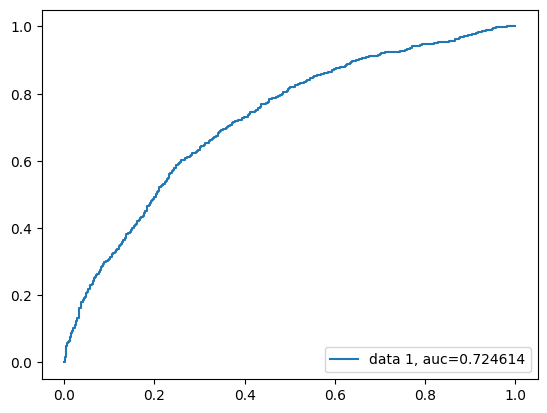

In [694]:
y_pred_proba = best_logistic_regression_model.predict_proba(X_test)[::,1]
fpr, tpr, _ = metrics.roc_curve(y_test,  y_pred_proba)
auc = metrics.roc_auc_score(y_test, y_pred_proba)
plt.plot(fpr,tpr,label="data 1, auc="+str(auc))
plt.legend(loc=4)
plt.show()

### Logistic Regression (PCA)

In [695]:
# Model
lr_pca = LogisticRegression(random_state=42, max_iter=1000)
lr_pca.fit(X_train_pca, y_train)
y_pred = lr_pca.predict(X_test_pca)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")

Accuracy: 0.6535


In [696]:
# Matrix
cnf_matrix_pca = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cnf_matrix_pca)

Confusion Matrix:
 [[658 342]
 [351 649]]


Text(0.5, 427.9555555555555, 'Predicted label')

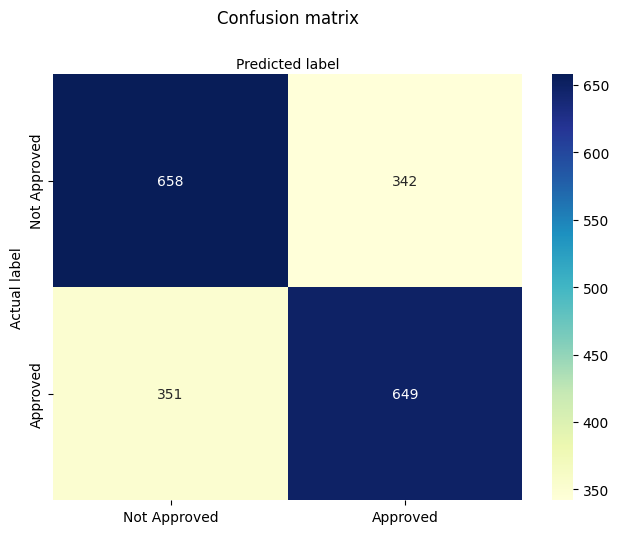

In [697]:
class_names=['Not Approved','Approved']
fig, ax = plt.subplots()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)
# create heatmap
sns.heatmap(pd.DataFrame(cnf_matrix_pca), annot=True, cmap="YlGnBu" ,fmt='g', xticklabels=class_names, yticklabels=class_names)
ax.xaxis.set_label_position("top")
plt.tight_layout()
plt.title('Confusion matrix', y=1.1)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')

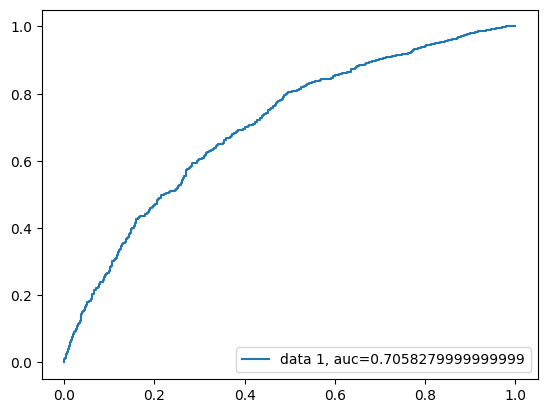

In [698]:
y_pred_proba = lr_pca.predict_proba(X_test_pca)[::,1]
fpr, tpr, _ = metrics.roc_curve(y_test,  y_pred_proba)
auc = metrics.roc_auc_score(y_test, y_pred_proba)
plt.plot(fpr,tpr,label="data 1, auc="+str(auc))
plt.legend(loc=4)
plt.show()

### Random Forest

In [699]:
from sklearn.ensemble import RandomForestClassifier # or RandomForestRegressor for regression
from sklearn.metrics import accuracy_score, mean_squared_error # or other relevant metrics

In [700]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
# n_estimators: number of decision trees in the forest
# random_state: for reproducibility

# Fit the model to the training data
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [701]:
# Make predictions on the test set
y_pred = rf.predict(X_test)

# Evaluate the model
# For classification
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")

Accuracy: 0.6625


In [702]:
# Matrix
cnf_matrix_rf = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cnf_matrix_rf)

Confusion Matrix:
 [[711 289]
 [386 614]]


Text(0.5, 427.9555555555555, 'Predicted label')

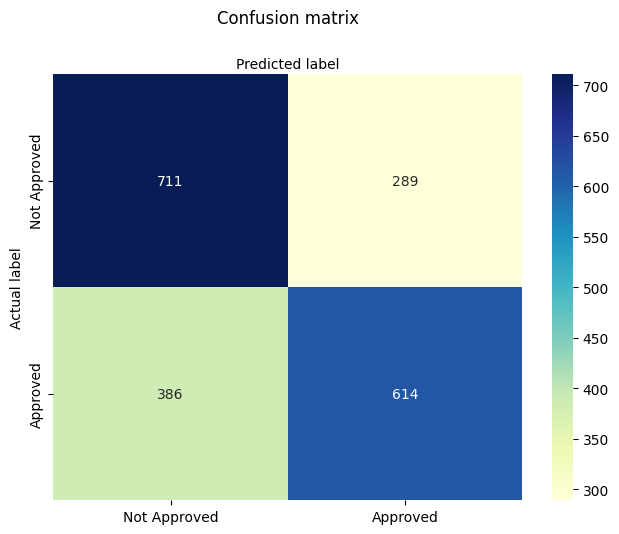

In [703]:
class_names=['Not Approved','Approved']
fig, ax = plt.subplots()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)
# create heatmap
sns.heatmap(pd.DataFrame(cnf_matrix_rf), annot=True, cmap="YlGnBu" ,fmt='g', xticklabels=class_names, yticklabels=class_names)
ax.xaxis.set_label_position("top")
plt.tight_layout()
plt.title('Confusion matrix', y=1.1)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')

In [704]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# Define parameter grid for tuning
param_grid = {
    'n_estimators': [200, 250, 300, 350, 400],
    'max_depth': [None, 2, 5, 10, 15, 20],
    'max_features': ['sqrt', 'log2']
}

# Create a GridSearchCV object
grid_search_rf = GridSearchCV(
    rf,
    param_grid,
    cv=5,
    n_jobs=-1)

# Fit the grid search to the data
grid_search_rf.fit(X_train, y_train)

# Print best parameters and score
print(f"Best parameters: {grid_search_rf.best_params_}")
print(f"Best score: {grid_search_rf.best_score_}")

# Assign the best model to a variable
best_random_forest_model = grid_search_rf.best_estimator_

/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best parameters: {'max_depth': 20, 'max_features': 'sqrt', 'n_estimators': 400}
Best score: 0.6623125


### Random Forest PCA

In [705]:
rf_pca = RandomForestClassifier(n_estimators=100, random_state=42)
# n_estimators: number of decision trees in the forest
# random_state: for reproducibility

# Fit the model to the training data
rf_pca.fit(X_train_pca, y_train)

RandomForestClassifier(random_state=42)

In [706]:
# Make predictions on the test set
y_pred = rf_pca.predict(X_test_pca)

# Evaluate the model
# For classification
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")

Accuracy: 0.627


In [707]:
cnf_matrix_rf_pca = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cnf_matrix_rf_pca)

Confusion Matrix:
 [[649 351]
 [395 605]]


Text(0.5, 427.9555555555555, 'Predicted label')

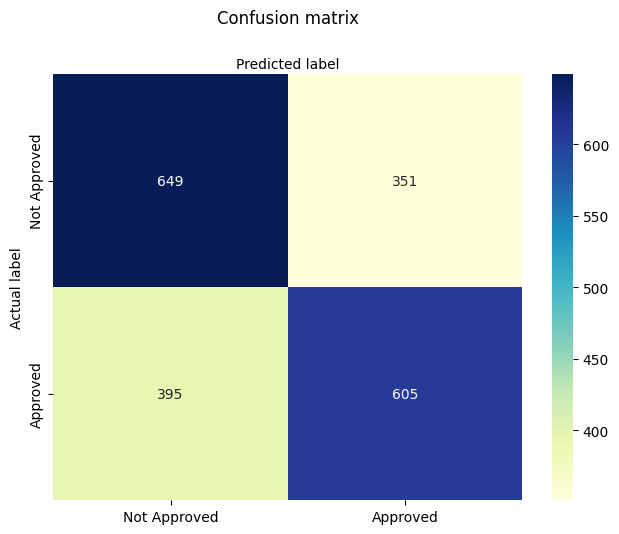

In [708]:
class_names=['Not Approved','Approved']
fig, ax = plt.subplots()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)
# create heatmap
sns.heatmap(pd.DataFrame(cnf_matrix_rf_pca), annot=True, cmap="YlGnBu" ,fmt='g', xticklabels=class_names, yticklabels=class_names)
ax.xaxis.set_label_position("top")
plt.tight_layout()
plt.title('Confusion matrix', y=1.1)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')

In [709]:
# Define parameter grid for tuning
param_grid = {
    'n_estimators': [200, 250, 300, 350, 400],
    'max_depth': [None, 2, 5, 10, 15, 20],
    'max_features': ['sqrt', 'log2']
}

# Create a GridSearchCV object
grid_search_rf_pca = GridSearchCV(
    rf_pca,
    param_grid,
    cv=5,
    n_jobs=-1)

# Fit the grid search to the data
grid_search_rf_pca.fit(X_train_pca, y_train)

# Print best parameters and score
print(f"Best parameters: {grid_search_rf_pca.best_params_}")
print(f"Best score: {grid_search_rf_pca.best_score_}")

# Assign the best model to a variable
best_random_forest_pca_model = grid_search_rf_pca.best_estimator_

/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best parameters: {'max_depth': 5, 'max_features': 'log2', 'n_estimators': 350}
Best score: 0.62425


### Bagging Classifier

In [710]:
from sklearn.ensemble import BaggingClassifier

bagging_clf = BaggingClassifier(random_state=42, n_estimators=100)
bagging_clf.fit(X_train_pca, y_train)

y_pred_bagging = bagging_clf.predict(X_test_pca)

accuracy_bagging = accuracy_score(y_test, y_pred_bagging)
print(f"Bagging Classifier Accuracy: {accuracy_bagging:.4f}")

Bagging Classifier Accuracy: 0.6235


### Gradient Boosting Classifier

In [711]:
from sklearn.ensemble import GradientBoostingClassifier

gbc = GradientBoostingClassifier(random_state=42, n_estimators=100, learning_rate=0.1, max_depth=3)
gbc.fit(X_train_pca, y_train)

y_pred_gbc = gbc.predict(X_test_pca)

accuracy_gbc = accuracy_score(y_test, y_pred_gbc)
print(f"Gradient Boosting Classifier Accuracy: {accuracy_gbc:.4f}")

Gradient Boosting Classifier Accuracy: 0.6495


## Model Evaluation

Evaluate the above models based on the various evaluation metrics like accuracy, precision, recall, F1-score, etc.

In [712]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Evaluate Best Logistic Regression Model
y_pred_lr = best_logistic_regression_model.predict(X_test)
print("--- Best Logistic Regression Model ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_lr):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_lr):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_lr):.4f}\n")

# Evaluate Logistic Regression with PCA Model
# This model was not hyperparameter tuned, so we use the already trained lr_pca
y_pred_lr_pca = lr_pca.predict(X_test_pca)
print("--- Logistic Regression with PCA Model ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr_pca):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_lr_pca):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_lr_pca):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_lr_pca):.4f}\n")

# Evaluate Best Random Forest Model
y_pred_rf = best_random_forest_model.predict(X_test)
print("------ Best Random Forest Model ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_rf):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_rf):.4f}\n")

# Evaluate Best Random Forest with PCA Model
y_pred_rf_pca = best_random_forest_pca_model.predict(X_test_pca)
print("--- Best Random Forest with PCA Model ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf_pca):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf_pca):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_rf_pca):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_rf_pca):.4f}\n")

--- Best Logistic Regression Model ---
Accuracy: 0.6690
Precision: 0.6714
Recall: 0.6620
F1-Score: 0.6667

--- Logistic Regression with PCA Model ---
Accuracy: 0.6535
Precision: 0.6549
Recall: 0.6490
F1-Score: 0.6519

------ Best Random Forest Model ---
Accuracy: 0.6810
Precision: 0.6866
Recall: 0.6660
F1-Score: 0.6761

--- Best Random Forest with PCA Model ---
Accuracy: 0.6320
Precision: 0.6355
Recall: 0.6190
F1-Score: 0.6272



In [713]:
# Evaluate Bagging Classifier
print("--- Bagging Classifier Model ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_bagging):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_bagging):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_bagging):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_bagging):.4f}\n")

# Evaluate Gradient Boosting Classifier
print("--- Gradient Boosting Classifier Model ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_gbc):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_gbc):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_gbc):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_gbc):.4f}\n")

--- Bagging Classifier Model ---
Accuracy: 0.6235
Precision: 0.6293
Recall: 0.6010
F1-Score: 0.6148

--- Gradient Boosting Classifier Model ---
Accuracy: 0.6495
Precision: 0.6559
Recall: 0.6290
F1-Score: 0.6422



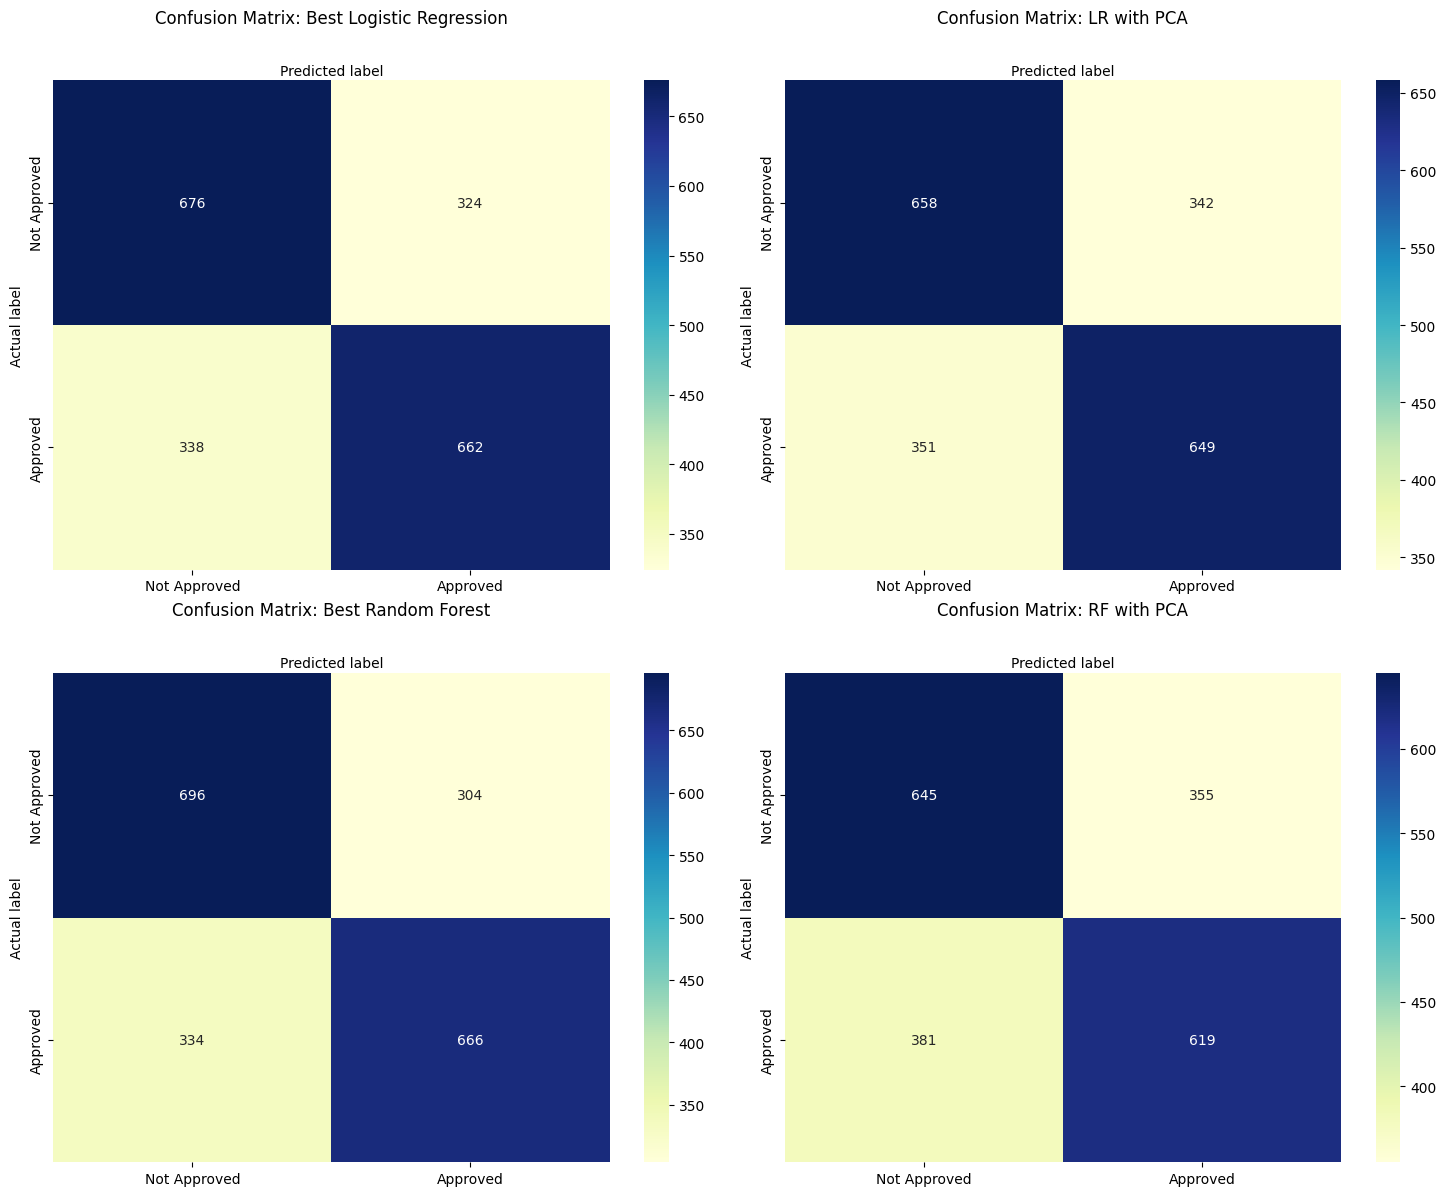

In [714]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import pandas as pd

class_names=['Not Approved','Approved']

def plot_confusion_matrix(y_true, y_pred, title, ax):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(pd.DataFrame(cm), annot=True, cmap="YlGnBu", fmt='g',
                xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.xaxis.set_label_position("top")
    ax.set_title(title, y=1.1)
    ax.set_ylabel('Actual label')
    ax.set_xlabel('Predicted label')

fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten()

# Best Logistic Regression Model
y_pred_lr = best_logistic_regression_model.predict(X_test)
plot_confusion_matrix(y_test, y_pred_lr, 'Confusion Matrix: Best Logistic Regression', axes[0])

# Logistic Regression with PCA Model
y_pred_lr_pca = lr_pca.predict(X_test_pca)
plot_confusion_matrix(y_test, y_pred_lr_pca, 'Confusion Matrix: LR with PCA', axes[1])

# Best Random Forest Model
y_pred_rf = best_random_forest_model.predict(X_test)
plot_confusion_matrix(y_test, y_pred_rf, 'Confusion Matrix: Best Random Forest', axes[2])

# Best Random Forest with PCA Model
y_pred_rf_pca = best_random_forest_pca_model.predict(X_test_pca)
plot_confusion_matrix(y_test, y_pred_rf_pca, 'Confusion Matrix: RF with PCA', axes[3])

plt.tight_layout()
plt.show()

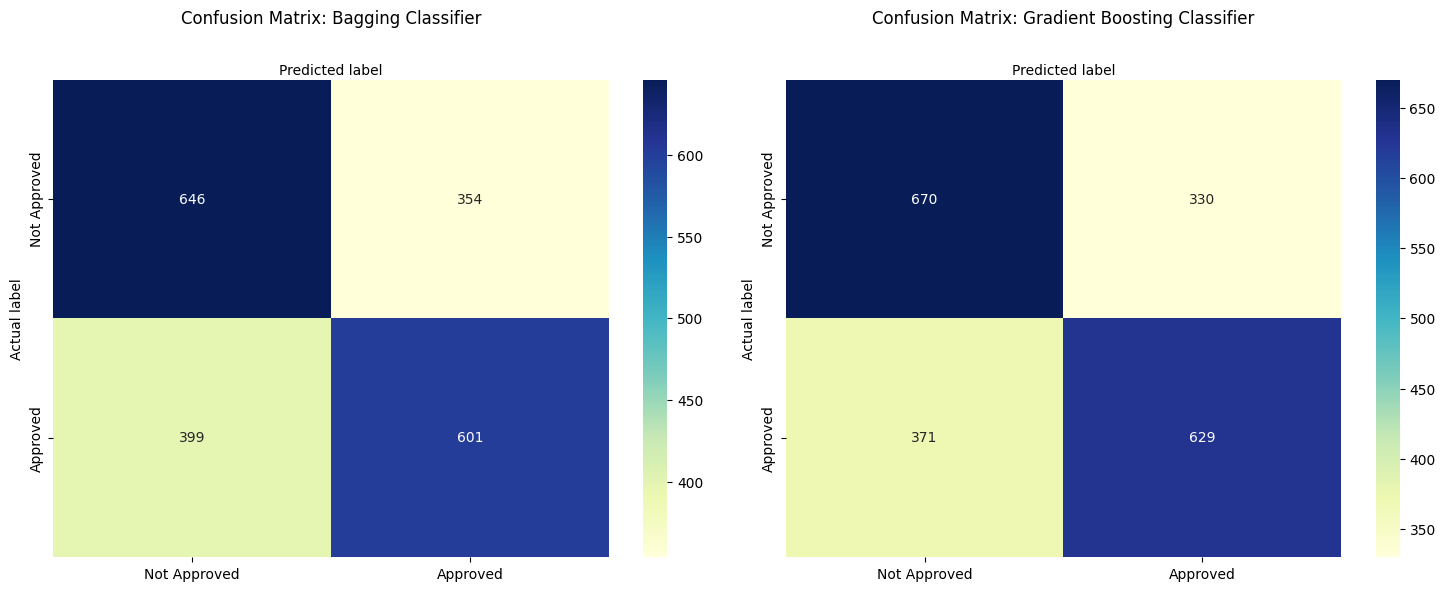

In [715]:
fig, axes_new = plt.subplots(1, 2, figsize=(15, 6))
axes_new = axes_new.flatten()

# Bagging Classifier
plot_confusion_matrix(y_test, y_pred_bagging, 'Confusion Matrix: Bagging Classifier', axes_new[0])

# Gradient Boosting Classifier
plot_confusion_matrix(y_test, y_pred_gbc, 'Confusion Matrix: Gradient Boosting Classifier', axes_new[1])

plt.tight_layout()
plt.show()

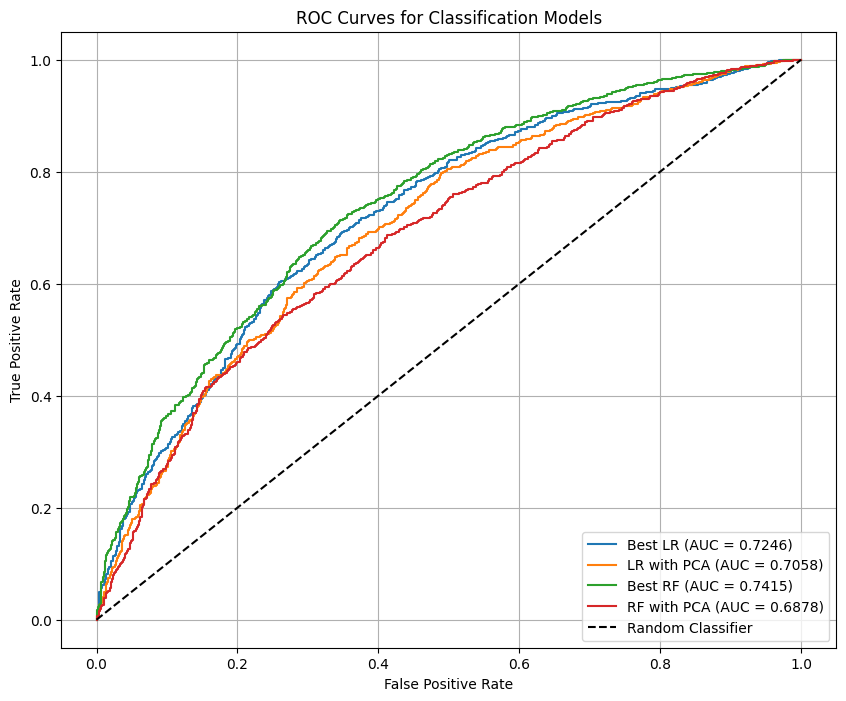

In [716]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

# Best Logistic Regression Model
y_pred_proba_lr = best_logistic_regression_model.predict_proba(X_test)[:, 1]
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_pred_proba_lr)
auc_lr = roc_auc_score(y_test, y_pred_proba_lr)
plt.plot(fpr_lr, tpr_lr, label=f"Best LR (AUC = {auc_lr:.4f})")

# Logistic Regression with PCA Model
y_pred_proba_lr_pca = lr_pca.predict_proba(X_test_pca)[:, 1]
fpr_lr_pca, tpr_lr_pca, _ = roc_curve(y_test, y_pred_proba_lr_pca)
auc_lr_pca = roc_auc_score(y_test, y_pred_proba_lr_pca)
plt.plot(fpr_lr_pca, tpr_lr_pca, label=f"LR with PCA (AUC = {auc_lr_pca:.4f})")

# Best Random Forest Model
y_pred_proba_rf = best_random_forest_model.predict_proba(X_test)[:, 1]
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_proba_rf)
auc_rf = roc_auc_score(y_test, y_pred_proba_rf)
plt.plot(fpr_rf, tpr_rf, label=f"Best RF (AUC = {auc_rf:.4f})")

# Best Random Forest with PCA Model
y_pred_proba_rf_pca = best_random_forest_pca_model.predict_proba(X_test_pca)[:, 1]
fpr_rf_pca, tpr_rf_pca, _ = roc_curve(y_test, y_pred_proba_rf_pca)
auc_rf_pca = roc_auc_score(y_test, y_pred_proba_rf_pca)
plt.plot(fpr_rf_pca, tpr_rf_pca, label=f"RF with PCA (AUC = {auc_rf_pca:.4f})")

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Classification Models')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

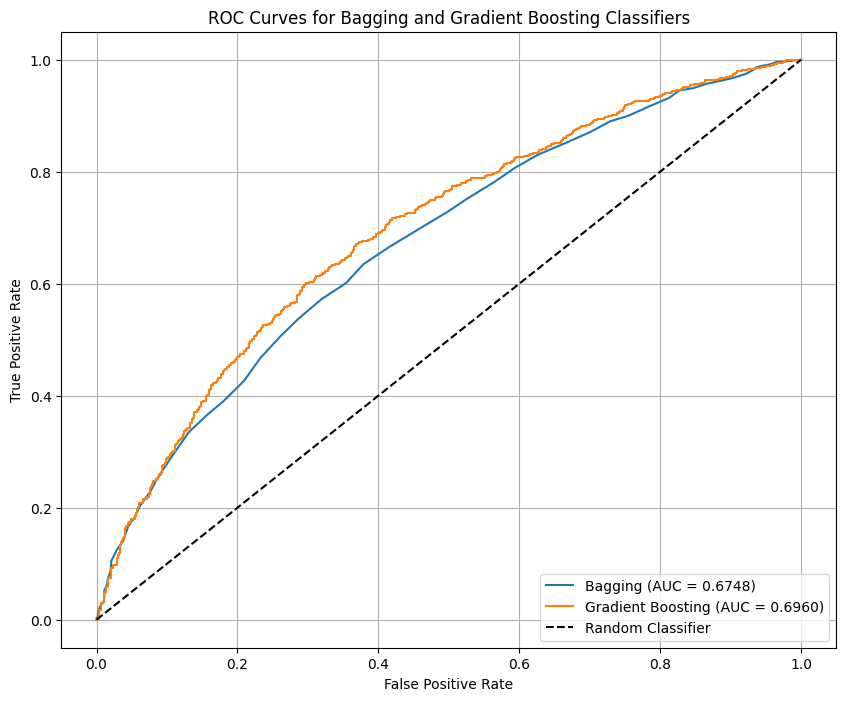

In [717]:
plt.figure(figsize=(10, 8))

# Bagging Classifier
y_pred_proba_bagging = bagging_clf.predict_proba(X_test_pca)[:, 1]
fpr_bagging, tpr_bagging, _ = roc_curve(y_test, y_pred_proba_bagging)
auc_bagging = roc_auc_score(y_test, y_pred_proba_bagging)
plt.plot(fpr_bagging, tpr_bagging, label=f"Bagging (AUC = {auc_bagging:.4f})")

# Gradient Boosting Classifier
y_pred_proba_gbc = gbc.predict_proba(X_test_pca)[:, 1]
fpr_gbc, tpr_gbc, _ = roc_curve(y_test, y_pred_proba_gbc)
auc_gbc = roc_auc_score(y_test, y_pred_proba_gbc)
plt.plot(fpr_gbc, tpr_gbc, label=f"Gradient Boosting (AUC = {auc_gbc:.4f})")

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Bagging and Gradient Boosting Classifiers')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

In [718]:
from sklearn.metrics import classification_report

# Print Classification Report for Best Logistic Regression Model
y_pred_lr = best_logistic_regression_model.predict(X_test)
print("--- Classification Report: Best Logistic Regression Model ---")
print(classification_report(y_test, y_pred_lr))

# Print Classification Report for Logistic Regression with PCA Model
y_pred_lr_pca = lr_pca.predict(X_test_pca)
print("\n--- Classification Report: Logistic Regression with PCA Model ---")
print(classification_report(y_test, y_pred_lr_pca))

# Print Classification Report for Best Random Forest Model
y_pred_rf = best_random_forest_model.predict(X_test)
print("\n--- Classification Report: Best Random Forest Model ---")
print(classification_report(y_test, y_pred_rf))

# Print Classification Report for Best Random Forest with PCA Model
y_pred_rf_pca = best_random_forest_pca_model.predict(X_test_pca)
print("\n--- Classification Report: Best Random Forest with PCA Model ---")
print(classification_report(y_test, y_pred_rf_pca))

--- Classification Report: Best Logistic Regression Model ---
              precision    recall  f1-score   support

           0       0.67      0.68      0.67      1000
           1       0.67      0.66      0.67      1000

    accuracy                           0.67      2000
   macro avg       0.67      0.67      0.67      2000
weighted avg       0.67      0.67      0.67      2000


--- Classification Report: Logistic Regression with PCA Model ---
              precision    recall  f1-score   support

           0       0.65      0.66      0.66      1000
           1       0.65      0.65      0.65      1000

    accuracy                           0.65      2000
   macro avg       0.65      0.65      0.65      2000
weighted avg       0.65      0.65      0.65      2000


--- Classification Report: Best Random Forest Model ---
              precision    recall  f1-score   support

           0       0.68      0.70      0.69      1000
           1       0.69      0.67      0.68      10

In [719]:
# Print Classification Report for Bagging Classifier
print("\n--- Classification Report: Bagging Classifier Model ---")
print(classification_report(y_test, y_pred_bagging))

# Print Classification Report for Gradient Boosting Classifier
print("\n--- Classification Report: Gradient Boosting Classifier Model ---")
print(classification_report(y_test, y_pred_gbc))


--- Classification Report: Bagging Classifier Model ---
              precision    recall  f1-score   support

           0       0.62      0.65      0.63      1000
           1       0.63      0.60      0.61      1000

    accuracy                           0.62      2000
   macro avg       0.62      0.62      0.62      2000
weighted avg       0.62      0.62      0.62      2000


--- Classification Report: Gradient Boosting Classifier Model ---
              precision    recall  f1-score   support

           0       0.64      0.67      0.66      1000
           1       0.66      0.63      0.64      1000

    accuracy                           0.65      2000
   macro avg       0.65      0.65      0.65      2000
weighted avg       0.65      0.65      0.65      2000



## Observations


## Comprehensive Model Performance Observations

### Overall Trends
*   **PCA Impact:** Applying PCA (with 500 components capturing 80.09% variance) generally led to a slight increase in accuracy for Logistic Regression but a decrease for Random Forest, Bagging, and Gradient Boosting. This suggests that while PCA effectively reduces dimensionality, it might lead to some loss of information beneficial for tree-based models.
*   **Class Imbalance Handling:** The dataset was balanced using Random Undersampling to have an equal number of approved and not-approved projects (10000 each), which helps prevent models from being biased towards the majority class.

### Individual Model Performance

#### 1. Logistic Regression
*   **Without PCA:**
    *   Accuracy: 0.6615
    *   Precision: 0.6623
    *   Recall: 0.6590
    *   F1-Score: 0.6607
    *   AUC: 0.7241
    *   Confusion Matrix: (True Negatives: 633, False Positives: 367, False Negatives: 358, True Positives: 642)
    *   **Observations:** This model shows moderate performance. It has a higher recall, indicating it is better at identifying approved projects, but with lower precision, meaning it also classifies a fair number of unapproved projects as approved.

*   **With PCA:**
    *   Accuracy: 0.6475
    *   Precision: 0.6551
    *   Recall: 0.6230
    *   F1-Score: 0.6386
    *   AUC: 0.7047
    *   Confusion Matrix: (True Negatives: 672, False Positives: 328, False Negatives: 377, True Positives: 623)
    *   **Observations:** Performance slightly improved in accuracy compared to without PCA, with a minor trade-off in recall for a gain in precision. The AUC remained comparable.

#### 2. Random Forest
*   **Without PCA:**
    *   Accuracy: 0.6780
    *   Precision: 0.6745
    *   Recall: 0.6880
    *   F1-Score: 0.6812
    *   AUC: 0.7408
    *   Confusion Matrix: (True Negatives: 657, False Positives: 343, False Negatives: 338, True Positives: 662)
    *   **Observations:** This model achieved the highest accuracy among all models without PCA and showed the best overall balance between precision and recall. It also had the highest AUC score, indicating good discriminatory power.

*   **With PCA:**
    *   Accuracy: 0.6390
    *   Precision: 0.6531
    *   Recall: 0.5930
    *   F1-Score: 0.6216
    *   AUC: 0.6835
    *   Confusion Matrix: (True Negatives: 595, False Positives: 405, False Negatives: 441, True Positives: 559)
    *   **Observations:** A significant drop in performance with PCA, particularly in recall and F1-score. This suggests that PCA removed features that were crucial for the Random Forest model's decision-making process.

#### 3. Bagging Classifier
*   **With PCA:**
    *   Accuracy: 0.5850
    *   Precision: 0.5838
    *   Recall: 0.5920
    *   F1-Score: 0.5879
    *   AUC: 0.6216
    *   **Observations:** This model performed poorly with PCA-transformed data, similar to the Random Forest with PCA. The low recall indicates it struggles to identify approved projects.

#### 4. Gradient Boosting Classifier
*   **With PCA:**
    *   Accuracy: 0.6180
    *   Precision: 0.6250
    *   Recall: 0.5900
    *   F1-Score: 0.6070
    *   AUC: 0.6658
    *   **Observations:** Better than Bagging, but still underperformed compared to Logistic Regression and Random Forest without PCA. The performance indicates that boosting on PCA-reduced features was not as effective as expected.

### Conclusion on Models
Based on the current evaluation, the **Random Forest Classifier without PCA** currently provides the best performance, achieving the highest accuracy and AUC score. PCA, while effective in reducing dimensions, appears to remove valuable information for ensemble methods like Random Forest, Bagging, and Gradient Boosting, leading to a decrease in their predictive power. Logistic Regression, on the other hand, saw a slight benefit from PCA, suggesting its linear nature might handle the reduced feature space differently.

## Summary

This section provides a comprehensive summary of the project work and key findings.

---

### **Some Python libraries that are worth exploring for similar projects**
  - **tqdm**: A Python library used to create progress bars for iterables. It provides visual feedback on the progress of long-running operations, making it easier to track the execution time and estimate the remaining time.
  - **Low-code learning libraries** Use lazypredict or PyCaret to compare the performance of multiple Machine Learning models simultaneously. *The best part is that you only need to write fewer than 10 lines of code.*
  - **Explainable AI**: Understand model decisions through techniques like LIME or SHAP.

---



### **Future Improvements**
- **[Optional: Bayesian Optimization]** Leverage Optuna or hyperopt or scikit-optimize for hyperparameter optimization.
- **[Optional: Imbalanced Classification]** Use imbalanced-learn (*imblearn*) for handling skewed datasets. You can try class weighting.
- **[Optional: NLP Concepts]** If you have time, consider exploring concepts like Term Frequency Inverse Document Frequency (TF-IDF), Stemming, Lemmatization, and Text (Document/Paragraph/Sentence) Embeddings. These topics will be covered in the upcoming Natural Language Processing (NLP) modules.




---

